### 1. Environment setup

In [ ]:
#1
import numpy as np
import pandas as pd
import plotly.graph_objects as go

import matplotlib.pyplot as plt

import sys
from pathlib import Path

repo_dir = Path.cwd().parents[1]

if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

In [ ]:
#3

from pv_chip_aarhus.analysis.data_io import DataIO
from pv_chip_aarhus.analysis.analysis_params import dataset_dir

# Create temporary DataIO object
catalog = DataIO(dataset_dir)

print("Sessions in datadir:")

for sid in catalog.sessions:
    print(f"    {sid}")

### 2. Load data (Change session IDs here)

In [ ]:
import inspect

print(inspect.getfile(DataIO))

In [ ]:
import inspect
from pv_chip_aarhus.preprocessing import dataset_sessions as ds

print(inspect.getfile(ds))
print(ds.dataset_sessions.keys())

In [ ]:
# #5

# # ==========================================
# # Sessions to load
# # ==========================================

# session_ids = [

#     "20260601_eye1_1st",

# ]

# all_data_io = {}

# # ==========================================
# # Load sessions
# # ==========================================

# for session_id in session_ids:

#     session_data = DataIO(dataset_dir)

#     session_data.load_session(session_id)

#     all_data_io[session_id] = session_data

#     print(f"\nLoaded session: {session_id}")

#     print(f"Recordings : {len(session_data.recording_df)}")
#     print(f"Clusters   : {len(session_data.cluster_df)}")
#     print(f"Trials     : {len(session_data.trial_df)}")
#     print(f"Bursts     : {len(session_data.burst_df)}")

### 3. Access tables with metadata
All tables are pandas dataframes. These are the attributes I used all the time:

`df.index.values`: the index for each row, this can be used to quickly access a row

`df.loc[INDEX]`: this is how to index into a row

`df.columns`: list available columns

`df.loc[INDEX, COLUMN]` : gives value of a single cell

`df.query("COLUMN == VALUE")` : filters the dataframe based on column values

`df.iterrows()`  : allow you to loop over  each row of the table

In [ ]:
# #6

# # ==========================================
# # Dataset overview
# # ==========================================

# for session_id, session_data in all_data_io.items():

#     print(f"\n{'=' * 60}")
#     print(session_id)
#     print(f"{'=' * 60}")

#     print(f"Recordings : {len(session_data.recording_df)}")
#     print(f"Clusters   : {len(session_data.cluster_df)}")
#     print(f"Trials     : {len(session_data.trial_df)}")
#     print(f"Bursts     : {len(session_data.burst_df)}")

#     print("\nAvailable recordings:")

#     for rec_id in sorted(session_data.spiketimes.keys()):
#         print(f"    {rec_id}")

In [ ]:
# #8

# # ==========================================
# # Data sanity check
# # ==========================================

# for session_id, session_data in all_data_io.items():

#     print(f"\nSession: {session_id}")

#     print(
#         f"Spike recordings : "
#         f"{len(session_data.spiketimes)}"
#     )

#     print(
#         f"Clusters         : "
#         f"{len(session_data.cluster_df)}"
#     )

#     print(
#         f"Bursts           : "
#         f"{len(session_data.burst_df)}"
#     )

### 4. Select recording, unit and other analysis parameters

In [ ]:
#15
# Experimental recording
#
# Naming convention:
#
# XX_MODE_SOURCE_PROTOCOL
#
# Examples:
#
# 02_N_P_pow
#     Irradiance series
#     Normal pulsed stimulation
#     Polychrome only
#
# 07_N_L_dur
#     Duration series
#     Normal pulsed stimulation
#     Laser only
#
# 15_N_P_longstim
#     Long stimulation protocol
#
# ==========================================
# Analysis parameters
# ==========================================

selected_session = "20260601_eye1_1st"

# Experiment to analyse
protocol = "dur"          # pow, dur, freq, del, del2, longstim
stim_mode = "L"           # P, L or B
laser_mode = "N"          # N or LC

# Optional manual override
manual_rec_id = None      # e.g. "05_N_P_dur"

# Cluster
unit_id = "uid_20260601_012"

# Analysis window (ms)
t_pre = 1000
t_post = 7000

analysis_window = (-t_pre, t_post)

### 4. Selection of parameters (Helping part)

In [ ]:
# #16
# # ==========================================
# # Select recording
# # ==========================================
# session_data = all_data_io[selected_session]

# if manual_rec_id is not None:

#     rec_id = manual_rec_id

# else:

#     candidates = sorted(
#         rec
#         for rec in session_data.spiketimes.keys()
#         if (
#             rec.endswith(protocol)
#             and f"_{stim_mode}_" in rec
#             and rec.split("_")[1] == laser_mode
#         )
#     )

#     if len(candidates) == 0:
#         raise ValueError("No matching recording found.")

#     # Always use the newest repeat
#     rec_id = candidates[-1]

# print(f"Selected recording: {rec_id}")

In [ ]:
# #17
# print("Current analysis")
# print("----------------")
# print(f"Selected session    : {selected_session}")
# print(f"Recording           : {rec_id}")
# print(f"Unit                : {unit_id}")
# print(f"Protocol            : {protocol}")
# print(f"Stim. mode          : {stim_mode}")
# print(f"Laser mode          : {laser_mode}")
# print(f"Window              : {-t_pre} to +{t_post} ms")

In [ ]:
# #18
# assert rec_id in session_data.spiketimes, (
#     f"{rec_id} not found.\n"
#     f"Available recordings:\n"
#     f"{list(session_data.spiketimes.keys())}"
# )

# assert unit_id in session_data.spiketimes[rec_id], (
#     f"{unit_id} not found in {rec_id}"
# )

In [ ]:
#19
# ==========================================
# Stimulation metadata definitions
# ==========================================

"""
Metadata column definitions for the two stimulation sources.

These dictionaries are used throughout the notebook when
constructing analysis views.
"""

pchr_columns = {

    "onset": "pchr_onset",
    "duration": "pchr_on_duration",
    "off_duration": "pchr_off_duration",
    "delay": "pchr_delay",
    "power": "pchr_power",
    "frequency": "pchr_frequency",

}

laser_columns = {

    "onset": "laser_onset",
    "duration": "laser_on_duration",
    "off_duration": "laser_off_duration",
    "delay": "laser_delay",
    "power": "laser_power",
    "frequency": "laser_frequency",

}

### 5. Determine analysis views <- Helper cell

#### 19.5

In [ ]:
#19.5
# HELPER FUNCTION
# ==========================================
# Prepare recording-specific analysis state
# ==========================================

def prepare_recording_analysis(
    data_io,
    rec_id,
    protocol,
    stim_mode,
    pchr_columns,
    laser_columns,
):
    # ==========================================
    # Determine recording-specific parameters
    # ==========================================

    """
    Prepare one or more analysis views for the selected recording.

    Each analysis view contains all metadata required by the
    downstream analysis.

    Ordinary recordings contain one analysis view.

    Combined LC_B recordings contain two independent analysis
    views:

        Polychrome
        Laser

    Downstream code should always obtain metadata from the
    selected analysis view rather than relying on recording-level
    variables.
    """

    # ------------------------------------------
    # Determine grouping label
    # ------------------------------------------

    if protocol == "pow":

        group_label = "Irradiance"

    elif protocol == "dur":

        group_label = "Pulse duration (ms)"

    elif protocol == "freq":

        group_label = "Pulse frequency (Hz)"

    elif protocol == "longstim":

        group_label = "Stimulation duration (ms)"

    elif protocol in ["del", "del2"]:

        group_label = "Delay condition"

    else:

        raise ValueError(
            f"Unknown protocol: {protocol}"
        )

    # ------------------------------------------
    # Select bursts belonging to the recording
    # ------------------------------------------

    burst_df = (
        data_io.burst_df
        .query("rec_id == @rec_id")
        .copy()
    )

    assert not burst_df.empty, (
        f"No bursts found for recording {rec_id}"
    )

    # ------------------------------------------
    # Helper functions
    # ------------------------------------------

    def build_stim_windows(burst_info, stim_source):
        """
        Determine the alignment onset and stimulation windows.

        Returns
        -------
        alignment_onset : float
            Absolute recording time used to align spikes.

        windows : list
            List of (x0, x1, label) tuples relative to the
            alignment onset.
        """

        if protocol in ["del", "del2"]:

            # Delay metadata indicate which stimulus is delayed:
            #
            # pchr_delay  > 0 : Polychrome starts after Laser
            # laser_delay > 0 : Laser starts after Polychrome
            #
            # Only one onset is stored in the metadata. The other onset is
            # reconstructed here.
            p_on = burst_info["pchr_onset"]
            l_on = burst_info["laser_onset"]

            # Delay metadata indicate which stimulus is delayed.
            # Only one onset is stored; reconstruct the other.

            if np.isnan(l_on):

                if burst_info["pchr_delay"] > 0:
                    # Polychrome is delayed relative to the laser
                    l_on = (
                        p_on
                        - burst_info["pchr_delay"]
                    )

                else:
                    # Laser is delayed relative to the polychrome
                    l_on = (
                        p_on
                        + burst_info["laser_delay"]
                    )

            elif np.isnan(p_on):

                if burst_info["laser_delay"] > 0:
                    p_on = (
                        l_on
                        - burst_info["laser_delay"]
                    )

                else:
                    p_on = (
                        l_on
                        + burst_info["pchr_delay"]
                    )

            alignment = min(p_on, l_on)

            p_on -= alignment
            l_on -= alignment
                    

        else:

            if stim_source == "P":

                alignment = burst_info["pchr_onset"]

                p_on = 0
                l_on = None

            elif stim_source == "L":

                alignment = burst_info["laser_onset"]

                p_on = None
                l_on = 0

            else:

                raise ValueError(
                    f"Unknown stimulation source: {stim_source}"
                )

        windows = []

        if p_on is not None:
            windows.append(
                (
                    p_on,
                    p_on + burst_info["pchr_on_duration"],
                    "Polychrome",
                )
            )

        if l_on is not None:
            windows.append(
                (
                    l_on,
                    l_on + burst_info["laser_on_duration"],
                    "Laser",
                )
            )

        return alignment, windows


    def make_view(name, stim_source, columns):
        """Create one analysis view."""

        if protocol == "pow":
            group_column = columns["power"]

        elif protocol == "dur":
            group_column = columns["duration"]

        elif protocol == "freq":
            group_column = columns["frequency"]

        elif protocol == "longstim":
            group_column = columns["duration"]

        elif protocol in ["del", "del2"]:
            group_column = columns["delay"]

        else:
            raise ValueError(protocol)

        return {

            "name": name,

            "stim_source": stim_source,

            "group_column": group_column,
            "group_label": group_label,

            "onset_column": columns["onset"],

            "on_duration_column": columns["duration"],
            "off_duration_column": columns["off_duration"],

            "power_column": columns["power"],
            "frequency_column": columns["frequency"],

            # New
            "stim_windows": (
                lambda burst_info:
                    build_stim_windows(
                        burst_info,
                        stim_source,
                    )
            ),

        }

    # ------------------------------------------
    # Build analysis views
    # ------------------------------------------

    analysis_views = []

    if stim_mode == "P":

        analysis_views.append(
            make_view(
                "Polychrome",
                "P",
                pchr_columns,
            )
        )

    elif stim_mode == "L":

        analysis_views.append(
            make_view(
                "Laser",
                "L",
                laser_columns,
            )
        )

    elif stim_mode == "B":

        analysis_views.append(
            make_view(
                "Polychrome",
                "P",
                pchr_columns,
            )
        )

        analysis_views.append(
            make_view(
                "Laser",
                "L",
                laser_columns,
            )
        )

    else:

        raise ValueError(
            f"Unknown stimulation mode: {stim_mode}"
        )
    
    return (
        burst_df,
        analysis_views,
        group_label,
    )

#### 20

In [ ]:
# #20

# burst_df, analysis_views, group_label = prepare_recording_analysis(

#     data_io=data_io,

#     rec_id=rec_id,

#     protocol=protocol,

#     stim_mode=stim_mode,

#     pchr_columns=pchr_columns,

#     laser_columns=laser_columns,

# )

# # ------------------------------------------
# # Backwards compatibility
# # ------------------------------------------

# current_view = analysis_views[0]

# group_column = current_view["group_column"]
# group_label = current_view["group_label"]

# onset_column = current_view["onset_column"]

# on_duration_column = current_view["on_duration_column"]
# off_duration_column = current_view["off_duration_column"]

# power_column = current_view["power_column"]
# frequency_column = current_view["frequency_column"]

# # ------------------------------------------
# # Summary
# # ------------------------------------------

# print("Analysis views")
# print("--------------")

# for view in analysis_views:

#     print(
#         f"{view['name']:<12}"
#         f" source={view['stim_source']}"
#         f" group={view['group_column']}"
#         f" onset={view['onset_column']}"
#     )

### 6. Extract stimulus-aligned spike trains

#### Function #21

In [ ]:
#21
# ==========================================
# Extract stimulus-aligned spike trains
# ==========================================

"""
Goal
----
Convert one continuous spike train from a single unit
into many stimulus-aligned spike trains.

The original spike train contains the firing activity
throughout the entire recording.

For each stimulation burst, spikes are extracted within
a time window around stimulus onset and shifted so that

    0 ms = stimulus onset

The output is a dictionary:

all_spiketimes[train_id] = [
    burst_1_spikes,
    burst_2_spikes,
    ...
]

Each burst therefore contains spike times relative to
stimulus onset and is ready for raster plotting or
statistical analysis.
"""

def extract_spikes(
    session_data,
    rec_id,
    unit_id,
    verbose=True,
):
    """
    Extract stimulus-aligned spike trains
    for one unit.

    Parameters
    ----------
    session_data : object
        Session data object containing spike times.

    rec_id : str
        Recording identifier.

    unit_id : str
        Unit identifier.

    verbose : bool, default=True
        Print extraction progress and summary.

    Returns
    -------
    dict
        all_spiketimes
    """

    assert rec_id in session_data.spiketimes, (
        f"{rec_id} not found in spiketimes."
    )

    assert unit_id in session_data.spiketimes[rec_id], (
        f"{unit_id} not found in recording {rec_id}."
    )

    # ------------------------------------------
    # Extract stimulus-aligned spike trains
    # ------------------------------------------

    # Dictionary of extracted spike trains.
    #
    # Structure
    # ---------
    # all_spiketimes[view_name][train_id]
    #
    # Example
    # -------
    # all_spiketimes["Polychrome"]["tid_001"]
    #
    all_spiketimes = {}

    # ------------------------------------------
    # Loop over analysis views
    # ------------------------------------------

    for view in analysis_views:

        if verbose:
            print(f"\nExtracting {view['name']} responses")

        # Helper describing the stimulation timing
        stim_windows = view["stim_windows"]

        # Load the complete spike train for the selected unit
        spiketrain = session_data.spiketimes[rec_id][unit_id]

        view_spiketimes = {}

        # Loop over each stimulation condition
        for train_id, train_df in burst_df.groupby("train_id"):

            spiketimes_trial = []

            # Loop over every stimulation burst
            for _, burst_info in train_df.iterrows():

                # ----------------------------------
                # Determine alignment onset
                # ----------------------------------

                alignment_onset, _ = stim_windows(
                    burst_info
                )
                idx = np.where(
                    (spiketrain >= alignment_onset - t_pre)
                    & (spiketrain <= alignment_onset + t_post)
                )[0]

                spiketimes_burst = (
                    spiketrain[idx] - alignment_onset
                )

                spiketimes_trial.append(
                    spiketimes_burst
                )

            view_spiketimes[train_id] = spiketimes_trial

        all_spiketimes[view["name"]] = view_spiketimes

    # ------------------------------------------
    # Summary
    # ------------------------------------------

    if verbose:

        print("\nExtraction complete")
        print("-------------------")
        print(f"Recording : {rec_id}")
        print(f"Unit      : {unit_id}")

        for view_name, view_data in all_spiketimes.items():

            print(f"\n{view_name}")

            for train_id, spikes in view_data.items():

                print(
                    f"  {train_id}: "
                    f"{len(spikes)} repetitions"
                )
            
    return all_spiketimes

### 7. Raster plot: Single units

In [ ]:
# #25
# import plotly.graph_objects as go

# fig = go.Figure()

# # ------------------------------------------
# # Stimulation legend
# # ------------------------------------------

# fig.add_scatter(
#     x=[None], y=[None],
#     mode="markers",
#     marker=dict(size=12, color="royalblue"),
#     name="Polychrome",
# )

# fig.add_scatter(
#     x=[None], y=[None],
#     mode="markers",
#     marker=dict(size=12, color="crimson"),
#     name="Laser",
# )

# fig.add_scatter(
#     x=[None], y=[None],
#     mode="markers",
#     marker=dict(size=12, color="mediumpurple"),
#     name="Both",
# )

# # ------------------------------------------
# # Select analysis view
# # ------------------------------------------

# """
# Select which stimulation view to display.

# For ordinary recordings there is only one available view.
# For combined (LC_B) recordings this can be either
# 'Polychrome' or 'Laser'.
# """

# # For now, display the first available view.
# # Later this can become:
# #
# #     for view in analysis_views:
# #
# view = analysis_views[0]

# view_name = view["name"]
# view_spiketimes = all_spiketimes[view_name]
# stim_windows = view["stim_windows"]

# # Metadata for this analysis view
# group_column = view["group_column"]
# group_label = view["group_label"]

# on_duration_column = view["on_duration_column"]
# off_duration_column = view["off_duration_column"]

# print(f"Displaying {view_name}")
# print(f"Grouping by : {group_column}")

# # ------------------------------------------
# # Vertical offsets
# # ------------------------------------------

# burst_offset = 0

# # Spike coordinates
# x_plot = []
# y_plot = []

# # Tick labels
# yticks = []
# ytext = []

# # ------------------------------------------
# # Trial metadata
# # ------------------------------------------

# trial_df = (
#     session_data.trial_df
#     .query("train_id in @view_spiketimes.keys()")
# )

# # ------------------------------------------
# # Order stimulation conditions
# # ------------------------------------------

# sorted_train_ids = (
#     trial_df
#     .sort_values(group_column)
#     .drop_duplicates("train_id")
#     ["train_id"]
#     .tolist()
# )

# # ------------------------------------------
# # Determine x-axis limits
# # ------------------------------------------

# cycle_durations = (
#     trial_df[on_duration_column]
#     + trial_df[off_duration_column]
# )

# min_cycle_duration = cycle_durations.min()
# max_cycle_duration = cycle_durations.max()

# x_axis_start = -min(
#     t_pre,
#     min_cycle_duration,
# )

# x_axis_end = min(
#     t_post,
#     max_cycle_duration,
# )

# # ------------------------------------------
# # Draw raster
# # ------------------------------------------

# for train_id in sorted_train_ids:

#     spiketrains = view_spiketimes[train_id]

#     df = trial_df.query(
#         "train_id == @train_id"
#     )

#     group_value = df.iloc[0][group_column]

#     row = burst_df.query(
#         "train_id == @train_id"
#     ).iloc[0]

#     off_duration = df.iloc[0][off_duration_column]

#     # End of the final stimulus in this burst
#     _, windows = stim_windows(row)
#     stimulus_duration = max(
#         x1 - x0
#         for x0, x1, _ in windows
#     )

#     stimulus_end = max(
#         x1 for _, x1, _ in windows
#     )

#     # Display one complete stimulation cycle,
#     # but never beyond the analysis window.
#     display_end = min(
#         analysis_window[1],
#         stimulus_end + off_duration,
#     )

#     print(
#         f"{train_id}: "
#         f"{group_column} = {group_value}"
#     )

#     group_start = burst_offset

#     for sp in spiketrains:

#         # Only display spikes within one stimulation cycle
#         sp = sp[
#             (sp >= analysis_window[0]) &
#             (sp <= display_end)
#         ]

#         x_plot.append(
#             np.vstack([
#                 sp,
#                 sp,
#                 np.full(sp.size, np.nan)
#             ]).T.flatten()
#         )

#         y_plot.append(
#             np.vstack([
#                 np.ones(sp.size) * burst_offset,
#                 np.ones(sp.size) * (burst_offset + 1),
#                 np.full(sp.size, np.nan)
#             ]).T.flatten()
#         )

#         burst_offset += 1

#     group_end = burst_offset
   
#     # --------------------------------------
#     # Stimulation windows
#     # --------------------------------------

#     yticks.append(
#         (group_start + group_end) / 2
#     )

#     ytext.append(group_value)

#     _, windows = stim_windows(row)

#     colour_map = {
#         "Polychrome": "royalblue",
#         "Laser": "crimson",
#     }

#     segments = [
#         (x0, x1, colour_map[label])
#         for x0, x1, label in windows
#     ]

#     # Draw overlap in purple

#     if len(segments) == 2:

#         polychrome = next(
#             s for s in segments
#             if s[2] == "royalblue"
#         )

#         laser = next(
#             s for s in segments
#             if s[2] == "crimson"
#         )

#         p0, p1, _ = polychrome
#         l0, l1, _ = laser

#         overlap0 = max(p0, l0)
#         overlap1 = min(p1, l1)

#         if overlap1 > overlap0:

#             fig.add_shape(
#                 type="rect",
#                 x0=overlap0,
#                 x1=overlap1,
#                 y0=group_start,
#                 y1=group_end,
#                 fillcolor="mediumpurple",
#                 opacity=0.35,
#                 line_width=0,
#                 layer="below",
#             )

#             if p0 < overlap0:

#                 fig.add_shape(
#                     type="rect",
#                     x0=p0,
#                     x1=overlap0,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="royalblue",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#             if overlap1 < p1:

#                 fig.add_shape(
#                     type="rect",
#                     x0=overlap1,
#                     x1=p1,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="royalblue",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#             if l0 < overlap0:

#                 fig.add_shape(
#                     type="rect",
#                     x0=l0,
#                     x1=overlap0,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="crimson",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#             if overlap1 < l1:

#                 fig.add_shape(
#                     type="rect",
#                     x0=overlap1,
#                     x1=l1,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="crimson",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#         else:

#             for x0, x1, color in segments:

#                 fig.add_shape(
#                     type="rect",
#                     x0=x0,
#                     x1=x1,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor=color,
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#     else:

#         for x0, x1, color in segments:

#             fig.add_shape(
#                 type="rect",
#                 x0=x0,
#                 x1=x1,
#                 y0=group_start,
#                 y1=group_end,
#                 fillcolor=color,
#                 opacity=0.30,
#                 line_width=0,
#                 layer="below",
#             )

# # ------------------------------------------
# # Combine raster lines
# # ------------------------------------------

# if len(x_plot):

#     x_plot = np.hstack(x_plot)
#     y_plot = np.hstack(y_plot)

#     fig.add_scatter(

#         x=x_plot,
#         y=y_plot,

#         mode="lines",

#         line=dict(
#             width=2,
#             color="black",
#         ),

#         showlegend=False,

#     )

# # ------------------------------------------
# # Axes
# # ------------------------------------------

# fig.update_yaxes(

#     tickmode="array",

#     tickvals=yticks,
#     ticktext=ytext,

#     title=group_label,

#     autorange="reversed",

# )

# fig.update_xaxes(

#     title="Time from stimulus onset (ms)",

#     range=[
#         x_axis_start,
#         x_axis_end,
#     ],

# )

# fig.update_layout(

#     title=(
#         f"{view_name} raster plot\n"
#         f"{session_id} | {rec_id} | {unit_id}"
#     ),

#     height=900,

# )

# fig.show()

### 8. Bootstrap significance

### 9. Population analysis

#### Session database (Add new session here) (31)

In [ ]:
#31

from pathlib import Path

session_database = {

    "20260527_eye2_1st": {
    
            "dataset_dir": Path(
                r"D:\ACJ\20260527\20260527 No chip rd1 763 eye2 1st half\Analysis\raw_filtered\dataset"
            ),
    
            "implant": "none",
            "chrimsonr": True,
            "tags": [],
    
        },

    # "20260601_eye1_1st": {

    #     "dataset_dir": Path(
    #         r"D:\ACJ\20260601\20260601 PV chip rd1 770 eye1 1st half\Analysis\raw_filtered\dataset"
    #     ),

    #     "implant": "functional",
    #     "chrimsonr": True,
    #     "tags": ["good_quality"],

    # },

    "20260603_eye2_2nd": {
        
                "dataset_dir": Path(
                    r"D:\ACJ\20260603\20260603 Fake chip d-grease rd1 766 eye2 2nd half\Analysis\raw_filtered\dataset"
                ),
        
                "implant": "nonfunctional",
                "chrimsonr": True,
                "tags": [],
        
        },

    "20260604_eye1_2nd": {
        
                "dataset_dir": Path(
                    r"D:\ACJ\20260604\20260604 PV chip d-grease rd1 758 eye1 2nd half\Analysis\raw_filtered\dataset"
                ),
        
                "implant": "functional",
                "chrimsonr": False,
                "tags": [],
        
        },

    "20260604_eye2_2nd": {

        "dataset_dir": Path(
            r"D:\ACJ\20260604\20260604 Fake chip d-grease rd1 758 eye2 2nd half\Analysis\raw_filtered\dataset"
        ),

        "implant": "nonfunctional",
        "chrimsonr": False,
        "tags": [],

    },

    "20260605_eye1_2nd": {
    
            "dataset_dir": Path(
                r"D:\ACJ\20260605\20260605 PV chip rd1 772 eye1 2nd half\Analysis\raw_filtered\dataset"
            ),
    
            "implant": "functional",
            "chrimsonr": True,
            "tags": [],
    
        },

}

#### Analysis configuration (ADD SESSION HERE AS WELL)

In [ ]:
#32
# ==========================================
# Population analysis configuration
# ==========================================

analysis_config = {

    # --------------------------------------
    # Session selection
    # --------------------------------------

    # If this list is non-empty, analyse only these sessions.
    # Otherwise use the metadata filters below.

    "sessions": [

         "20260601_eye1_1st",
         # "20260602_eye2",
         "20260603_eye2_2nd",
         "20260604_eye1_2nd",
         "20260604_eye2_2nd",
         "20260605_eye1_2nd"

    ],

    # --------------------------------------
    # Session metadata filters
    # --------------------------------------

    # Used only when "sessions" is None.

    "implant": [

        # "functional",
        # "nonfunctional",
        # "none",

    ],

    "chrimsonr": [

        # True,
        # False,

    ],

    "tags": [

        # "good_quality",

    ],

    # --------------------------------------
    # Recording filters
    # --------------------------------------

    "protocols": [

        "pow",
        "dur",
        "del",
        "del2",
        "longstim",

    ],

    "stim_modes": [

        "P",
        "L",
        "B",

    ],

    "laser_modes": [

        "N",

    ],

    # --------------------------------------
    # Manual recording selection
    # --------------------------------------

    "include_recordings": [

        # "04_LC_B_pow",

    ],

    "exclude_recordings": [

        # "07_N_L_dur",

    ],

    # --------------------------------------
    # Analysis options
    # --------------------------------------

    "offset_baseline_mode": "onset_baseline",

}

#### Select sessions for analysis, no variables (33)

In [ ]:
#33

# ==========================================
# Select sessions
# ==========================================

print("Selecting sessions...")

selected_sessions = []

selected_session_info = {}

# ==========================================
# Manual selection
# ==========================================

if len(analysis_config["sessions"]) > 0:

    for session_id in analysis_config["sessions"]:

        if session_id not in session_database:

            print(

                f"Warning: "

                f"{session_id} not found."

            )

            continue

        selected_sessions.append(

            session_id

        )

        selected_session_info[session_id] = (

            session_database[session_id]

        )

# ==========================================
# Metadata selection
# ==========================================

else:

    for session_id, info in session_database.items():

        # ----------------------------------
        # Implant filter
        # ----------------------------------

        if (

            len(analysis_config["implant"]) > 0

            and

            info["implant"]

            not in analysis_config["implant"]

        ):

            continue

        # ----------------------------------
        # ChrimsonR filter
        # ----------------------------------

        if (

            len(analysis_config["chrimsonr"]) > 0

            and

            info["chrimsonr"]

            not in analysis_config["chrimsonr"]

        ):

            continue

        # ----------------------------------
        # Tag filter
        # ----------------------------------

        if len(analysis_config["tags"]) > 0:

            if not any(

                tag in info["tags"]

                for tag in analysis_config["tags"]

            ):

                continue

        selected_sessions.append(

            session_id

        )

        selected_session_info[session_id] = info

# ==========================================
# Summary
# ==========================================

print()

print(

    f"Selected "

    f"{len(selected_sessions)} session(s)"

)

for session_id in selected_sessions:

    info = selected_session_info[session_id]

    print(

        f"{session_id:<25}"

        f"{info['implant']:<15}"

        f"ChrimsonR={info['chrimsonr']}"

    )

In [ ]:
#34
# ==========================================
# Load selected sessions
# ==========================================

all_data_io = {}

print("Selected sessions")
print("-----------------")

for session_id in selected_sessions:

    print(session_id)

for session_id in selected_sessions:

    dataset_dir = selected_session_info[session_id]["dataset_dir"]

    session_data = DataIO(dataset_dir)

    session_data.load_session(session_id)

    all_data_io[session_id] = session_data

    print(f"\nLoaded session: {session_id}")

    print(f"Recordings : {len(session_data.recording_df)}")
    print(f"Clusters   : {len(session_data.cluster_df)}")
    print(f"Trials     : {len(session_data.trial_df)}")
    print(f"Bursts     : {len(session_data.burst_df)}")

#### Load previously saved bootstrap

In [ ]:
#36

from pathlib import Path
import pickle

# ==========================================
# Load population bootstrap results
# ==========================================

results_dir = Path(

    r"C:\Users\au617715\Documents\MEA_results_DO_NOT_TOUCH"

)

cache_version = "v2"

population_bootstrap = {}

loaded_sessions = 0

loaded_recordings = 0

# ==========================================
# Load selected sessions
# ==========================================

for session_id in selected_sessions:

    session_dir = results_dir / session_id

    if not session_dir.exists():

        print(

            f"Warning: Session not found: "

            f"{session_id}"

        )

        continue

    population_bootstrap[session_id] = {}

    recording_count = 0

    for result_file in sorted(

        session_dir.glob(

            f"*_{cache_version}.pkl"

        )

    ):

        rec_id = result_file.stem.replace(

            f"_{cache_version}",

            "",

        )

        with result_file.open("rb") as f:

            population_bootstrap[session_id][rec_id] = (

                pickle.load(f)

            )

        recording_count += 1

        loaded_recordings += 1

    print(

        f"{session_id:<25}"

        f"{recording_count:>3} recordings"

    )

    loaded_sessions += 1

# ==========================================
# Summary
# ==========================================

print()

print(

    f"Loaded {loaded_recordings} recording(s)"

)

print(

    f"Across {loaded_sessions} session(s)"

)

#### Testing loaded data

In [ ]:
#36a
# ==========================================
# Inspect cached bootstrap structure
# ==========================================

session_id = next(iter(population_bootstrap))
rec_id = next(iter(population_bootstrap[session_id]))
unit_id = next(iter(population_bootstrap[session_id][rec_id]))

unit_results = population_bootstrap[session_id][rec_id][unit_id]

print(f"Session : {session_id}")
print(f"Recording : {rec_id}")
print(f"Unit : {unit_id}")

print("\nTop-level keys:")
print(unit_results.keys())

In [ ]:
#36b
view_name = next(iter(unit_results))
train_id = next(iter(unit_results[view_name]))
event_name = next(iter(unit_results[view_name][train_id]))

result = unit_results[view_name][train_id][event_name]

print(f"View : {view_name}")
print(f"Train : {train_id}")
print(f"Event : {event_name}")

print("\nResult keys:")
for key in result.keys():
    print(key)

#### Building Population Summary table

In [ ]:
#37
# ==========================================
# Build population summary table
# ==========================================

def build_population_summary(
    population_bootstrap,
    selected_session_info,
):
    """
    Convert bootstrap results from all analysed units into one
    tidy DataFrame.

    One row corresponds to one

        unit
        analysis view
        stimulation condition
        alignment event

    No statistics are recomputed here. This function simply
    reorganises the output from run_bootstrap_analysis().

    Parameters
    ----------
    population_bootstrap : dict
        Bootstrap results for all analysed sessions.

    selected_session_info : dict
        Session metadata for the selected sessions.

    Returns
    -------
    pandas.DataFrame
    """

    rows = []

    # ------------------------------------------
    # Loop over analysed units
    # ------------------------------------------

    for session_id, session_results in population_bootstrap.items():

        # ------------------------------------------
        # Session metadata
        # ------------------------------------------

        session_info = selected_session_info[session_id]

        for rec_id, recording_results in session_results.items():

            for unit_id, unit_results in recording_results.items():

                for baseline_mode, baseline_results in unit_results.items():

                    for view_name, view_results in baseline_results.items():

                        for train_id, train_results in view_results.items():

                            for event_name, result in train_results.items():

                                excited_bins = result.get("excited_bins")
                                inhibited_bins = result.get("inhibited_bins")

                                rec_parts = rec_id.split("_")

                                assert len(rec_parts) == 4, (
                                    f"Unexpected rec_id format: {rec_id}"
                                )

                                row = {

                                    # ----------------------------------
                                    # Identifiers
                                    # ----------------------------------

                                    "session_id": session_id,
                                    "rec_id": rec_id,

                                    "unit_id": unit_id,
                                    "view": view_name,
                                    "train_id": train_id,
                                    "event": event_name,

                                    # ----------------------------------
                                    # Session metadata
                                    # ----------------------------------

                                    "implant": session_info["implant"],
                                    "chrimsonr": session_info["chrimsonr"],
                                    "tags": session_info["tags"],

                                    # ----------------------------------
                                    # Recording metadata
                                    # ----------------------------------

                                    "laser_mode": rec_parts[1],
                                    "stim_mode": rec_parts[2],
                                    "protocol": rec_parts[3],

                                    "baseline_mode": baseline_mode,

                                    "unit_id": unit_id,
                                    "view": view_name,
                                    "train_id": train_id,
                                    "event": event_name,

                                    # ----------------------------------
                                    # Experimental metadata
                                    # ----------------------------------

                                    "group_value": result.get("group_value"),
                                    "metadata": result.get("metadata"),

                                    # ----------------------------------
                                    # Baseline statistics
                                    # ----------------------------------

                                    "baseline_rate": result.get("baseline_rate"),
                                    "baseline_ci_low": result.get(
                                        "baseline_ci", (None, None)
                                    )[0],
                                    "baseline_ci_high": result.get(
                                        "baseline_ci", (None, None)
                                    )[1],

                                    # ----------------------------------
                                    # Response classification
                                    # ----------------------------------

                                    "response_type": result.get("response_type"),
                                    "responding": result.get("responding"),

                                    # ----------------------------------
                                    # Significant bins
                                    # ----------------------------------

                                    "excited_bins": excited_bins,
                                    "inhibited_bins": inhibited_bins,

                                    "n_excited_bins": (
                                        sum(excited_bins)
                                        if excited_bins is not None
                                        else None
                                    ),

                                    "n_inhibited_bins": (
                                        sum(inhibited_bins)
                                        if inhibited_bins is not None
                                        else None
                                    ),

                                    # ----------------------------------
                                    # Complete bootstrap output
                                    # ----------------------------------

                                    "bootstrap_result": result,
                                    }
                                

                                rows.append(row)

    population_summary = pd.DataFrame(rows)

    return population_summary


# ------------------------------------------
# Build population summary table
# ------------------------------------------

population_summary = build_population_summary(
    population_bootstrap,
    selected_session_info,
)

print(f"Population summary: {len(population_summary)} rows")

display(population_summary.head())

#### 37A Filtering Helper

In [ ]:
#37A
# ==========================================
# Population filtering helper
# ==========================================

def filter_population_summary(
    population_summary,
    protocol=None,
    stim_mode=None,
    laser_mode=None,
    view=None,
    baseline_mode=None,
    event="both",
    include_units="all",
):
    """
    Filter the population summary table.

    This helper is shared by all downstream analyses
    (response summaries, response phenotypes, PSTHs,
    latency analyses, etc.).

    Parameters
    ----------
    population_summary : pandas.DataFrame

    protocol : str or None

    stim_mode : str or None

    laser_mode : str or None

    view : str or None

    baseline_mode : str or None

    event : {"onset", "offset", "both"}

    include_units : {"all", "responding", "unit_responding"}

    Returns
    -------
    pandas.DataFrame
    """

    filtered = population_summary.copy()

    # --------------------------------------
    # Recording filters
    # --------------------------------------

    if protocol is not None:

        filtered = filtered[
            filtered["protocol"] == protocol
        ]

    if stim_mode is not None:

        filtered = filtered[
            filtered["stim_mode"] == stim_mode
        ]

    if laser_mode is not None:

        filtered = filtered[
            filtered["laser_mode"] == laser_mode
        ]

    if view is not None:

        filtered = filtered[
            filtered["view"] == view
        ]

    # --------------------------------------
    # Baseline mode
    # --------------------------------------

    if baseline_mode is not None:

        filtered = filtered[
            filtered["baseline_mode"] == baseline_mode
        ]

    # --------------------------------------
    # Alignment event
    # --------------------------------------

    if event != "both":

        filtered = filtered[
            filtered["event"] == event
        ]

    # --------------------------------------
    # Unit selection
    # --------------------------------------

    if include_units == "responding":

        filtered = filtered[
            filtered["responding"]
        ]

    elif include_units == "unit_responding":

        responding_units = (

            filtered

            .loc[
                filtered["responding"],
                [
                    "session_id",
                    "rec_id",
                    "unit_id",
                ],
            ]

            .drop_duplicates()

        )

        filtered = filtered.merge(

            responding_units,

            on=[
                "session_id",
                "rec_id",
                "unit_id",
            ],

            how="inner",

        )

    elif include_units == "all":

        pass

    else:

        raise ValueError(

            f"Unknown include_units: {include_units}"

        )

    return filtered

#### 37B Build comparison labels

In [ ]:
#37B
# ==========================================
# Build comparison labels
# ==========================================

def build_comparison_labels(

    dataframe,

    comparison_groups,

    comparison_styles=None,

):
    """
    Build comparison keys and human-readable labels
    for arbitrary experimental groupings.

    The returned dataframe contains

        comparison_key

            Tuple used for grouping.

        comparison_label

            Human-readable label used throughout
            downstream analyses and figures.

    Parameters
    ----------
    dataframe : pandas.DataFrame

    comparison_groups : list[str]

        Columns defining the experimental grouping.

    comparison_styles : dict, optional

        Mapping from raw values to display names and plotting properties.

    Returns
    -------
    pandas.DataFrame
    """

    df = dataframe.copy()

    if comparison_styles is None:

        comparison_styles = {}

    # --------------------------------------
    # No grouping
    # --------------------------------------

    if len(comparison_groups) == 0:

        df["comparison_key"] = [tuple()] * len(df)

        df["comparison_label"] = "All"

        return df

    # --------------------------------------
    # Comparison key
    # --------------------------------------

    df["comparison_key"] = list(

        zip(

            *[
                df[column]
                for column in comparison_groups
            ]

        )

    )

    # --------------------------------------
    # Human-readable label
    # --------------------------------------

    label_columns = []

    for column in comparison_groups:

        mapping = comparison_styles.get(column, {})

        labels = df[column].map(

            lambda value:

            mapping.get(

                value,

                {},

            ).get(

                "label",

                str(value),

            )

        )
        
        label_columns.append(labels)

    df["comparison_label"] = (

        pd.concat(

            label_columns,

            axis=1,

        )

        .agg(

            " | ".join,

            axis=1,

        )

    )

    return df

#### 37C Comparison style helper (Cosmetics)

In [ ]:
#37C
# ==========================================
# Comparison style helper
# ==========================================

"""
Build plotting styles for arbitrary experimental
groupings.

The returned dictionary is used throughout the
notebook to generate consistent labels and colours.
"""

# ==========================================
# Style builder
# ==========================================

def build_comparison_styles(
    comparison_groups,
):
    """
    Return plotting styles for the requested
    comparison variables.
    """

    variable_styles = {

        "implant": {

            "functional": {

                "label": "PV implant",

                "colour": "#009E73",

            },

            "nonfunctional": {

                "label": "Inert implant",

                "colour": "#D55E00",

            },

            "none": {

                "label": "No implant",

                "colour": "#7F7F7F",

            },

        },

        "chrimsonr": {

            True: {

                "label": "ChrimsonR+",

            },

            False: {

                "label": "ChrimsonR−",

            },

        },

    }

    return {

        group: variable_styles[group]

        for group in comparison_groups

    }

# ==========================================
# Helper functions
# ==========================================

def get_comparison_label(

    comparison_key,

    comparison_groups,

    comparison_styles,

):
    """
    Return the display label corresponding to a
    comparison key.
    """

    labels = []

    for group, value in zip(

        comparison_groups,

        comparison_key,

    ):

        labels.append(

            comparison_styles

            .get(group, {})

            .get(value, {})

            .get(

                "label",

                str(value),

            )

        )

    return " | ".join(labels)

def get_comparison_colour(

    comparison_key,

    comparison_groups,

    comparison_styles,

):
    """
    Return the plotting colour corresponding to a
    comparison key.
    """

    # --------------------------------------
    # Special case:
    # Implant × ChrimsonR
    # --------------------------------------

    if comparison_groups == ["implant", "chrimsonr"]:

        colour_map = {

            # PV implant
            ("functional", True): "#00796B",      # dark teal
            ("functional", False): "#80CBC4",     # light teal

            # Inert implant
            ("nonfunctional", True): "#C62828",   # dark red
            ("nonfunctional", False): "#FFB74D",  # light orange

        }

        return colour_map.get(comparison_key, "0.4")

    # --------------------------------------
    # Default behaviour
    # --------------------------------------

    for group, value in zip(

        comparison_groups,

        comparison_key,

    ):

        colour = (

            comparison_styles
            .get(group, {})
            .get(value, {})
            .get("colour")

        )

        if colour is not None:

            return colour

    return "0.4"


### How many neurons responded?

#### Diagnostics

In [ ]:
#37D
session = next(iter(population_bootstrap))
rec = next(iter(population_bootstrap[session]))
unit = next(iter(population_bootstrap[session][rec]))

population_bootstrap[session][rec][unit].keys()

In [ ]:
#37E
# ==========================================
# DIAGNOSTIC
# Population summary contents
# ==========================================

print(
    population_summary[
        [
            "session_id",
            "implant",
            "chrimsonr",
            "rec_id",
            "stim_mode",
            "laser_mode",
            "protocol",
            "view",
            "group_value",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "session_id",
            "rec_id",
            "view",
            "group_value",
        ]
    )
    .to_string(index=False)
)

In [ ]:
#37F
# ==========================================
# DIAGNOSTIC
# Group values for 07_N_L_dur
# ==========================================

display(

    population_summary.loc[
        population_summary["rec_id"] == "07_N_L_dur",
        [
            "session_id",
            "implant",
            "chrimsonr",
            "rec_id",
            "stim_mode",
            "laser_mode",
            "protocol",
            "view",
            "group_value",
            "event",
            "baseline_mode",
        ],
    ]
    .drop_duplicates()
    .sort_values(
        [
            "view",
            "group_value",
            "event",
            "baseline_mode",
        ]
    )

)

#### 38 Recording selection

In [ ]:
#38
# ==========================================
# Population analysis selection
# ==========================================

"""
Configure and filter the population summary.

This cell performs data selection only.

The resulting filtered_summary is used by all
subsequent population analyses.
"""

# ==========================================
# Recording selection
# ==========================================

protocol = "dur"
# "pow"
# "dur"
# "del"
# "del2"
# "longstim"
# None (= all)

stim_mode = "L"
# "P"
# "L"
# "B"
# None (= all)

laser_mode = "N"
# "N"
# "LC"
# None (= all)

view = "Laser"
# "Laser"
# "Polychrome"
# None (= all)

baseline_mode = None
# "onset_baseline"
# "pre_offset"
# None (= both)

event = "both"
# "onset"
# "offset"
# "both"

# ==========================================
# Experimental grouping
# ==========================================

response_comparison_groups = [

    "implant",

    "chrimsonr",

]

response_comparison_styles = build_comparison_styles(

    response_comparison_groups,

)

# ==========================================
# Apply filters
# ==========================================

filtered_summary = filter_population_summary(

    population_summary,

    protocol=protocol,
    stim_mode=stim_mode,
    laser_mode=laser_mode,
    view=view,
    baseline_mode=baseline_mode,
    event=event,

)

# ==========================================
# Summary
# ==========================================

print("Population selection")
print("--------------------")

print(f"Rows       : {len(filtered_summary)}")

print(
    f"Sessions   : "
    f"{filtered_summary['session_id'].nunique()}"
)

print(
    f"Recordings : "
    f"{filtered_summary['rec_id'].nunique()}"
)

print(
    f"Units      : "
    f"{filtered_summary['unit_id'].nunique()}"
)

if filtered_summary.empty:

    print("\nNo matching data.")

else:

    display(

        filtered_summary[
            [
                "session_id",
                "rec_id",
                "unit_id",
                "group_value",
                "view",
                "event",
            ]
        ]
        .sort_values(
            [
                "session_id",
                "rec_id",
                "group_value",
                "unit_id",
            ]
        )
        .head(20)

    )

#### 38A Plotting

In [ ]:
#38A
# ==========================================
# Population response probability
# ==========================================

"""
Summarize and visualize the fraction of responding
units for each stimulus condition.

Uses the filtered_summary generated in #38.
"""

# ==========================================
# Stimulus grouping
# ==========================================

stimulus_group = "group_value"

# ==========================================
# Population response summary
# ==========================================

def summarize_response_probability(
    dataframe,
):
    """
    Summarize the fraction of responding units
    for each stimulus condition.
    """

    summary = (

        dataframe

        .groupby(

            [

                "baseline_mode",
                "view",
                "event",
                stimulus_group,

            ],

            as_index=False,

        )

        .agg(

            n_units=(

                "unit_id",
                "count",

            ),

            n_responding=(

                "responding",
                "sum",

            ),

        )

    )

    summary["fraction_responding"] = (

        summary["n_responding"]

        / summary["n_units"]

    )

    summary["percent_responding"] = (

        100

        * summary["fraction_responding"]

    )

    return summary


# ==========================================
# Summarize
# ==========================================

response_probability_summary = (

    summarize_response_probability(

        filtered_summary

    )

)

display(response_probability_summary)

# ==========================================
# Plot response probability
# ==========================================

baseline_modes = [

    "onset_baseline",
    "pre_offset",

]

for baseline_mode in baseline_modes:

    baseline_df = (

        response_probability_summary[

            response_probability_summary["baseline_mode"]

            == baseline_mode

        ]

    )

    if baseline_df.empty:

        continue

    # --------------------------------------
    # Line plot
    # --------------------------------------

    fig, ax = plt.subplots(

        figsize=(6, 4)

    )

    for event in [

        "onset",
        "offset",

    ]:

        df = (

            baseline_df[

                baseline_df["event"]

                == event

            ]

            .sort_values(

                stimulus_group

            )

        )

        ax.plot(

            df[stimulus_group],

            df["percent_responding"],

            marker="o",

            linewidth=2,

            label=event.capitalize(),

        )

    ax.set_xlabel(

        stimulus_group.replace(

            "_",
            " ",

        ).title()

    )

    ax.set_ylabel(

        "Responding units (%)"

    )

    ax.set_title(

        f"Population response probability\n"

        f"{baseline_mode}"

    )

    ax.set_ylim(

        0,
        100,

    )

    ax.legend(

        title="Alignment",

    )

    plt.tight_layout()

    plt.show()

    # --------------------------------------
    # Bar plot
    # --------------------------------------

    fig, ax = plt.subplots(

        figsize=(8, 4)

    )

    events = [

        "onset",
        "offset",

    ]

    conditions = sorted(

        baseline_df[

            stimulus_group

        ].unique()

    )

    x = np.arange(

        len(conditions)

    )

    bar_width = 0.4

    for i, event in enumerate(events):

        df = (

            baseline_df[

                baseline_df["event"]

                == event

            ]

            .set_index(

                stimulus_group

            )

            .reindex(

                conditions

            )

        )

        ax.bar(

            x + (i - 0.5) * bar_width,

            df["percent_responding"],

            width=bar_width,

            label=event.capitalize(),

        )

    ax.set_xticks(x)

    ax.set_xticklabels(

        conditions

    )

    ax.set_xlabel(

        stimulus_group.replace(

            "_",
            " ",

        ).title()

    )

    ax.set_ylabel(

        "Responding units (%)"

    )

    ax.set_title(

        f"Population response probability\n"

        f"{baseline_mode}"

    )

    ax.set_ylim(

        0,
        100,

    )

    ax.legend(

        title="Alignment",

    )

    plt.tight_layout()

    plt.show()

#### 38B (Helper)

In [ ]:
#38B
# ==========================================
# Build comparison labels
# ==========================================

"""
Create comparison labels that can be reused by all
population response analyses.

Uses the filtered_summary generated in #38.
"""

# ==========================================
# Build comparison labels
# ==========================================

response_comparison_df = build_comparison_labels(

    filtered_summary,

    response_comparison_groups,

    comparison_styles=response_comparison_styles,

)

# ==========================================
# Summary
# ==========================================

print()

print("Comparison groups")

print("-----------------")

response_summary = (

    response_comparison_df

    .groupby(

        "comparison_label",

    )

    .agg(

        n_sessions=("session_id", "nunique"),

        n_recordings=("rec_id", "nunique"),

        n_units=("unit_id", "nunique"),

    )

    .sort_index()

)

display(response_summary)

#### 38C New plots comparing experimental groups

In [ ]:
#38C
# ==========================================
# Population response comparison
# ==========================================

"""
Compare response probability between experimental groups.

Uses the comparison labels generated in #38B.

Each line represents one experimental group.
"""

# ==========================================
# Stimulus grouping
# ==========================================

stimulus_group = "group_value"

# ==========================================
# Summarize responses
# ==========================================

def summarize_response_comparison(
    dataframe,
):
    """
    Summarize response probability for each
    experimental group and stimulus condition.
    """

    summary = (

        dataframe

        .groupby(

            [

                "baseline_mode",
                "view",
                "event",
                "comparison_label",
                stimulus_group,

            ],

            as_index=False,

        )

        .agg(

            n_units=(

                "unit_id",
                "count",

            ),

            n_responding=(

                "responding",
                "sum",

            ),

        )

    )

    summary["fraction_responding"] = (

        summary["n_responding"]

        / summary["n_units"]

    )

    summary["percent_responding"] = (

        100

        * summary["fraction_responding"]

    )

    return summary


# ==========================================
# Summarize
# ==========================================

response_population_comparison = (

    summarize_response_comparison(

        response_comparison_df

    )

)

display(response_population_comparison)

# ==========================================
# Plot comparison
# ==========================================

baseline_modes = [

    "onset_baseline",
    "pre_offset",

]

events = [

    "onset",
    "offset",

]

for baseline_mode in baseline_modes:

    baseline_df = (

        response_population_comparison[

            response_population_comparison["baseline_mode"]

            == baseline_mode

        ]

    )

    if baseline_df.empty:

        continue

    for event in events:

        event_df = (

            baseline_df[

                baseline_df["event"]

                == event

            ]

        )

        if event_df.empty:

            continue

        fig, ax = plt.subplots(

            figsize=(7, 4)

        )

        # ----------------------------------
        # One line per experimental group
        # ----------------------------------

        for label, group_df in (

            event_df

            .groupby("comparison_label")

        ):

            group_df = (

                group_df

                .sort_values(

                    stimulus_group

                )

            )

            ax.plot(

                group_df[stimulus_group],

                group_df["percent_responding"],

                marker="o",

                linewidth=2,

                label=label,

            )

        ax.set_xlabel(

            stimulus_group.replace(

                "_",
                " ",

            ).title()

        )

        ax.set_ylabel(

            "Responding units (%)"

        )

        ax.set_ylim(

            0,
            100,

        )

        ax.set_title(

            f"{event.capitalize()} response\n"

            f"{baseline_mode}"

        )

        ax.legend(

            title="Experimental group",

            bbox_to_anchor=(1.02, 1),

            loc="upper left",

        )

        plt.tight_layout()

        plt.show()

#### What type of responses were observed?

In [ ]:
#39
# ==========================================
# Population response phenotype
# ==========================================

"""
Summarize the response phenotype as a function of the
selected stimulation parameter.

This cell uses the filtered dataset produced in #38A.

The following cell (#39A) will compare experimental
groups (implant, ChrimsonR, etc.).
"""

# ==========================================
# Summarize response types
# ==========================================

def summarize_response_types(
    dataframe,
):
    """
    Summarize neuronal response phenotypes for each
    stimulation condition.
    """

    summary = (

        dataframe

        .groupby(

            [

                "baseline_mode",
                "view",
                "event",
                stimulus_group,

            ],

            as_index=False,

        )

        .agg(

            n_units=(

                "unit_id",
                "count",

            ),

            n_excited=(

                "response_type",

                lambda x: (x == "excited").sum(),

            ),

            n_inhibited=(

                "response_type",

                lambda x: (x == "inhibited").sum(),

            ),

            n_mixed=(

                "response_type",

                lambda x: (x == "mixed").sum(),

            ),

            n_none=(

                "response_type",

                lambda x: (x == "none").sum(),

            ),

        )

    )

    summary["n_responding"] = (

        summary["n_excited"]

        + summary["n_inhibited"]

        + summary["n_mixed"]

    )

    return summary


# ==========================================
# Build summary table
# ==========================================

population_response_types = (

    summarize_response_types(

        filtered_summary

    )

)

display(population_response_types)

# ==========================================
# Plot settings
# ==========================================

baseline_modes = [

    "onset_baseline",
    "pre_offset",

]

events = [

    "onset",
    "offset",

]

response_categories_all = [

    ("n_excited", "Excited"),

    ("n_inhibited", "Inhibited"),

    ("n_mixed", "Mixed"),

    ("n_none", "No response"),

]

response_categories_responding = [

    ("n_excited", "Excited"),

    ("n_inhibited", "Inhibited"),

    ("n_mixed", "Mixed"),

]

# ==========================================
# Generate figures
# ==========================================

for baseline_mode in baseline_modes:

    baseline_df = (

        population_response_types[

            population_response_types["baseline_mode"]

            == baseline_mode

        ]

    )

    if baseline_df.empty:

        continue

    # ======================================
    # Figure 1
    # All recorded units
    # ======================================

    fig, axes = plt.subplots(

        1,

        2,

        figsize=(12, 5),

        sharey=True,

    )

    for ax, event in zip(axes, events):

        event_df = (

            baseline_df

            .query("event == @event")

            .sort_values(stimulus_group)

        )

        if event_df.empty:

            ax.set_visible(False)

            continue

        bottom = np.zeros(len(event_df))

        for column, label in response_categories_all:

            values = (

                100

                * event_df[column]

                / event_df["n_units"]

            )

            ax.bar(

                event_df[stimulus_group].astype(str),

                values,

                bottom=bottom,

                label=label,

            )

            bottom += values

        ax.set_title(

            event.capitalize()

        )

        ax.set_xlabel(

            stimulus_group

            .replace("_", " ")

            .title()

        )

        ax.set_ylim(

            0,

            100,

        )

    axes[0].set_ylabel(

        "Units (%)"

    )

    axes[1].legend(

        title="Response type",

        bbox_to_anchor=(1.02, 1),

    )

    plt.suptitle(

        "Response composition (all units)\n"

        f"{baseline_mode}"

    )

    plt.tight_layout()

    plt.show()

    # ======================================
    # Figure 2
    # Responding units only
    # ======================================

    fig, axes = plt.subplots(

        1,

        2,

        figsize=(12, 5),

        sharey=True,

    )

    for ax, event in zip(axes, events):

        event_df = (

            baseline_df

            .query("event == @event")

            .sort_values(stimulus_group)

            .copy()

        )

        if event_df.empty:

            ax.set_visible(False)

            continue

        responding = (

            event_df["n_responding"]

            .replace(0, np.nan)

        )

        bottom = np.zeros(len(event_df))

        for column, label in response_categories_responding:

            values = (

                100

                * event_df[column]

                / responding

            ).fillna(0)

            ax.bar(

                event_df[stimulus_group].astype(str),

                values,

                bottom=bottom,

                label=label,

            )

            bottom += values

        ax.set_title(

            event.capitalize()

        )

        ax.set_xlabel(

            stimulus_group

            .replace("_", " ")

            .title()

        )

        ax.set_ylim(

            0,

            100,

        )

    axes[0].set_ylabel(

        "Responding units (%)"

    )

    axes[1].legend(

        title="Response type",

        bbox_to_anchor=(1.02, 1),

    )

    plt.suptitle(

        "Response phenotype among responding neurons\n"

        f"{baseline_mode}"

    )

    plt.tight_layout()

    plt.show()

#### 39A Plotting: For a given stimulus condition, how do the different experimental groups compare?

In [ ]:
# 39A
# ==========================================
# Build response phenotype comparison table
# ==========================================

"""
Summarize neuronal response phenotypes for each
experimental group and stimulation condition.

This table is reused by downstream comparison plots
and future statistical analyses.
"""

# ==========================================
# Summarize response phenotypes
# ==========================================

def summarize_response_phenotypes(
    dataframe,
):
    """
    Summarize neuronal response phenotypes for every
    combination of

        baseline
        event
        stimulus condition
        experimental group
    """

    summary = (

        dataframe

        .groupby(

            [

                "baseline_mode",
                "view",
                "event",
                stimulus_group,
                "comparison_label",

            ],

            as_index=False,

        )

        .agg(

            n_units=(

                "unit_id",
                "count",

            ),

            n_excited=(

                "response_type",

                lambda x: (x == "excited").sum(),

            ),

            n_inhibited=(

                "response_type",

                lambda x: (x == "inhibited").sum(),

            ),

            n_mixed=(

                "response_type",

                lambda x: (x == "mixed").sum(),

            ),

            n_none=(

                "response_type",

                lambda x: (x == "none").sum(),

            ),

        )

    )

    # --------------------------------------
    # Responding units
    # --------------------------------------

    summary["n_responding"] = (

        summary["n_excited"]

        + summary["n_inhibited"]

        + summary["n_mixed"]

    )

    # --------------------------------------
    # Percentages of all recorded units
    # --------------------------------------

    summary["pct_excited"] = (

        100

        * summary["n_excited"]

        / summary["n_units"]

    )

    summary["pct_inhibited"] = (

        100

        * summary["n_inhibited"]

        / summary["n_units"]

    )

    summary["pct_mixed"] = (

        100

        * summary["n_mixed"]

        / summary["n_units"]

    )

    summary["pct_none"] = (

        100

        * summary["n_none"]

        / summary["n_units"]

    )

    # --------------------------------------
    # Percentages among responding neurons
    # --------------------------------------

    responding = (

        summary["n_responding"]

        .replace(

            0,

            np.nan,

        )

    )

    summary["pct_excited_resp"] = (

        100

        * summary["n_excited"]

        / responding

    )

    summary["pct_inhibited_resp"] = (

        100

        * summary["n_inhibited"]

        / responding

    )

    summary["pct_mixed_resp"] = (

        100

        * summary["n_mixed"]

        / responding

    )

    return summary


# ==========================================
# Build comparison table
# ==========================================

response_phenotype_summary = (

    summarize_response_phenotypes(

        response_comparison_df

    )

)

# ==========================================
# Sort table
# ==========================================

response_phenotype_summary = (

    response_phenotype_summary

    .sort_values(

        [

            "baseline_mode",
            "event",
            stimulus_group,
            "comparison_label",

        ]

    )

    .reset_index(

        drop=True,

    )

)

# ==========================================
# Summary
# ==========================================

print()

print("Population response phenotype comparison")

print("---------------------------------------")

print(

    f"Rows : "

    f"{len(response_phenotype_summary)}"

)

print(

    f"Experimental groups : "

    f"{response_phenotype_summary['comparison_label'].nunique()}"

)

print(

    f"Stimulus conditions : "

    f"{response_phenotype_summary[stimulus_group].nunique()}"

)

display(

    response_phenotype_summary

)

#### 39B

In [ ]:
#39B
# ==========================================
# Prepare response phenotype plots
# ==========================================

"""
Create grouped stacked bar plots comparing response
phenotypes between experimental groups.

This cell prepares the plotting data.

The following cell (#39C) generates the figures.
"""

# ==========================================
# Plot settings
# ==========================================

baseline_modes = [

    "onset_baseline",
    "pre_offset",

]

events = [

    "onset",
    "offset",

]

response_categories_all = [

    ("pct_excited", "Excited"),
    ("pct_inhibited", "Inhibited"),
    ("pct_mixed", "Mixed"),
    ("pct_none", "No response"),

]

response_categories_responding = [

    ("pct_excited_resp", "Excited"),
    ("pct_inhibited_resp", "Inhibited"),
    ("pct_mixed_resp", "Mixed"),

]

# ==========================================
# Group ordering
# ==========================================

response_comparison_labels = [

    "PV implant | ChrimsonR+",

    "PV implant | ChrimsonR−",

    "Inert implant | ChrimsonR+",

    "Inert implant | ChrimsonR−",

]

response_stimulus_values = sorted(

    response_phenotype_summary[
        stimulus_group
    ].unique()

)

print("Experimental groups")

for label in response_comparison_labels:

    print(f"    {label}")

print()

print("Stimulus conditions")

for value in response_stimulus_values:

    print(f"    {value}")

# ==========================================
# Bar layout
# ==========================================

# ------------------------------------------
# X-axis layout
# ------------------------------------------

bar_width = 0.30

stimulus_spacing = 0.35

group_spacing = (
    len(response_stimulus_values) * stimulus_spacing
    + 0.9
)

group_centres = (
    np.arange(len(response_comparison_labels))
    * group_spacing
)

stimulus_offsets = (

    np.arange(len(response_stimulus_values))

    - (len(response_stimulus_values) - 1) / 2

) * stimulus_spacing

# ==========================================
# Colour map
# ==========================================

response_colours = {

    "Excited": "tab:blue",

    "Inhibited": "tab:orange",

    "Mixed": "tab:green",

    "No response": "tab:red",

}

# ==========================================
# Prepare plotting tables
# ==========================================

response_plot_data = {}

for baseline_mode in baseline_modes:

    baseline_df = (

        response_phenotype_summary[

            response_phenotype_summary[
                "baseline_mode"
            ]

            == baseline_mode

        ]

    )

    if baseline_df.empty:

        continue

    response_plot_data[baseline_mode] = {}

    for event in events:

        event_df = (

            baseline_df[

                baseline_df["event"]

                == event

            ]

        )

        if event_df.empty:

            continue

        response_plot_data[baseline_mode][event] = {}

        # ----------------------------------
        # Store one dataframe per stimulus
        # ----------------------------------

        for stimulus_value in response_stimulus_values:

            stimulus_df = (

                event_df[

                    event_df[stimulus_group]

                    == stimulus_value

                ]

                .set_index(

                    "comparison_label"

                )

                .reindex(

                    response_comparison_labels

                )

            )

            response_plot_data[

                baseline_mode

            ][

                event

            ][

                stimulus_value

            ] = stimulus_df

# ==========================================
# Summary
# ==========================================

print()

print("Prepared response phenotype plot data")

for baseline_mode, baseline_data in response_plot_data.items():

    print()

    print(baseline_mode)

    for event, event_data in baseline_data.items():

        print(

            f"    {event:<8}"

            f"{len(event_data)} stimulus condition(s)"

        )

#### 39C Plots

In [ ]:
#39C
# ==========================================
# Plot response phenotypes
# ==========================================

for baseline_mode in baseline_modes:

    if baseline_mode not in response_plot_data:
        continue

    for event in events:

        if event not in response_plot_data[baseline_mode]:
            continue

        fig, ax = plt.subplots(
            figsize=(10, 5)
        )

        # ----------------------------------
        # Plot one bar per stimulus condition
        # within each comparison group
        # ----------------------------------

        for stimulus_index, stimulus_value in enumerate(response_stimulus_values):

            df = response_plot_data[
                baseline_mode
            ][
                event
            ][
                stimulus_value
            ]

            x = (
                group_centres
                + stimulus_offsets[stimulus_index]
            )

            bottom = np.zeros(
                len(response_comparison_labels)
            )

            # ------------------------------
            # Stack response categories
            # ------------------------------

            for column, label in response_categories_all:

                values = (
                    df[column]
                    .fillna(0)
                    .to_numpy()
                )

                ax.bar(

                    x,

                    values,

                    width=bar_width,

                    bottom=bottom,

                    color=response_colours[label],

                    edgecolor="black",

                    linewidth=0.5,

                    label=(
                        label
                        if stimulus_index == 0
                        else None
                    ),

                )

                bottom += values

        # ----------------------------------
        # Axis formatting
        # ----------------------------------

        # ----------------------------------
        # X-axis labels
        # ----------------------------------

        tick_positions = []

        tick_labels = []

        for centre in group_centres:

            for offset, stimulus in zip(
                stimulus_offsets,
                response_stimulus_values,
            ):

                tick_positions.append(
                    centre + offset
                )

                tick_labels.append(
                    str(stimulus)
                )

        ax.set_xticks(
            tick_positions
        )

        ax.set_xticklabels(
            tick_labels,
            rotation=90,
        )

        # ----------------------------------
        # Experimental group labels
        # ----------------------------------

        for centre, label in zip(

            group_centres,

            response_comparison_labels,

        ):

            ax.text(

                centre,

                -0.20,

                label,

                transform=ax.get_xaxis_transform(),

                ha="center",

                va="top",

                fontsize=7,

                fontweight="bold",

            )

        # ----------------------------------
        # Axis formatting
        # ----------------------------------

        ax.set_xlim(

            tick_positions[0] - bar_width,

            tick_positions[-1] + bar_width,

        )

        ax.set_ylim(0, 100)

        ax.set_ylabel("Units (%)")

        ax.set_xlabel(

            "Experimental group",

            labelpad=40,

        )

        ax.set_title(

            f"Response phenotype\n"

            f"{event.capitalize()} • {baseline_mode}"

        )

        # ----------------------------------
        # Legend
        # ----------------------------------

        handles, labels = ax.get_legend_handles_labels()

        unique = dict(zip(labels, handles))

        ax.legend(

            unique.values(),

            unique.keys(),

            title="Response type",

            bbox_to_anchor=(1.02, 1),

            loc="upper left",

        )

        # ----------------------------------
        # Grid
        # ----------------------------------

        ax.grid(

            axis="y",

            linestyle="--",

            alpha=0.4,

        )

        plt.subplots_adjust(

            left=0.10,

            right=0.80,

            top=0.90,

            bottom=0.28,

        )

        plt.show()

In [ ]:
#40
population_summary["response_type"].value_counts(dropna=False)

In [ ]:
#41
responding_units = (
    population_summary
    .loc[population_summary["responding"], "unit_id"]
    .unique()
)

print(responding_units)

### PSTH

#### Laser Duration PSTH (42)

In [ ]:
#42
# ==========================================
# Population PSTH configuration
# ==========================================

"""
Configure and select recordings for the population PSTH analysis.

This cell only performs data selection.

The following cells will

    #43  Reload aligned spike trains

    #44  Compute PSTHs

    #45  Plot PSTHs
"""

# ==========================================
# User settings
# ==========================================

protocol = "del2"
# "pow"
# "dur"
# "freq"
# "del"
# "del2"
# "longstim"
# None (= all)

stim_mode = "B"
# "P"
# "L"
# "B"
# None (= all)

laser_mode = "N"
# "N"
# "LC"
# None (= all)

view = "Polychrome"
# "Laser"
# "Polychrome"

include_units = "all"
# "responding"
# "unit_responding"
# "all"

baseline_mode = "onset_baseline"
# "onset_baseline"
# "pre_offset"

event = "both"
# "onset"
# "offset"
# "both"

psth_alignment = "both"
# "onset"
# "offset"
# "both"

# ==========================================
# PSTH parameters
# ==========================================

analysis_window = (-500, 500)

bin_width = 20      # ms

bin_step = 5        # ms

# ==========================================
# Experimental grouping
# ==========================================

psth_comparison_groups = [

    "implant","chrimsonr"

]

# ==========================================
# Comparison styles
# ==========================================

psth_comparison_styles = build_comparison_styles(

    psth_comparison_groups,

)

# ==========================================
# Filter population summary
# ==========================================

psth_filtered_summary = filter_population_summary(

    population_summary,

    protocol=protocol,

    stim_mode=stim_mode,

    laser_mode=laser_mode,

    view=view,

    baseline_mode=baseline_mode,

    event=event,

    include_units=include_units,

)

psth_comparison_df = build_comparison_labels(

    psth_filtered_summary,

    psth_comparison_groups,

    comparison_styles=psth_comparison_styles,

)

# ==========================================
# Verify sessions
# ==========================================

print()

print("Sessions in psth_comparison_df")

display(

    psth_comparison_df[
        [
            "session_id",
            "rec_id",
        ]
    ]

    .drop_duplicates()

    .sort_values(
        [
            "session_id",
            "rec_id",
        ]
    )

)

print()

print("Sessions in all_data_io")

for key in sorted(all_data_io):

    print(f"    {key}")

# ==========================================
# Summary
# ==========================================

if psth_comparison_df.empty:

    print(
        "\nNo recordings match the selected filters."
    )

else:

    print(
        "Population PSTH selection"
    )

    print(
        "-------------------------"
    )

    print(
        f"Session(s)   : "
        f"{psth_comparison_df['session_id'].nunique()}"
    )

    print(
        f"Recording(s) : "
        f"{psth_comparison_df['rec_id'].nunique()}"
    )

    print(
        f"Unit(s)      : "
        f"{psth_comparison_df['unit_id'].nunique()}"
    )

    print(
        f"Conditions   : "
        f"{psth_comparison_df['group_value'].nunique()}"
    )

    print(
        f"View         : {view}"
    )

    print(
        f"Baseline     : {baseline_mode}"
    )

    print(
        f"Event        : {event}"
    )

    print(
        f"Units        : {include_units}"
    )

    print(
        f"Comparison  : "
        f"{psth_comparison_groups}"
    )

    display(

        psth_comparison_df[
            [
                "session_id",
                "rec_id",
                "group_value",
                "comparison_label",
                "event",
                "unit_id",
            ]
        ]
        .sort_values(

            [
                "session_id",
                "rec_id",
                "comparison_label",
                "group_value",
                "unit_id",

            ]

        )
        .head(20)

    )

In [ ]:
# DIAGNOSTIC
display(

    population_summary[
        population_summary["rec_id"] == "05_N_L_dur"
    ][
        [
            "session_id",
            "rec_id",
            "unit_id",
        ]
    ]

    .drop_duplicates()

    .sort_values(
        [
            "session_id",
            "unit_id",
        ]
    )

)

#### Build population spike database (43)

In [ ]:
#43
# ==========================================
# Build population spike database
# ==========================================

"""
Reload aligned spike trains for the selected units.

Each row corresponds to one trial from one stimulation
condition.

The resulting DataFrame is the input for all subsequent
population PSTH analyses.
"""

psth_rows = []

# ==========================================
# Validate loaded sessions
# ==========================================

missing_sessions = sorted(

    set(psth_comparison_df["session_id"].unique())

    - set(all_data_io.keys())

)

if missing_sessions:

    raise RuntimeError(

        "The following sessions are missing from all_data_io:\n\n"

        + "\n".join(missing_sessions)

        + "\n\nPlease rerun #34 to reload the selected sessions."

    )

# ------------------------------------------
# Loop over sessions
# ------------------------------------------

for session_id in sorted(psth_comparison_df["session_id"].unique()):

    print(f"Session : {session_id}")

    print()

    print("Available sessions")

    for key in sorted(all_data_io):

        print(f"    {key}")

    session_data = all_data_io[session_id]

    session_summary = psth_comparison_df[
        psth_comparison_df["session_id"] == session_id
    ]

    # --------------------------------------
    # Loop over recordings
    # --------------------------------------

    for rec_id in sorted(session_summary["rec_id"].unique()):

        print(f"Loading {rec_id}")

        recording_protocol = rec_id.split("_")[3]
        recording_stim_mode = rec_id.split("_")[2]

        (
            burst_df,
            analysis_views,
            group_label,
        ) = prepare_recording_analysis(

            data_io=session_data,

            rec_id=rec_id,

            protocol=recording_protocol,

            stim_mode=recording_stim_mode,

            pchr_columns=pchr_columns,

            laser_columns=laser_columns,

        )

        # --------------------------------------
        # Units belonging to this recording
        # --------------------------------------

        recording_summary = session_summary[
            session_summary["rec_id"] == rec_id
        ]

        unit_ids = sorted(
            recording_summary["unit_id"].unique()
        )

        # --------------------------------------
        # Reload aligned spikes
        # --------------------------------------

        for unit_id in unit_ids:

            all_spiketimes = extract_spikes(

                session_data,
                rec_id,
                unit_id,
                verbose=False,

            )

            unit_summary = recording_summary[
                recording_summary["unit_id"] == unit_id
            ]

            # ----------------------------------
            # Loop over selected conditions
            # ----------------------------------

            for _, row in unit_summary.iterrows():

                train_id = row["train_id"]

                event_name = row["event"]

                group_value = row["group_value"]

                metadata = row["metadata"]

                comparison_label = row["comparison_label"]

                comparison_key = row["comparison_key"]

                # ----------------------------------
                # Analysis view
                # ----------------------------------

                current_view = next(

                    v

                    for v in analysis_views

                    if v["name"] == view

                )

                # ----------------------------------
                # Stimulus windows
                # ----------------------------------

                alignment, stim_windows = (

                    current_view["stim_windows"](metadata)

                )

                # ----------------------------------
                # Unique stimulation pattern
                # ----------------------------------

                pattern_key = tuple(

                    (

                        int(round(start)),

                        int(round(stop)),

                        label,

                    )

                    for start, stop, label in stim_windows

                )

                view_spikes = all_spiketimes[view]

                if train_id not in view_spikes:

                    continue

                trial_spikes = view_spikes[train_id]

                # ----------------------------------
                # One row per trial
                # ----------------------------------

                for trial_index, spiketrain in enumerate(trial_spikes):

                    # ----------------------------------
                    # Store both alignments
                    # ----------------------------------

                    onset_spikes = spiketrain

                    offset_time = next(

                        stop

                        for _, stop, label in stim_windows

                        if label == view

                    )

                    offset_spikes = spiketrain - offset_time

                    psth_rows.append(

                        {

                            # ----------------------------------
                            # Recording identifiers
                            # ----------------------------------

                            "session_id": session_id,

                            "rec_id": rec_id,

                            "unit_id": unit_id,

                            # ----------------------------------
                            # Experimental metadata
                            # ----------------------------------

                            "implant": row["implant"],

                            "chrimsonr": row["chrimsonr"],

                            "comparison_key": comparison_key,

                            "comparison_label": comparison_label,

                            "baseline_mode": row["baseline_mode"],

                            "tags": row["tags"],

                            # ----------------------------------
                            # Stimulation metadata
                            # ----------------------------------

                            "view": view,

                            "event": event_name,

                            "group_value": group_value,

                            "train_id": train_id,

                            "trial": trial_index,

                            "metadata": metadata,

                            # ----------------------------------
                            # Spike data
                            # ----------------------------------

                            "stim_windows": stim_windows,

                            "pattern_key": pattern_key,

                            "onset_spikes": onset_spikes,

                            "offset_spikes": offset_spikes,

                        }

                    )

# ==========================================
# Build DataFrame
# ==========================================

psth_df = pd.DataFrame(psth_rows)

# ==========================================
# Summary
# ==========================================

print()

print("Population spike database")
print("-------------------------")

print(f"Trials      : {len(psth_df)}")

print(f"Units       : {psth_df['unit_id'].nunique()}")

print(f"Recordings  : {psth_df['rec_id'].nunique()}")

print(f"Conditions  : {sorted(psth_df['group_value'].unique())}")

display(
    psth_df.head()
)

#### PSTH Helper (44)

In [ ]:
#44
# ==========================================
# Compute population PSTHs
# ==========================================

"""
Compute one population PSTH for each stimulus condition.

Workflow

    trials
        ↓
    mean within unit
        ↓
    mean across units
"""

# ==========================================
# Experimental grouping
# ==========================================

psth_comparison_groups = [
    "implant",
    "chrimsonr",
]

# ------------------------------------------
# Sliding analysis windows
# ------------------------------------------

bin_starts = np.arange(

    analysis_window[0],

    analysis_window[1] - bin_width + bin_step,

    bin_step,

)

bin_centres = (

    bin_starts

    + bin_width / 2

)

bin_ends = bin_starts + bin_width

# --------------------------------------
# Select spike alignment
# --------------------------------------

if psth_alignment == "onset":

    spike_columns = ["onset_spikes"]

elif psth_alignment == "offset":

    spike_columns = ["offset_spikes"]

elif psth_alignment == "both":

    spike_columns = [

        "onset_spikes",

        "offset_spikes",

    ]

else:

    raise ValueError(
        f"Unknown psth_alignment: {psth_alignment}"
    )

# ==========================================
# Pre-group conditions
# ==========================================

grouped = psth_df.groupby(

    [
        "comparison_label",
        "group_value",
        "pattern_key",
    ]

)

condition_groups = {

    key: value

    for key, value in grouped

}

# ==========================================
# Compute PSTHs
# ==========================================

population_psth = {}

condition_keys = list(

    psth_df[
        [
            "comparison_label",
            "group_value",
            "pattern_key",
        ]
    ]

    .drop_duplicates()

    .itertuples(index=False, name=None)

)

for spike_column in spike_columns:

    alignment_name = spike_column.replace(
        "_spikes",
        "",
    )

    for comparison_label, group_value, pattern_key in condition_keys:

        print(

            f"{alignment_name:>6} | "

            f"{comparison_label:<30} | "

            f"{group_value:<8} | "

            f"pattern {hash(pattern_key) % 1000}"

        )

        condition_df = condition_groups[
            (
                comparison_label,
                group_value,
                pattern_key,
            )
        ]

        # --------------------------------------
        # One PSTH per unit
        # --------------------------------------

        unit_rates = []

        unit_groups = condition_df.groupby(

            "unit_id",

            sort=True,

        )

        for unit_id, unit_df in unit_groups:

            trial_rates = []

            for spiketrain in unit_df[spike_column]:

                spiketrain = np.asarray(spiketrain)

                counts = (

                    (

                        (spiketrain[:, None] >= bin_starts)

                        &

                        (spiketrain[:, None] < bin_ends)

                    )

                    .sum(axis=0)

                    * 1000

                    / bin_width

                )

                trial_rates.append(counts)

            if len(trial_rates) == 0:

                continue

            trial_rates = np.asarray(trial_rates)

            # Mean PSTH for this unit

            unit_rates.append(

                trial_rates.mean(axis=0)

            )

        if len(unit_rates) == 0:

            continue

        unit_rates = np.asarray(unit_rates)

        # --------------------------------------
        # Store population statistics
        # --------------------------------------

        metadata = (

            condition_df.iloc[0]["metadata"]

        )

        stim_windows = (

            condition_df.iloc[0]["stim_windows"]

        )

        comparison_metadata = {

            column: condition_df.iloc[0][column]

            for column in psth_comparison_groups

        }

        population_psth[
            (
                alignment_name,
                comparison_label,
                group_value,
                pattern_key,
            )
        ] = {

            "group_value": group_value,

            "pattern_key": pattern_key,

            "stim_windows": stim_windows,

            "alignment": alignment_name,

            "comparison_label": comparison_label,

            "comparison_metadata": comparison_metadata,

            "metadata": metadata,

            "time": bin_centres,

            "mean": unit_rates.mean(axis=0),

            "sem": (

                unit_rates.std(

                    axis=0,

                    ddof=1,

                )

                /

                np.sqrt(

                    unit_rates.shape[0]

                )

            ),

            "unit_rates": unit_rates,

            "n_units": unit_rates.shape[0],

            "n_trials": len(condition_df),

        }

# ==========================================
# Summary
# ==========================================

print()

print("Population PSTHs")
print("----------------")

for key in sorted(population_psth):

    psth = population_psth[key]

    print(

        f"{psth['alignment']:>6} | "

        f"{psth['comparison_label']:<30} | "

        f"{psth['group_value']:<8} | "

        f"{psth['n_units']:>3} units"

    )

#### PSTH Plot (45)

In [ ]:
#45
# ==========================================
# Plot population PSTHs
# ==========================================

if len(population_psth) == 0:

    print("No PSTHs available.")

else:

    alignment_groups = {}

    for key, psth in population_psth.items():

        alignment_groups.setdefault(
            psth["alignment"],
            []
        ).append(key)

    for alignment_name in sorted(alignment_groups):

        conditions = sorted(alignment_groups[alignment_name])

        n_conditions = len(conditions)

        n_cols = 2

        n_rows = int(np.ceil(n_conditions / n_cols))

        fig, axes = plt.subplots(

            n_rows,

            n_cols,

            figsize=(12, 3.5 * n_rows),

            sharex=True,

            sharey=True,

        )

        axes = np.atleast_1d(axes).ravel()

        legend_added = {

            "Laser": False,

            "Polychrome": False,

        }

        # ======================================
        # Plot each PSTH
        # ======================================

        for ax, condition_key in zip(axes, conditions):

            psth = population_psth[condition_key]

            group_value = psth["group_value"]

            stim_windows = psth["stim_windows"]

            time = psth["time"]

            mean = psth["mean"]

            sem = psth["sem"]

            # ----------------------------------
            # Shift windows into display coordinates
            # ----------------------------------

            if alignment_name == "offset":

                reference = next(

                    stop

                    for _, stop, label in stim_windows

                    if label == view

                )

            else:

                reference = 0

            display_windows = []

            for start, stop, label in stim_windows:

                start -= reference
                stop -= reference

                display_windows.append(
                    (start, stop, label)
                )

                colour = (
                    "tab:red"
                    if label == "Laser"
                    else "tab:blue"
                )

                ax.axvspan(

                    start,

                    stop,

                    color=colour,

                    alpha=0.25,

                    zorder=0,

                    label=(
                        label
                        if not legend_added[label]
                        else None
                    ),

                )

                legend_added[label] = True

            # ----------------------------------
            # PSTH
            # ----------------------------------

            ax.axvline(

                0,

                color="black",

                linestyle="--",

                linewidth=1,

            )

            ax.plot(

                time,

                mean,

                linewidth=2,

            )

            ax.fill_between(

                time,

                mean-sem,

                mean+sem,

                alpha=0.30,

            )

            ax.set_xlim(analysis_window)

            ax.set_ylabel("Firing rate (Hz)")

            window_text = ", ".join(

                f"{label} {start:.0f}–{stop:.0f} ms"

                for start, stop, label in display_windows

            )

            ax.set_title(

                f"{psth['comparison_label']}\n"
                f"{group_value} ms\n"
                f"n = {psth['n_units']}"

            )

        # ----------------------------------
        # Hide empty panels
        # ----------------------------------

        for ax in axes[n_conditions:]:

            ax.set_visible(False)

        # ----------------------------------
        # Labels
        # ----------------------------------

        for ax in axes[-n_cols:]:

            if ax.get_visible():

                ax.set_xlabel("Time (ms)")

        handles, labels = axes[0].get_legend_handles_labels()

        if handles:

            fig.legend(

                handles,

                labels,

                loc="upper center",

                bbox_to_anchor=(0.5, 0.935),

                ncol=len(labels),

                frameon=False,

            )

        fig.suptitle(

            f"{protocol} | {stim_mode} | {view}\n"
            f"{alignment_name.capitalize()} aligned • "
            f"{include_units} units • "
            f"Baseline: {baseline_mode}",

            fontsize=14,

            y=0.99,

        )

        plt.tight_layout(

            rect=[0,0,1,0.90]

        )

        plt.show()

#### 45A

In [ ]:
#45A
# ==========================================
# Prepare comparison PSTHs
# ==========================================

"""
Organise the computed population PSTHs by
alignment and experimental group.

The following plotting cell (#45B) will create
one figure for each comparison group.
"""

# ==========================================
# Organise PSTHs
# ==========================================

comparison_psth = {}

for key, psth in population_psth.items():

    alignment = psth["alignment"]

    comparison = psth["comparison_label"]

    comparison_psth.setdefault(
        alignment,
        {}
    )

    comparison_psth[alignment].setdefault(
        comparison,
        {}
    )

    comparison_psth[
        alignment
    ][
        comparison
    ][
        psth["group_value"]
    ] = psth

# ==========================================
# Summary
# ==========================================

print("Comparison PSTHs")
print("----------------")

for alignment in sorted(comparison_psth):

    print()

    print(alignment.capitalize())

    for comparison in sorted(
        comparison_psth[alignment]
    ):

        stimulus_values = sorted(

            comparison_psth[
                alignment
            ][
                comparison
            ].keys()

        )

        print(

            f"    {comparison:<35}"

            f"{len(stimulus_values):>2} stimulus condition(s)"

        )

        print(

            " " * 8

            + ", ".join(

                str(v)

                for v in stimulus_values

            )

        )

#### 45B

In [ ]:
#45B
# ==========================================
# Plot comparison PSTHs
# ==========================================

"""
Create one figure for each experimental group.

Within each figure, each subplot corresponds to one
stimulus condition.
"""

if len(comparison_psth) == 0:

    print("No comparison PSTHs available.")

else:

    # ======================================
    # Loop over alignments
    # ======================================

    for alignment_name in sorted(comparison_psth):

        # ----------------------------------
        # One figure per comparison group
        # ----------------------------------

        for comparison_label in sorted(

            comparison_psth[
                alignment_name
            ]

        ):

            psth_group = (

                comparison_psth[
                    alignment_name
                ][
                    comparison_label
                ]

            )

            stimulus_values = sorted(

                psth_group.keys()

            )

            n_conditions = len(

                stimulus_values

            )

            # ----------------------------------
            # Figure layout
            # ----------------------------------

            n_cols = 4

            n_rows = int(

                np.ceil(

                    n_conditions / n_cols

                )

            )

            fig, axes = plt.subplots(

                n_rows,

                n_cols,

                figsize=(16, 3.8 * n_rows),

                sharex=True,

                sharey=True,

            )

            axes = np.atleast_1d(

                axes

            ).ravel()

            legend_added = {

                "Laser": False,

                "Polychrome": False,

            }

            # ==================================
            # Plot each stimulus condition
            # ==================================

            for ax, stimulus_value in zip(

                axes,

                stimulus_values,

            ):

                psth = psth_group[stimulus_value]

                stim_windows = psth["stim_windows"]

                time = psth["time"]

                mean = psth["mean"]

                sem = psth["sem"]

                # ------------------------------
                # Shift stimulus windows
                # ------------------------------

                if alignment_name == "offset":

                    reference = next(

                        stop

                        for _, stop, label in stim_windows

                        if label == view

                    )

                else:

                    reference = 0

                display_windows = []

                for start, stop, label in stim_windows:

                    start -= reference
                    stop -= reference

                    display_windows.append(
                        (start, stop, label)
                    )

                    colour = (
                        "tab:red"
                        if label == "Laser"
                        else "tab:blue"
                    )

                    ax.axvspan(

                        start,

                        stop,

                        color=colour,

                        alpha=0.25,

                        zorder=0,

                        label=(
                            label
                            if not legend_added[label]
                            else None
                        ),

                    )

                    legend_added[label] = True

                # ------------------------------
                # PSTH
                # ------------------------------

                ax.axvline(

                    0,

                    color="black",

                    linestyle="--",

                    linewidth=1,

                )

                ax.plot(

                    time,

                    mean,

                    linewidth=2,

                )

                ax.fill_between(

                    time,

                    mean - sem,

                    mean + sem,

                    alpha=0.30,

                )

                ax.set_xlim(

                    analysis_window

                )

                window_text = ", ".join(

                    f"{label} {start:.0f}–{stop:.0f} ms"

                    for start, stop, label in display_windows

                )

                ax.set_title(

                    f"{stimulus_value} ms\n"
                    f"{window_text}\n"
                    f"n = {psth['n_units']}"

                )

                ax.set_ylabel(

                    "Firing rate (Hz)"

                )

            # ==================================
            # Hide unused panels
            # ==================================

            for ax in axes[n_conditions:]:

                ax.set_visible(False)

            # ==================================
            # X-axis labels
            # ==================================

            for ax in axes[-n_cols:]:

                if ax.get_visible():

                    ax.set_xlabel("Time (ms)")

            # ==================================
            # Figure legend
            # ==================================

            handles, labels = axes[0].get_legend_handles_labels()

            if handles:

                unique = dict(zip(labels, handles))

                fig.legend(

                    unique.values(),

                    unique.keys(),

                    loc="upper center",

                    bbox_to_anchor=(0.5, 0.93),

                    ncol=len(unique),

                    frameon=False,

                )

            # ==================================
            # Figure title
            # ==================================

            fig.suptitle(

                f"{comparison_label}\n"
                f"{protocol} | {stim_mode} | {view}\n"
                f"{alignment_name.capitalize()} aligned • "
                f"{include_units} units • "
                f"Baseline: {baseline_mode}",

                fontsize=14,

                y=0.99,

            )

            plt.tight_layout(
                rect=[0, 0, 1, 0.87]
            )

            plt.show()

#### Compute unit PSTHs (46)

In [ ]:
#46

# ==========================================
# Compute unit PSTHs
# ==========================================

"""
Compute one PSTH for every unit.

Workflow

    trials
        ↓
    mean within unit
        ↓
    store individual PSTHs

This database is used for heatmaps,
sorting and future population analyses.
"""

# ==========================================
# Compute unit PSTHs
# ==========================================

unit_psth = {}

# ==========================================
# Pre-group conditions
# ==========================================

grouped = psth_df.groupby(

    [

        "comparison_key",

        "comparison_label",

        "group_value",

        "pattern_key",

    ]

)

condition_groups = {

    key: value

    for key, value in grouped

}

condition_keys = list(condition_groups.keys())

for spike_column in spike_columns:

    alignment_name = spike_column.replace(
        "_spikes",
        "",
    )

    for (
        comparison_key,
        comparison_label,
        group_value,
        pattern_key,
    ) in condition_keys:

        print(

            f"{alignment_name:>6} | "

            f"{comparison_label:<30} | "

            f"{group_value:<8} | "

            f"pattern {hash(pattern_key)%1000}"

        )

        condition_df = condition_groups[
            (
                comparison_key,
                comparison_label,
                group_value,
                pattern_key,
            )
        ]

        first_row = condition_df.iloc[0]

        metadata = first_row["metadata"]

        stim_windows = first_row["stim_windows"]

        session_id = first_row["session_id"]

        rec_id = first_row["rec_id"]

        train_id = first_row["train_id"]

        view_name = first_row["view"]

        baseline_mode = first_row["baseline_mode"]

        units = []

        matrices = []

        # ----------------------------------
        # Compute one PSTH per unit
        # ----------------------------------

        unit_groups = condition_df.groupby(

            "unit_id",

            sort=True,

        )

        for unit_id, unit_df in unit_groups:

            trial_rates = []

            for spiketrain in unit_df[spike_column]:

                spiketrain = np.asarray(spiketrain)

                counts = (

                    (

                        (spiketrain[:, None] >= bin_starts)

                        &

                        (spiketrain[:, None] < bin_ends)

                    )

                    .sum(axis=0)

                    * 1000

                    / bin_width

                )

                trial_rates.append(counts)

            if len(trial_rates) == 0:

                continue

            trial_rates = np.asarray(trial_rates)

            units.append(unit_id)

            matrices.append(

                trial_rates.mean(axis=0)

            )

        if len(matrices) == 0:

            continue

        matrices = np.asarray(matrices)

        unit_psth[
            (
                alignment_name,
                comparison_label,
                group_value,
                pattern_key,
            )
        ] = {

            "alignment": alignment_name,

            "comparison_key": comparison_key,

            "comparison_label": comparison_label,

            "group_value": group_value,

            "pattern_key": pattern_key,

            "session_id": session_id,

            "rec_id": rec_id,

            "train_id": train_id,

            "view": view_name,

            "baseline_mode": baseline_mode,

            "metadata": metadata,

            "stim_windows": stim_windows,

            "time": bin_centres,

            "unit_ids": units,

            "matrix": matrices,

        }

# ==========================================
# Summary
# ==========================================

print()

print("Unit PSTHs")
print("----------")

for key in sorted(unit_psth):

    entry = unit_psth[key]

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['comparison_label']:<30} | "

        f"{entry['group_value']:<8} | "

        f"{entry['matrix'].shape[0]:>3} units"

    )

#### Sort units and normalizing (47)

In [ ]:
#47

# ==========================================
# Prepare heatmaps
# ==========================================

"""
Normalize, smooth and sort unit PSTHs.

Output
------
heatmap_data

One entry for each stimulation condition that is ready
for plotting.
"""

# ==========================================
# Settings
# ==========================================

heatmap_normalization = "global_zscore"
# "none"
# "baseline"
# "global_zscore"
# "baseline_zscore"
# "max"

sort_units = "peak_latency"
# "none"
# "peak_latency"
# "peak_response"
# "mean_response"

sort_direction = "ascending"
# "ascending"
# "descending"

heatmap_smoothing = 0
# standard deviation (bins)
# 0 = no smoothing

# ==========================================
# Optional smoothing
# ==========================================

from scipy.ndimage import gaussian_filter1d

heatmap_data = {}

# ==========================================
# Process every condition
# ==========================================

for key, entry in unit_psth.items():

    matrix = entry["matrix"].copy()

    time = entry["time"]

    baseline_mode = entry["baseline_mode"]

    if baseline_mode == "onset_baseline":

        current_baseline_window = (-200, -100)

    elif baseline_mode == "pre_offset":

        current_baseline_window = (-200, -100)

    else:

        raise ValueError(

            f"Unknown baseline_mode: {baseline_mode}"

        )

    # --------------------------------------
    # Optional smoothing
    # --------------------------------------

    if heatmap_smoothing > 0:

        matrix = gaussian_filter1d(

            matrix,

            sigma=heatmap_smoothing,

            axis=1,

        )

    # --------------------------------------
    # Normalization
    # --------------------------------------

    if heatmap_normalization == "none":

        norm_matrix = matrix

    elif heatmap_normalization == "global_zscore":

        mean = matrix.mean(axis=1, keepdims=True)

        std = matrix.std(axis=1, keepdims=True)

        std[std == 0] = 1

        norm_matrix = (matrix - mean) / std

    elif heatmap_normalization == "max":

        maximum = matrix.max(axis=1, keepdims=True)

        maximum[maximum == 0] = 1

        norm_matrix = matrix / maximum

    elif heatmap_normalization == "baseline":

        baseline_mask = (

            (time >= baseline_window[0])

            &

            (time <= baseline_window[1])

        )

        baseline = matrix[:, baseline_mask].mean(

            axis=1,

            keepdims=True,

        )

        norm_matrix = matrix - baseline

    elif heatmap_normalization == "baseline_zscore":

        baseline_mask = (

            (time >= current_baseline_window[0])

            &

            (time <= current_baseline_window[1])

        )

        baseline = matrix[:, baseline_mask]

        mean = baseline.mean(

            axis=1,

            keepdims=True,

        )

        std = baseline.std(

            axis=1,

            keepdims=True,

        )

        std[std == 0] = 1

        norm_matrix = (

            matrix - mean

        ) / std

    else:

        raise ValueError(

            f"Unknown normalization: "

            f"{heatmap_normalization}"

        )

    # --------------------------------------
    # Sorting metric
    # --------------------------------------

    if sort_units == "none":

        order = np.arange(norm_matrix.shape[0])

    elif sort_units == "peak_latency":

        order = np.argmax(

            norm_matrix,

            axis=1,

        )

        order = np.argsort(order)

    elif sort_units == "peak_response":

        order = np.argsort(

            norm_matrix.max(axis=1)

        )

    elif sort_units == "mean_response":

        response_mask = time >= 0

        order = np.argsort(

            norm_matrix[:, response_mask].mean(axis=1)

        )

    else:

        raise ValueError(

            f"Unknown sorting: "

            f"{sort_units}"

        )

    if sort_direction == "descending":

        order = order[::-1]

    # --------------------------------------
    # Store
    # --------------------------------------

    heatmap_data[key] = {

        **entry,

        "baseline_mode": entry["baseline_mode"],

        "matrix": norm_matrix[order],

        "unit_ids":

            np.asarray(entry["unit_ids"])[order],

        "comparison_label": entry["comparison_label"],

        "order":

            order,

    }

# ==========================================
# Summary
# ==========================================

print()

print("Heatmaps prepared")
print("-----------------")

print(

    f"Normalization : {heatmap_normalization}"

)

print(

    f"Baseline mode : {baseline_mode}"

)

print(

    f"Sorting       : {sort_units}"

)

print(

    f"Smoothing     : {heatmap_smoothing}"

)

print()

for key in sorted(heatmap_data):

    entry = heatmap_data[key]

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['comparison_label']:<30} | "

        f"{entry['group_value']:<8} | "

        f"{entry['matrix'].shape[0]:>3} units"

    )

#### Plot heatmaps (48)

In [ ]:
#48

# ==========================================
# Plot population heatmaps
# ==========================================

if len(heatmap_data) == 0:

    print("No heatmaps available.")

else:

    # ======================================
    # Group by alignment
    # ======================================

    alignment_groups = {}

    for key, entry in heatmap_data.items():

        alignment_groups.setdefault(
            entry["alignment"],
            []
        ).append(key)

    # ======================================
    # Plot each alignment separately
    # ======================================

    for alignment_name in sorted(alignment_groups):

        condition_keys = sorted(

            alignment_groups[alignment_name],

            key=lambda k: (

                heatmap_data[k]["comparison_label"],

                heatmap_data[k]["group_value"],

            ),

        )

        n_conditions = len(condition_keys)

        n_cols = 2

        n_rows = int(
            np.ceil(n_conditions / n_cols)
        )

        fig, axes = plt.subplots(

            n_rows,

            n_cols,

            figsize=(13, 4*n_rows),

            sharex=True,

            sharey=True,

        )

        axes = np.atleast_1d(axes).ravel()

        image = None

        legend_added = {

            "Laser": False,

            "Polychrome": False,

        }

        # ==================================
        # Plot each condition
        # ==================================

        for ax, key in zip(

            axes,

            condition_keys,

        ):

            entry = heatmap_data[key]

            matrix = entry["matrix"]

            time = entry["time"]

            stim_windows = entry["stim_windows"]

            group_value = entry["group_value"]

            # ------------------------------
            # Stimulus alignment
            # ------------------------------

            if alignment_name == "offset":

                reference = next(

                    stop

                    for _, stop, label in stim_windows

                    if label == view

                )

            else:

                reference = 0

            # ------------------------------
            # Heatmap
            # ------------------------------

            if heatmap_normalization == "global_zscore":

                vmin = -2

                vmax = 2

            elif heatmap_normalization == "max":

                vmin = 0

                vmax = 1

            else:

                vmin = None

                vmax = None

            image = ax.imshow(

                matrix,

                aspect="auto",

                origin="lower",

                extent=[

                    time[0],

                    time[-1],

                    0,

                    matrix.shape[0],

                ],

                cmap="RdBu_r",

                vmin=vmin,

                vmax=vmax,

                interpolation="nearest",

            )

            # ------------------------------
            # Stimulus schematic
            # ------------------------------

            stim_ax = ax.inset_axes(

                [0.0, 1.01, 1.0, 0.08]

            )

            stim_ax.set_xlim(analysis_window)

            stim_ax.set_ylim(0, 2)

            stim_ax.axis("off")

            for start, stop, label in stim_windows:

                start -= reference
                stop -= reference

                if label == "Laser":

                    y = 1.1
                    colour = "tab:red"

                else:

                    y = 0.2
                    colour = "tab:blue"

                stim_ax.fill_between(

                    [start, stop],

                    y,

                    y + 0.5,

                    color=colour,

                    alpha=0.8,

                )

                legend_added[label] = True

            # ------------------------------
            # Alignment marker
            # ------------------------------

            ax.axvline(

                0,

                color="0.35",

                linewidth=0.8,

            )

            # ------------------------------
            # Labels
            # ------------------------------

            ax.set_title(

                f"{entry['comparison_label']}\n"
                f"{group_value} ms\n"
                f"n = {matrix.shape[0]}",

                fontsize=10,

                pad=18,

            )

            ax.set_ylabel("Cells")

            ax.set_xlim(analysis_window)

        # ==================================
        # Hide unused panels
        # ==================================

        for ax in axes[n_conditions:]:

            ax.set_visible(False)

        # ==================================
        # X labels
        # ==================================

        for ax in axes[-n_cols:]:

            if ax.get_visible():

                ax.set_xlabel(

                    "Time (ms)"

                )

        from matplotlib.patches import Patch

        # ==================================
        # Stimulus legend
        # ==================================

        legend_handles = [

            Patch(
                facecolor="tab:red",
                edgecolor="none",
                label="Laser",
            ),

            Patch(
                facecolor="tab:blue",
                edgecolor="none",
                label="Polychrome",
            ),

        ]

        fig.legend(

            handles=legend_handles,

            loc="upper left",

            bbox_to_anchor=(1.02, 0.98),

            title="Stimulus",

            frameon=False,

        )

        # ==================================
        # Colourbar
        # ==================================

        visible_axes = [

            ax

            for ax in axes

            if ax.get_visible()

        ]

        cbar = fig.colorbar(

            image,

            ax=visible_axes,

            shrink=0.90,

            pad=0.02,

            fraction=0.04,

        )

        if heatmap_normalization == "global_zscore":

            cbar.set_label(

                "Z-scored firing rate"

            )

        elif heatmap_normalization == "max":

            cbar.set_label(

                "Normalized firing rate"

            )

        else:

            cbar.set_label(

                "Firing rate (Hz)"

            )

        # ==================================
        # Figure title
        # ==================================

        fig.suptitle(

            f"{protocol} | "

            f"{stim_mode} | "

            f"{view}\n"

            f"{alignment_name.capitalize()} aligned • "

            f"{include_units} units • "

            f"{sort_units}",

            fontsize=14,

            y=0.985,

        )

        plt.tight_layout(

            rect=[0, 0, 0.84, 0.92]

        )

        plt.show()

#### 48A Plot single PSTH


Selected heatmap
----------------
Alignment   : onset
View        : Polychrome
Comparison  : PV implant | ChrimsonR+
Group value : 1000.0
Pattern     : ((1000, 1125, 'Polychrome'), (0, 1000, 'Laser'))
Session     : 20260605_eye1_2nd
Recording   : 08_N_B_del2
Train       : tid_036_08
Units       : 33



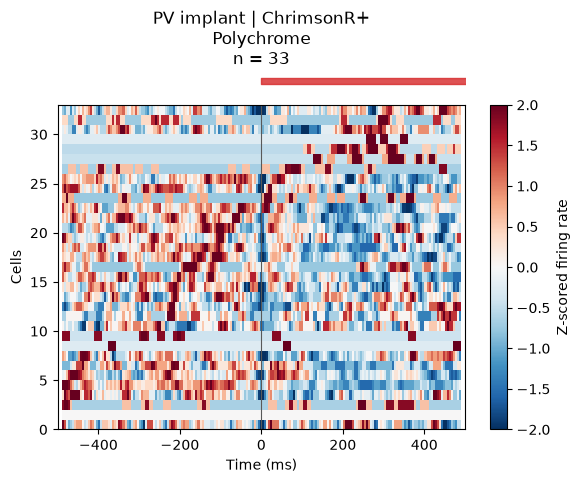

In [125]:
#48A
# ==========================================
# Plot single population heatmap
# ==========================================

"""
Plot one population heatmap selected by
alignment, experimental group, stimulus
condition and stimulation pattern.
"""

# ==========================================
# User settings
# ==========================================

plot_alignment = "onset"
# "onset"
# "offset"

plot_view = "Polychrome"
# "Polychrome"
# "Laser"

plot_comparison = "PV implant | ChrimsonR+"
# "PV implant | ChrimsonR−"

plot_stimulus = 1000

plot_size = (6, 5)
# Figure size in inches: (width, height)


# ==========================================
# Locate heatmap(s)
# ==========================================

matching_keys = []

for key, candidate in heatmap_data.items():

    if (

        candidate["alignment"] == plot_alignment

        and

        candidate["comparison_label"]
        == plot_comparison

        and

        candidate["group_value"]
        == plot_stimulus

        and

        candidate["view"]
        == plot_view

    ):

        matching_keys.append(key)


# ==========================================
# Validate selection
# ==========================================

if len(matching_keys) == 0:

    print(
        "Requested heatmap not found."
    )

elif len(matching_keys) > 1:

    print(
        "Multiple heatmaps match the requested "
        "alignment, view, comparison and stimulus."
    )

    print()

    print(
        "Available stimulation patterns:"
    )

    for key in matching_keys:

        print(
            f"  {heatmap_data[key]['pattern_key']}"
        )

    print()

    print(
        "Please select a more specific heatmap "
        "if a single stimulation pattern is required."
    )

else:

    selected_key = matching_keys[0]

    # ======================================
    # Load the selected heatmap
    # ======================================

    entry = heatmap_data[selected_key]

    matrix = entry["matrix"]

    time = entry["time"]

    stim_windows = entry["stim_windows"]

    # ======================================
    # Selection summary
    # ======================================

    print()

    print(
        "Selected heatmap"
    )

    print(
        "----------------"
    )

    print(
        f"Alignment   : {entry['alignment']}"
    )

    print(
        f"View        : {entry['view']}"
    )

    print(
        f"Comparison  : {entry['comparison_label']}"
    )

    print(
        f"Group value : {entry['group_value']}"
    )

    print(
        f"Pattern     : {entry['pattern_key']}"
    )

    print(
        f"Session     : {entry['session_id']}"
    )

    print(
        f"Recording   : {entry['rec_id']}"
    )

    print(
        f"Train       : {entry['train_id']}"
    )

    print(
        f"Units       : {matrix.shape[0]}"
    )

    print()

    # ======================================
    # Alignment
    # ======================================

    if plot_alignment == "offset":

        reference = next(

            stop

            for _, stop, label in stim_windows

            if label == plot_view

        )

    else:

        reference = 0

    # ======================================
    # Colour scaling
    # ======================================

    if heatmap_normalization == "global_zscore":

        vmin = -2
        vmax = 2

    elif heatmap_normalization == "max":

        vmin = 0
        vmax = 1

    else:

        vmin = None
        vmax = None

    # ======================================
    # Figure
    # ======================================

    fig, ax = plt.subplots(

        figsize=plot_size

    )

    image = ax.imshow(

        matrix,

        aspect="auto",

        origin="lower",

        extent=[

            time[0],

            time[-1],

            0,

            matrix.shape[0],

        ],

        cmap="RdBu_r",

        vmin=vmin,

        vmax=vmax,

        interpolation="none",

    )

    # --------------------------------------
    # Stimulus schematic
    # --------------------------------------

    stim_ax = ax.inset_axes(

        [0.0, 1.02, 1.0, 0.08]

    )

    stim_ax.set_xlim(analysis_window)

    stim_ax.set_ylim(0, 2)

    stim_ax.axis("off")

    for start, stop, label in stim_windows:

        start -= reference

        stop -= reference

        if label == "Laser":

            y = 1.1
            colour = "tab:red"

        else:

            y = 0.2
            colour = "tab:blue"

        stim_ax.fill_between(

            [start, stop],

            y,

            y + 0.5,

            color=colour,

            alpha=0.8,

        )

    # --------------------------------------
    # Alignment marker
    # --------------------------------------

    ax.axvline(

        0,

        color="0.35",

        linewidth=0.8,

    )

    # --------------------------------------
    # Axes
    # --------------------------------------

    ax.set_xlim(analysis_window)

    ax.set_xlabel("Time (ms)")

    ax.set_ylabel("Cells")

    ax.set_title(

        f"{entry['comparison_label']}\n"

        f"{entry['view']}\n"

        f"n = {matrix.shape[0]}",

    )

    # --------------------------------------
    # Colourbar
    # --------------------------------------

    cbar = plt.colorbar(

        image,

        ax=ax,

    )

    if heatmap_normalization == "global_zscore":

        cbar.set_label(

            "Z-scored firing rate"

        )

    elif heatmap_normalization == "max":

        cbar.set_label(

            "Normalized firing rate"

        )

    else:

        cbar.set_label(

            "Firing rate (Hz)"

        )

    plt.tight_layout()

    plt.show()

In [126]:
#48B
# ==========================================
# Find most responsive unit
# ==========================================

"""
Identify the unit with the largest mean response
within the current heatmap selection.
"""

# ==========================================
# Response window
# ==========================================

response_window = (10, 200)

response_mask = (

    (time >= response_window[0])

    &

    (time <= response_window[1])

)

# ==========================================
# Mean response
# ==========================================

response_strength = np.mean(

    matrix[:, response_mask],

    axis=1,

)

best_index = np.argmax(response_strength)

best_unit = entry["unit_ids"][best_index]

print()

print("Most responsive unit")

print("--------------------")

print(f"Index          : {best_index}")

print(f"Unit ID        : {best_unit}")

print(f"Response (Hz)  : {response_strength[best_index]:.2f}")


Most responsive unit
--------------------
Index          : 26
Unit ID        : uid_20260605_019
Response (Hz)  : 0.72


### Quantitative population analysis

#### 49 Configuration cell for quantitative analysis (SELECT PARAMETERS HERE)

In [127]:
#49
# ==========================================
# Population statistics configuration
# ==========================================

"""
Configure quantitative analyses based on unit PSTHs.

Each statistic is calculated from the trial-averaged
PSTH of each unit.

The following cells will

    #49A  Build statistics unit PSTHs
    #49B  Filter statistics PSTHs
    #50   Compute population statistics
    #51   Summarise statistics database
    #52   Shared plotting helper
    #53   Response firing rate
    #54   Response latency
"""

# ==========================================
# Recording selection
# ==========================================

statistics_protocol = "del2"
# "pow"
# "dur"
# "freq"
# "del"
# "del2"
# "longstim"
# None (= all)

statistics_stim_mode = "B"
# "P"
# "L"
# "B"
# None (= all)

statistics_laser_mode = "N"
# "N"
# "LC"
# None (= all)

statistics_view = "Polychrome"
# "Laser"
# "Polychrome"

statistics_include_units = "all"
# "responding"
# "unit_responding"
# "all"

statistics_baseline_mode = "onset_baseline"
# "onset_baseline"
# "pre_offset"

statistics_event = "onset"
# "onset"
# "offset"
# "both"

# ==========================================
# Plot settings
# ==========================================

statistics_plot_alignment = "onset"
# "onset"
# "offset"

# ==========================================
# Experimental grouping
# ==========================================

statistics_comparison_groups = [
    "implant",
    "chrimsonr",
]

# Examples
#
# ["implant"]
#
# ["chrimsonr"]
#
# ["implant", "chrimsonr"]

# ==========================================
# Comparison styles
# ==========================================

statistics_comparison_styles = build_comparison_styles(

    statistics_comparison_groups,

)

# ==========================================
# Comparison selection
# ==========================================

statistics_selected_comparison_keys = [

    ("functional", True),      # PV implant | ChrimsonR+
    ("functional", False),     # PV implant | ChrimsonR−

    ("nonfunctional", True),   # Inert implant | ChrimsonR+
    ("nonfunctional", False),  # Inert implant | ChrimsonR−

]

# None = plot every available comparison.
#
# Examples
#
# Only ChrimsonR−
#
# [
#     ("functional", False),
#     ("nonfunctional", False),
# ]
#
# Only PV implants
#
# [
#     ("functional", True),
#     ("functional", False),
# ]
#
# Only ChrimsonR+
#
# [
#     ("functional", True),
#     ("nonfunctional", True),
# ]
#
# Only inert implants
#
# [
#     ("nonfunctional", True),
#     ("nonfunctional", False),
# ]

# ==========================================
# Stimulus grouping
# ==========================================

statistics_stimulus_group = "group_value"

# ==========================================
# Stimulus selection
# ==========================================

statistics_selected_group_values = None

# None = plot all
#
# Example:
# [1, 10, 100, 1000]
#
# or
# [1, 30, 5000]

# ==========================================
# Baseline / response windows
# ==========================================

statistics_baseline_window = (-200, -100)

statistics_response_window = (10, 200)

statistics_peak_search_window = (10, 200)

# ==========================================
# Response detection
# ==========================================

statistics_response_polarity = "automatic"

# "automatic"
#     Use the pre-computed bootstrap significance
#     results to determine whether each unit shows
#     excitation, inhibition, or both, and detect
#     the appropriate peak.
#
# "excitation"
#     Always detect the maximum firing rate.
#
# "inhibition"
#     Always detect the minimum firing rate.
#
# "absolute"
#     Detect the largest absolute deviation
#     from baseline.
#
#     The sign of the peak is preserved.

# ==========================================
# Response onset
# ==========================================

statistics_latency_consecutive_bins = 3

# Number of consecutive significant bins required
# to define response onset.
#
# Significance itself is determined by the
# pre-computed bootstrap results:
#
#     bootstrap["excited_bins"]
#     bootstrap["inhibited_bins"]
#     bootstrap["valid_mask"]
#
# The statistics analysis does not independently
# apply a baseline-SD threshold.

# ==========================================
# Statistic to analyse
# ==========================================

statistics_statistic = "peak_rate"

# "baseline_rate"
#     Mean firing rate during the baseline window.
#
# "response_rate"
#     Mean firing rate across the response window.
#
# "peak_rate"
#     Maximum or minimum firing rate within the
#     peak search window.
#
# "peak_latency"
#     Time (ms) at which the detected peak occurs.
#
# "onset_latency"
#     First significant response bin detected
#     from the pre-computed bootstrap results.
#
#     Requires latency_consecutive_bins
#     consecutive significant bins.
#
#     This is the response onset latency, rather
#     than the latency of the response peak.
#
# "response_amplitude"
#     Peak firing rate minus baseline firing rate.
#
# "auc"
#     Area under the PSTH within the response window.
#
# "baseline_corrected_auc"
#     Area under the PSTH after subtracting the
#     baseline firing rate.
#
# "modulation_index"
#     (Peak − Baseline) / (Peak + Baseline)
#
# "peak_zscore"
#     Peak response expressed in units of baseline
#     standard deviation.

# ==========================================
# PSTH binning
# ==========================================

statistics_bin_width = 20.0

statistics_bin_start = -1000.0

statistics_bin_stop = 7000.0

# ==========================================
# Figure settings
# ==========================================

#statistics_plot_style = "box"
# "box"
# "violin"
# "bar"

statistics_show_points = True

statistics_show_mean = True

statistics_show_statistics = True

statistics_show_pairwise_statistics = True

# ==========================================
# Filter population summary
# ==========================================

statistics_filtered_summary = filter_population_summary(

    population_summary,

    protocol=statistics_protocol,

    stim_mode=statistics_stim_mode,

    laser_mode=statistics_laser_mode,

    view=statistics_view,

    baseline_mode=statistics_baseline_mode,

    event=statistics_event,

    include_units=statistics_include_units,

)

print(
    "\nDEBUG: statistics_filtered_summary"
)

print(
    "-----------------------------------"
)

print(
    "Shape:",
    statistics_filtered_summary.shape
)

print(
    "Columns:"
)

print(
    statistics_filtered_summary.columns.tolist()
)

print(
    "\nRelevant columns:"
)

display(

    statistics_filtered_summary[
        [
            "implant",
            "chrimsonr",
        ]
    ]
    .head(20)

)

# ==========================================
# Build comparison labels
# ==========================================

statistics_comparison_df = build_comparison_labels(

    statistics_filtered_summary,

    statistics_comparison_groups,

    comparison_styles=statistics_comparison_styles,

)

# ==========================================
# Summary
# ==========================================

print()

print(
    "Population statistics selection"
)

print(
    "-------------------------------"
)

print(
    f"Sessions   : "
    f"{statistics_comparison_df['session_id'].nunique()}"
)

print(
    f"Recordings : "
    f"{statistics_comparison_df['rec_id'].nunique()}"
)

print(
    f"Units      : "
    f"{statistics_comparison_df['unit_id'].nunique()}"
)

print(
    f"Conditions : "
    f"{statistics_comparison_df['group_value'].nunique()}"
)

print(
    f"Comparison : "
    f"{statistics_comparison_groups}"
)

print(
    f"Event      : "
    f"{statistics_event}"
)

print(
    f"Baseline   : "
    f"{statistics_baseline_mode}"
)

print(
    f"View       : "
    f"{statistics_view}"
)

if not statistics_comparison_df.empty:

    display(

        statistics_comparison_df[
            [
                "session_id",
                "rec_id",
                "unit_id",
                "comparison_label",
                "group_value",
            ]
        ]
        .sort_values(
            [
                "rec_id",
                "group_value",
                "unit_id",
            ]
        )
        .head(20)

    )

else:

    print()

    print(
        "No matching recordings."
    )


DEBUG: statistics_filtered_summary
-----------------------------------
Shape: (524, 25)
Columns:
['session_id', 'rec_id', 'unit_id', 'view', 'train_id', 'event', 'implant', 'chrimsonr', 'tags', 'laser_mode', 'stim_mode', 'protocol', 'baseline_mode', 'group_value', 'metadata', 'baseline_rate', 'baseline_ci_low', 'baseline_ci_high', 'response_type', 'responding', 'excited_bins', 'inhibited_bins', 'n_excited_bins', 'n_inhibited_bins', 'bootstrap_result']

Relevant columns:


,implant,chrimsonr
2016,nonfunctional,True
2018,nonfunctional,True
2020,nonfunctional,True
2022,nonfunctional,True
2048,nonfunctional,True
2050,nonfunctional,True
2052,nonfunctional,True
2054,nonfunctional,True
2080,nonfunctional,True
2082,nonfunctional,True



Population statistics selection
-------------------------------
Sessions   : 4
Recordings : 2
Units      : 92
Conditions : 3
Comparison : ['implant', 'chrimsonr']
Event      : onset
Baseline   : onset_baseline
View       : Polychrome


,session_id,rec_id,unit_id,comparison_label,group_value
7636,20260604_eye1_2nd,08_N_B_del2,uid_20260604_000,PV implant | ChrimsonR−,0.0
7638,20260604_eye1_2nd,08_N_B_del2,uid_20260604_000,PV implant | ChrimsonR−,0.0
14132,20260604_eye2_2nd,08_N_B_del2,uid_20260604_000,Inert implant | ChrimsonR−,0.0
14134,20260604_eye2_2nd,08_N_B_del2,uid_20260604_000,Inert implant | ChrimsonR−,0.0
7668,20260604_eye1_2nd,08_N_B_del2,uid_20260604_001,PV implant | ChrimsonR−,0.0
7670,20260604_eye1_2nd,08_N_B_del2,uid_20260604_001,PV implant | ChrimsonR−,0.0
14164,20260604_eye2_2nd,08_N_B_del2,uid_20260604_001,Inert implant | ChrimsonR−,0.0
14166,20260604_eye2_2nd,08_N_B_del2,uid_20260604_001,Inert implant | ChrimsonR−,0.0
7700,20260604_eye1_2nd,08_N_B_del2,uid_20260604_002,PV implant | ChrimsonR−,0.0
7702,20260604_eye1_2nd,08_N_B_del2,uid_20260604_002,PV implant | ChrimsonR−,0.0


#### 49A Build statistics unit PSTHs

In [128]:
#49A
# ==========================================
# Build statistics unit PSTHs
# ==========================================

"""
Build the unit-PSTH database specifically for
the population-statistics workflow.

This cell is independent of:

    #42 population-PSTH configuration
    #43 population spike database
    #46 general unit-PSTH database

The selected recordings and units are taken
directly from statistics_comparison_df, which
was created by #49.

The resulting statistics_source_unit_psth
uses the same data structure as unit_psth
from #46.

The PSTH binning is defined locally in this
cell so that the matrix and time axis always
have matching dimensions.
"""

# ==========================================
# Validate statistics selection
# ==========================================

if statistics_comparison_df.empty:

    raise RuntimeError(

        "statistics_comparison_df is empty.\n\n"

        "Check the population selection in #49."

    )

# ==========================================
# Statistics PSTH binning
# ==========================================

statistics_bin_starts = np.arange(

    statistics_bin_start,

    statistics_bin_stop,

    statistics_bin_width,

)

statistics_bin_ends = (

    statistics_bin_starts
    +
    statistics_bin_width

)

statistics_bin_centres = (

    statistics_bin_starts
    +
    statistics_bin_ends

) / 2

# ------------------------------------------
# Validate binning
# ------------------------------------------

if not (

    len(statistics_bin_starts)
    == len(statistics_bin_ends)
    == len(statistics_bin_centres)

):

    raise RuntimeError(

        "Statistics PSTH bin arrays have "
        "inconsistent lengths."

    )

print()

print(
    "Statistics PSTH binning"
)

print(
    "-----------------------"
)

print(
    f"Bin width : "
    f"{statistics_bin_width:g} ms"
)

print(
    f"Bins      : "
    f"{len(statistics_bin_centres)}"
)

print(
    f"Range     : "
    f"{statistics_bin_starts[0]:g} to "
    f"{statistics_bin_ends[-1]:g} ms"
)

# ==========================================
# Validate loaded sessions
# ==========================================

missing_sessions = sorted(

    set(

        statistics_comparison_df[
            "session_id"
        ].unique()

    )

    -

    set(all_data_io.keys())

)

if missing_sessions:

    raise RuntimeError(

        "The following sessions are missing "
        "from all_data_io:\n\n"

        + "\n".join(missing_sessions)

        +

        "\n\nPlease reload the selected sessions."

    )

# ==========================================
# Initialise statistics PSTH database
# ==========================================

statistics_source_unit_psth = {}

# ==========================================
# Loop over selected sessions
# ==========================================

for session_id in sorted(

    statistics_comparison_df[
        "session_id"
    ].unique()

):

    print(
        f"Session : {session_id}"
    )

    session_data = all_data_io[
        session_id
    ]

    session_summary = (

        statistics_comparison_df[

            statistics_comparison_df[
                "session_id"
            ]
            == session_id

        ]

    )

    # ======================================
    # Loop over selected recordings
    # ======================================

    for rec_id in sorted(

        session_summary[
            "rec_id"
        ].unique()

    ):

        print(
            f"  Loading {rec_id}"
        )

        # ----------------------------------
        # Determine recording configuration
        # ----------------------------------

        recording_protocol = (
            rec_id.split("_")[3]
        )

        recording_stim_mode = (
            rec_id.split("_")[2]
        )

        # ----------------------------------
        # Prepare recording analysis
        # ----------------------------------

        (
            burst_df,
            analysis_views,
            group_label,

        ) = prepare_recording_analysis(

            data_io=session_data,

            rec_id=rec_id,

            protocol=recording_protocol,

            stim_mode=recording_stim_mode,

            pchr_columns=pchr_columns,

            laser_columns=laser_columns,

        )

        # ----------------------------------
        # Select requested statistics view
        # ----------------------------------

        try:

            current_view = next(

                v

                for v in analysis_views

                if v["name"] == statistics_view

            )

        except StopIteration:

            available_views = [

                v["name"]

                for v in analysis_views

            ]

            raise RuntimeError(

                f"Requested statistics view "
                f"{statistics_view!r} is not available "
                f"for:\n\n"

                f"Session : {session_id}\n"

                f"Recording: {rec_id}\n\n"

                f"Available views: "
                f"{available_views}"

            )

        # ----------------------------------
        # Units belonging to this recording
        # ----------------------------------

        recording_summary = (

            session_summary[

                session_summary[
                    "rec_id"
                ]
                == rec_id

            ]

        )

        unit_ids = sorted(

            recording_summary[
                "unit_id"
            ].unique()

        )

        # ==================================
        # Loop over selected units
        # ==================================

        for unit_id in unit_ids:

            all_spiketimes = extract_spikes(

                session_data,

                rec_id,

                unit_id,

                verbose=False,

            )

            unit_summary = (

                recording_summary[

                    recording_summary[
                        "unit_id"
                    ]
                    == unit_id

                ]

            )

            # ==================================
            # Loop over selected stimulation
            # conditions
            # ==================================

            for _, row in unit_summary.iterrows():

                train_id = row[
                    "train_id"
                ]

                metadata = row[
                    "metadata"
                ]

                comparison_key = row[
                    "comparison_key"
                ]

                comparison_label = row[
                    "comparison_label"
                ]

                group_value = row[
                    "group_value"
                ]

                entry_baseline_mode = row[
                    "baseline_mode"
                ]

                # --------------------------------
                # Stimulus windows
                # --------------------------------

                alignment, stim_windows = (

                    current_view[
                        "stim_windows"
                    ](metadata)

                )

                # --------------------------------
                # Unique stimulation pattern
                # --------------------------------

                pattern_key = tuple(

                    (

                        int(round(start)),

                        int(round(stop)),

                        label,

                    )

                    for start, stop, label
                    in stim_windows

                )

                # --------------------------------
                # Obtain spikes for selected
                # statistics view
                # --------------------------------

                view_spikes = all_spiketimes[
                    statistics_view
                ]

                if train_id not in view_spikes:

                    continue

                trial_spikes = view_spikes[
                    train_id
                ]

                # =================================
                # Calculate onset and offset PSTHs
                # =================================

                alignment_results = {}

                for alignment_name in [

                    "onset",
                    "offset",

                ]:

                    # -----------------------------
                    # Select spike alignment
                    # -----------------------------

                    if alignment_name == "onset":

                        aligned_spikes = (
                            trial_spikes
                        )

                    else:

                        offset_time = next(

                            stop

                            for start, stop, label
                            in stim_windows

                            if label == statistics_view

                        )

                        aligned_spikes = [

                            np.asarray(
                                spiketrain
                            )
                            -
                            offset_time

                            for spiketrain
                            in trial_spikes

                        ]

                    # -----------------------------
                    # Calculate trial PSTHs
                    # -----------------------------

                    trial_rates = []

                    for spiketrain in aligned_spikes:

                        spiketrain = np.asarray(
                            spiketrain
                        )

                        counts = (

                            (

                                (
                                    spiketrain[:, None]
                                    >= statistics_bin_starts
                                )

                                &

                                (
                                    spiketrain[:, None]
                                    < statistics_bin_ends
                                )

                            )

                            .sum(axis=0)

                            * 1000

                            / statistics_bin_width

                        )

                        trial_rates.append(
                            counts
                        )

                    if len(trial_rates) == 0:

                        continue

                    trial_rates = np.asarray(
                        trial_rates
                    )

                    unit_psth_matrix = (
                        trial_rates.mean(axis=0)
                    )

                    # --------------------------------
                    # Internal consistency check
                    # --------------------------------

                    if (

                        unit_psth_matrix.shape[0]
                        !=
                        len(statistics_bin_centres)

                    ):

                        raise RuntimeError(

                            "Statistics PSTH dimension "
                            "mismatch.\n\n"

                            f"Session    : {session_id}\n"
                            f"Recording  : {rec_id}\n"
                            f"Unit       : {unit_id}\n"
                            f"Train      : {train_id}\n"
                            f"Alignment  : {alignment_name}\n\n"

                            f"Matrix bins: "
                            f"{unit_psth_matrix.shape[0]}\n"

                            f"Time bins  : "
                            f"{len(statistics_bin_centres)}"

                        )

                    alignment_results[
                        alignment_name
                    ] = unit_psth_matrix

                # =================================
                # Store both alignments
                # =================================

                for (
                    alignment_name,
                    unit_psth_matrix,
                ) in alignment_results.items():

                    key = (

                        alignment_name,

                        comparison_label,

                        group_value,

                        pattern_key,

                        session_id,

                        rec_id,

                        train_id,

                        unit_id,

                    )

                    statistics_source_unit_psth[
                        key
                    ] = {

                        "alignment":
                            alignment_name,

                        "comparison_key":
                            comparison_key,

                        "comparison_label":
                            comparison_label,

                        "group_value":
                            group_value,

                        "pattern_key":
                            pattern_key,

                        "session_id":
                            session_id,

                        "rec_id":
                            rec_id,

                        "train_id":
                            train_id,

                        "view":
                            statistics_view,

                        "baseline_mode":
                            entry_baseline_mode,

                        "metadata":
                            metadata,

                        "stim_windows":
                            stim_windows,

                        "time":
                            statistics_bin_centres,

                        "unit_ids":
                            [unit_id],

                        "matrix":
                            np.asarray(
                                [unit_psth_matrix]
                            ),

                    }

# ==========================================
# Summary
# ==========================================

total_source_statistics_units = sum(

    len(entry["unit_ids"])

    for entry
    in statistics_source_unit_psth.values()

)

print()

print(
    "Statistics source unit PSTHs"
)

print(
    "----------------------------"
)

print(
    f"Conditions : "
    f"{len(statistics_source_unit_psth)}"
)

print(
    f"Units      : "
    f"{total_source_statistics_units}"
)

print()

for key in sorted(
    statistics_source_unit_psth
):

    entry = statistics_source_unit_psth[
        key
    ]

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['comparison_label']:<30} | "

        f"{entry['group_value']:<8} | "

        f"{entry['session_id']} | "

        f"{entry['rec_id']} | "

        f"{entry['unit_ids'][0]}"

    )


Statistics PSTH binning
-----------------------
Bin width : 20 ms
Bins      : 400
Range     : -1000 to 7000 ms
Session : 20260603_eye2_2nd
  Loading 09_N_B_del2
Session : 20260604_eye1_2nd
  Loading 08_N_B_del2
Session : 20260604_eye2_2nd
  Loading 08_N_B_del2
Session : 20260605_eye1_2nd
  Loading 08_N_B_del2

Statistics source unit PSTHs
----------------------------
Conditions : 1048
Units      : 1048

offset | Inert implant | ChrimsonR+     | 0.0      | 20260603_eye2_2nd | 09_N_B_del2 | uid_20260603_000
offset | Inert implant | ChrimsonR+     | 0.0      | 20260603_eye2_2nd | 09_N_B_del2 | uid_20260603_001
offset | Inert implant | ChrimsonR+     | 0.0      | 20260603_eye2_2nd | 09_N_B_del2 | uid_20260603_002
offset | Inert implant | ChrimsonR+     | 0.0      | 20260603_eye2_2nd | 09_N_B_del2 | uid_20260603_003
offset | Inert implant | ChrimsonR+     | 0.0      | 20260603_eye2_2nd | 09_N_B_del2 | uid_20260603_004
offset | Inert implant | ChrimsonR+     | 0.0      | 20260603_eye2_2nd |

#### 49B Prepare statistics PSTHs

In [129]:
#49B
# ==========================================
# Prepare statistics PSTHs
# ==========================================

"""
Create the final statistics_unit_psth database
for the population statistics workflow.

The source PSTHs are constructed independently
in #49A from the statistics-specific population
selected in #49.

This cell filters those PSTHs using
statistics_filtered_summary.

The output structure is intentionally identical
to the original statistics_unit_psth database,
so downstream statistics cells remain unchanged.
"""

# ==========================================
# Valid units
# ==========================================

valid_units = set(

    zip(

        statistics_filtered_summary[
            "session_id"
        ],

        statistics_filtered_summary[
            "rec_id"
        ],

        statistics_filtered_summary[
            "unit_id"
        ],

        statistics_filtered_summary[
            "group_value"
        ],

    )

)

# ==========================================
# Build filtered PSTH database
# ==========================================

statistics_unit_psth = {}

for key, entry in (
    statistics_source_unit_psth.items()
):

    keep_units = []

    keep_matrix = []

    # --------------------------------------
    # Keep only selected units
    # --------------------------------------

    for row, unit_id in enumerate(
        entry["unit_ids"]
    ):

        lookup_key = (

            entry["session_id"],

            entry["rec_id"],

            unit_id,

            entry["group_value"],

        )

        if lookup_key not in valid_units:

            continue

        keep_units.append(
            unit_id
        )

        keep_matrix.append(

            entry["matrix"][row]

        )

    # --------------------------------------
    # Skip empty conditions
    # --------------------------------------

    if len(keep_units) == 0:

        continue

    statistics_entry = entry.copy()

    statistics_entry[
        "unit_ids"
    ] = keep_units

    statistics_entry[
        "matrix"
    ] = np.asarray(
        keep_matrix
    )

    statistics_unit_psth[
        key
    ] = statistics_entry

# ==========================================
# Summary
# ==========================================

total_statistics_units = sum(

    len(entry["unit_ids"])

    for entry
    in statistics_unit_psth.values()

)

print()

print(
    "Statistics PSTHs"
)

print(
    "----------------"
)

print(

    f"Source conditions : "
    f"{len(statistics_source_unit_psth)}"

)

print(

    f"Conditions        : "
    f"{len(statistics_unit_psth)}"

)

print(

    f"Units             : "
    f"{total_statistics_units}"

)

print()

for key in sorted(
    statistics_unit_psth
):

    entry = statistics_unit_psth[
        key
    ]

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['comparison_label']:<30} | "

        f"{entry['group_value']:<8} | "

        f"{len(entry['unit_ids']):>3} units"

    )


Statistics PSTHs
----------------
Source conditions : 1048
Conditions        : 1048
Units             : 1048

offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset | Inert implant | ChrimsonR+     | 0.0      |   1 units
offset 

#### 49C-E (Diagnostics)

In [130]:
# ==========================================
# #49C — Diagnostic: statistics unit matching
# ==========================================

print("\nDEBUG: #49 statistics unit matching")
print("------------------------------------")

print(
    "Filtered summary rows:",
    len(statistics_filtered_summary)
)

print(
    "Valid unit keys:",
    len(valid_units)
)

print(
    "Source statistics PSTH conditions:",
    len(statistics_source_unit_psth)
)

print(
    "Filtered statistics PSTH conditions:",
    len(statistics_unit_psth)
)

# ==========================================
# Check source statistics PSTHs
# ==========================================

n_source_entries_with_match = 0
n_source_entries_without_match = 0

n_source_matched_units = 0
n_source_total_units = 0

for key, entry in (
    statistics_source_unit_psth.items()
):

    entry_matches = 0

    for unit_id in entry["unit_ids"]:

        lookup_key = (

            entry["session_id"],

            entry["rec_id"],

            unit_id,

            entry["group_value"],

        )

        n_source_total_units += 1

        if lookup_key in valid_units:

            entry_matches += 1
            n_source_matched_units += 1

    if entry_matches > 0:

        n_source_entries_with_match += 1

    else:

        n_source_entries_without_match += 1


# ==========================================
# Check final statistics PSTHs
# ==========================================

n_final_matched_units = 0
n_final_total_units = 0

for key, entry in (
    statistics_unit_psth.items()
):

    for unit_id in entry["unit_ids"]:

        lookup_key = (

            entry["session_id"],

            entry["rec_id"],

            unit_id,

            entry["group_value"],

        )

        n_final_total_units += 1

        if lookup_key in valid_units:

            n_final_matched_units += 1


# ==========================================
# Matching results
# ==========================================

print()
print("Source matching results")
print("-----------------------")

print(
    "Total source unit entries checked :",
    n_source_total_units
)

print(
    "Matched source units              :",
    n_source_matched_units
)

print(
    "Source conditions with match      :",
    n_source_entries_with_match
)

print(
    "Source conditions without match   :",
    n_source_entries_without_match
)

print()
print("Final matching results")
print("----------------------")

print(
    "Total final unit entries checked :",
    n_final_total_units
)

print(
    "Matched final units              :",
    n_final_matched_units
)

print(
    "Final statistics conditions      :",
    len(statistics_unit_psth)
)

# ==========================================
# Check for unexpected final mismatches
# ==========================================

if (
    n_final_total_units > 0
    and
    n_final_matched_units
    != n_final_total_units
):

    print()

    print(
        "WARNING: Some final statistics units "
        "do not match valid_units."
    )

else:

    print()

    print(
        "All final statistics units match "
        "the #49 selection."
    )

# ==========================================
# Show examples of valid units
# ==========================================

print()
print("Example valid_units keys")
print("------------------------")

for key in list(valid_units)[:10]:

    print(key)

# ==========================================
# Show examples of source PSTHs
# ==========================================

print()
print("Example source statistics PSTHs")
print("--------------------------------")

for key, entry in list(
    statistics_source_unit_psth.items()
)[:10]:

    print(
        "key:",
        key
    )

    print(
        "  session_id   :",
        entry["session_id"]
    )

    print(
        "  rec_id       :",
        entry["rec_id"]
    )

    print(
        "  group_value  :",
        entry["group_value"]
    )

    print(
        "  comparison   :",
        entry["comparison_label"]
    )

    print(
        "  unit_ids     :",
        entry["unit_ids"][:10]
    )

    print()

# ==========================================
# Show examples of final PSTHs
# ==========================================

print()
print("Example final statistics PSTHs")
print("------------------------------")

for key, entry in list(
    statistics_unit_psth.items()
)[:10]:

    print(
        "key:",
        key
    )

    print(
        "  session_id   :",
        entry["session_id"]
    )

    print(
        "  rec_id       :",
        entry["rec_id"]
    )

    print(
        "  group_value  :",
        entry["group_value"]
    )

    print(
        "  comparison   :",
        entry["comparison_label"]
    )

    print(
        "  unit_ids     :",
        entry["unit_ids"][:10]
    )

    print()


DEBUG: #49 statistics unit matching
------------------------------------
Filtered summary rows: 524
Valid unit keys: 393
Source statistics PSTH conditions: 1048
Filtered statistics PSTH conditions: 1048

Source matching results
-----------------------
Total source unit entries checked : 1048
Matched source units              : 1048
Source conditions with match      : 1048
Source conditions without match   : 0

Final matching results
----------------------
Total final unit entries checked : 1048
Matched final units              : 1048
Final statistics conditions      : 1048

All final statistics units match the #49 selection.

Example valid_units keys
------------------------
('20260604_eye1_2nd', '08_N_B_del2', 'uid_20260604_020', 0.0)
('20260604_eye2_2nd', '08_N_B_del2', 'uid_20260604_031', 1000.0)
('20260603_eye2_2nd', '09_N_B_del2', 'uid_20260603_007', 1000.0)
('20260604_eye1_2nd', '08_N_B_del2', 'uid_20260604_017', 0.0)
('20260605_eye1_2nd', '08_N_B_del2', 'uid_20260605_023', 0.0)

In [131]:
# ==========================================
# #49D — Check statistics view against
# population summary
# ==========================================

print("\nDEBUG: statistics view consistency")
print("----------------------------------")

print(
    "Configured statistics view:",
    view
)

print()

print(
    "population_summary views:"
)

print(
    population_summary[
        "view"
    ]
    .value_counts(dropna=False)
)

print()

print(
    "statistics_filtered_summary views:"
)

print(
    statistics_filtered_summary[
        "view"
    ]
    .value_counts(dropna=False)
)

print()

print(
    "statistics_unit_psth views:"
)

statistics_psth_views = []

for entry in statistics_unit_psth.values():

    statistics_psth_views.append(
        entry["view"]
    )

print(
    pd.Series(
        statistics_psth_views
    ).value_counts(dropna=False)
)


DEBUG: statistics view consistency
----------------------------------
Configured statistics view: Polychrome

population_summary views:
view
Polychrome    10932
Laser         10480
Name: count, dtype: int64

statistics_filtered_summary views:
view
Polychrome    524
Name: count, dtype: int64

statistics_unit_psth views:
Polychrome    1048
Name: count, dtype: int64


In [132]:
# ==========================================
# #49E — Inspect bootstrap entry
# ==========================================

entry = next(
    iter(
        statistics_unit_psth.values()
    )
)

session_id = entry["session_id"]
rec_id = entry["rec_id"]
unit_id = entry["unit_ids"][0]
baseline_mode_value = entry["baseline_mode"]
entry_view = entry["view"]
train_id = entry["train_id"]

print("\nDEBUG: bootstrap entry")
print("---------------------")

print(
    "session_id   :",
    session_id
)

print(
    "rec_id       :",
    rec_id
)

print(
    "unit_id      :",
    unit_id
)

print(
    "baseline     :",
    baseline_mode_value
)

print(
    "view         :",
    entry_view
)

print(
    "train_id     :",
    train_id
)

print()

# ------------------------------------------
# Navigate bootstrap hierarchy
# ------------------------------------------

session_results = population_bootstrap[
    session_id
]

print(
    "Available recordings:"
)

print(
    list(session_results.keys())
)

recording_results = session_results[
    rec_id
]

print()

print(
    "Available units:"
)

print(
    list(recording_results.keys())[:20]
)

unit_results = recording_results[
    unit_id
]

print()

print(
    "Available baseline modes:"
)

print(
    list(unit_results.keys())
)

baseline_results = unit_results[
    baseline_mode_value
]

print()

print(
    "Available views:"
)

print(
    list(baseline_results.keys())
)

if entry_view in baseline_results:

    view_results = baseline_results[
        entry_view
    ]

    print()

    print(
        "Available trains:"
    )

    print(
        list(view_results.keys())
    )

else:

    print()

    print(
        "REQUESTED VIEW IS NOT PRESENT:"
    )

    print(
        entry_view
    )


DEBUG: bootstrap entry
---------------------
session_id   : 20260603_eye2_2nd
rec_id       : 09_N_B_del2
unit_id      : uid_20260603_000
baseline     : onset_baseline
view         : Polychrome
train_id     : tid_037_09

Available recordings:
['01_N_P_pow', '02_N_L_pow', '05_N_P_dur', '06_N_L_dur', '08_N_B_del', '09_N_B_del2', '11_N_P_longstim']

Available units:
['uid_20260603_000', 'uid_20260603_001', 'uid_20260603_002', 'uid_20260603_003', 'uid_20260603_004', 'uid_20260603_005', 'uid_20260603_006', 'uid_20260603_007', 'uid_20260603_008', 'uid_20260603_009', 'uid_20260603_010', 'uid_20260603_011', 'uid_20260603_012', 'uid_20260603_013', 'uid_20260603_014', 'uid_20260603_015', 'uid_20260603_016', 'uid_20260603_017']

Available baseline modes:
['onset_baseline', 'pre_offset']

Available views:
['Polychrome', 'Laser']

Available trains:
['tid_037_09', 'tid_038_09', 'tid_039_09', 'tid_040_09']


In [133]:
#49E
# ==========================================
# DEBUG — Check statistics PSTH dimensions
# ==========================================

print(
    "\nDEBUG: statistics PSTH dimensions"
)

print(
    "---------------------------------"
)

for key, entry in statistics_unit_psth.items():

    matrix_bins = entry[
        "matrix"
    ].shape[1]

    time_bins = len(
        entry["time"]
    )

    if matrix_bins != time_bins:

        print()

        print(
            "MISMATCH"
        )

        print(
            "Key        :",
            key
        )

        print(
            "Alignment  :",
            entry["alignment"]
        )

        print(
            "Session    :",
            entry["session_id"]
        )

        print(
            "Recording  :",
            entry["rec_id"]
        )

        print(
            "Train      :",
            entry["train_id"]
        )

        print(
            "View       :",
            entry["view"]
        )

        print(
            "Group      :",
            entry["group_value"]
        )

        print(
            "Matrix bins:",
            matrix_bins
        )

        print(
            "Time bins  :",
            time_bins
        )

        print(
            "Time range:",
            (
                entry["time"][0],
                entry["time"][-1]
            )
        )

        print()

        break

else:

    print(
        "All statistics PSTHs have matching "
        "matrix and time dimensions."
    )


DEBUG: statistics PSTH dimensions
---------------------------------
All statistics PSTHs have matching matrix and time dimensions.


#### 50 Compute population statistics

In [134]:
#50A
# ==========================================
# Compute population statistics
# Part 1 - Prepare statistics table
# ==========================================

"""
Compute quantitative statistics from the
trial-averaged PSTH of every unit.

Each row of the final table corresponds to one
unit under one stimulation condition.

Configuration is taken exclusively from the
statistics_* variables defined in #49.

PSTH-specific metadata such as view, baseline
mode, alignment and train_id are taken directly
from statistics_unit_psth.
"""

population_statistics = []

# ==========================================
# Bootstrap helper
# ==========================================

def get_bootstrap_result(

    session_id,
    rec_id,
    unit_id,
    baseline_mode,
    view,
    train_id,
    alignment,

):
    """
    Return the bootstrap result corresponding to one
    unit, stimulus condition and alignment.
    """

    event_name = (

        "onset"

        if alignment == "onset"

        else "offset"

    )

    return (

        population_bootstrap

        [session_id]

        [rec_id]

        [unit_id]

        [baseline_mode]

        [view]

        [train_id]

        [event_name]

    )

# ==========================================
# Loop over statistics PSTHs
# ==========================================

for key, entry in statistics_unit_psth.items():

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['comparison_label']:<20} | "

        f"{entry['group_value']}"

    )

    matrix = entry["matrix"]

    unit_ids = entry["unit_ids"]

    time = entry["time"]

    # --------------------------------------
    # Analysis windows
    # --------------------------------------

    baseline_mask = (

        (time >= statistics_baseline_window[0])

        &

        (time <= statistics_baseline_window[1])

    )

    response_mask = (

        (time >= statistics_response_window[0])

        &

        (time <= statistics_response_window[1])

    )

    peak_mask = (

        (time >= statistics_peak_search_window[0])

        &

        (time <= statistics_peak_search_window[1])

    )

    # --------------------------------------
    # Validate matrix/time dimensions
    # --------------------------------------

    if matrix.shape[1] != len(time):

        raise ValueError(

            f"Matrix has {matrix.shape[1]} bins "

            f"but time axis has {len(time)}."

        )

    # ======================================
    # PSTH metadata
    # ======================================

    metadata = entry["metadata"]

    session_id = entry["session_id"]

    rec_id = entry["rec_id"]

    train_id = entry["train_id"]

    entry_view = entry["view"]

    entry_baseline_mode = entry[
        "baseline_mode"
    ]

    stim_windows = entry[
        "stim_windows"
    ]

    comparison_key = entry[
        "comparison_key"
    ]

    comparison_label = entry[
        "comparison_label"
    ]

    group_value = entry[
        "group_value"
    ]

    alignment = entry[
        "alignment"
    ]

    pattern_key = entry[
        "pattern_key"
    ]

    # --------------------------------------
    # Event corresponding to alignment
    # --------------------------------------

    event_name = (

        "onset"

        if alignment == "onset"

        else "offset"

    )

    # ======================================
    # Compute one statistics row per unit
    # ======================================

    for unit_index, unit_id in enumerate(
        unit_ids
    ):

        psth = matrix[
            unit_index
        ]

        # ----------------------------------
        # Baseline rate
        # ----------------------------------

        baseline_rate = np.mean(

            psth[
                baseline_mask
            ]

        )

        # ----------------------------------
        # Response rate
        # ----------------------------------

        response_rate = np.mean(

            psth[
                response_mask
            ]

        )

        # ----------------------------------
        # Peak search region
        # ----------------------------------

        response_curve = psth[
            peak_mask
        ]

        response_time = time[
            peak_mask
        ]

        # ==================================
        # Baseline statistics
        # ==================================

        baseline_sd = np.std(

            psth[
                baseline_mask
            ],

            ddof=1,

        )

        # ==================================
        # Bootstrap significance
        # ==================================

        bootstrap = get_bootstrap_result(

            session_id=session_id,

            rec_id=rec_id,

            unit_id=unit_id,

            baseline_mode=entry_baseline_mode,

            view=entry_view,

            train_id=train_id,

            alignment=alignment,

        )

        significant_bins = (

            bootstrap[
                "excited_bins"
            ]

            |

            bootstrap[
                "inhibited_bins"
            ]

        )

        valid_bins = bootstrap[
            "valid_mask"
        ]

        candidate_bins = (

            significant_bins
            &
            valid_bins

        )

        bin_centres = bootstrap[
            "bin_centres"
        ]

        # ==================================
        # Onset latency
        # ==================================

        onset_latency = np.nan

        consecutive = (
            statistics_latency_consecutive_bins
        )

        indices = np.where(
            candidate_bins
        )[0]

        for start in range(

            len(indices)
            - consecutive
            + 1

        ):

            window = indices[

                start :

                start + consecutive

            ]

            if np.all(

                np.diff(window) == 1

            ):

                onset_latency = (

                    bin_centres[
                        window[0]
                    ]

                    -

                    bootstrap[
                        "time_shift"
                    ]

                )

                break

        # ==================================
        # Response statistics
        # ==================================

        response_sd = np.std(

            psth[
                response_mask
            ],

            ddof=1,

        )

        # ==================================
        # Response detection
        # ==================================

        excited = np.any(

            bootstrap[
                "excited_bins"
            ]

            &

            valid_bins

        )

        inhibited = np.any(

            bootstrap[
                "inhibited_bins"
            ]

            &

            valid_bins

        )

        # ==================================
        # Determine response polarity
        # ==================================

        if (
            statistics_response_polarity
            == "automatic"
        ):

            if excited and not inhibited:

                mode = "excitation"

            elif inhibited and not excited:

                mode = "inhibition"

            elif excited and inhibited:

                mode = "absolute"

            else:

                mode = "absolute"

        elif statistics_response_polarity in (

            "excitation",
            "inhibition",
            "absolute",

        ):

            mode = (
                statistics_response_polarity
            )

        else:

            raise ValueError(

                "Unknown "
                "statistics_response_polarity: "

                f"{statistics_response_polarity}"

            )

        # ==================================
        # Detect response peak
        # ==================================

        if mode == "excitation":

            peak_index = np.argmax(

                response_curve

            )

        elif mode == "inhibition":

            peak_index = np.argmin(

                response_curve

            )

        elif mode == "absolute":

            peak_index = np.argmax(

                np.abs(
                    response_curve
                )

            )

        peak_rate = response_curve[
            peak_index
        ]

        peak_latency = response_time[
            peak_index
        ]

        detected_polarity = mode

        # ==================================
        # Response amplitude
        # ==================================

        response_amplitude = (

            peak_rate
            -
            baseline_rate

        )

        # ==================================
        # Area under curve
        # ==================================

        auc = np.trapezoid(

            response_curve,

            response_time,

        )

        # ==================================
        # Baseline-corrected AUC
        # ==================================

        baseline_corrected_auc = (

            np.trapezoid(

                response_curve
                -
                baseline_rate,

                response_time,

            )

        )

        # ==================================
        # Modulation index
        # ==================================

        denominator = (

            peak_rate
            +
            baseline_rate

        )

        if denominator == 0:

            modulation_index = np.nan

        else:

            modulation_index = (

                (
                    peak_rate
                    -
                    baseline_rate
                )

                /

                denominator

            )

        # ==================================
        # Peak z-score
        # ==================================

        if baseline_sd == 0:

            peak_zscore = np.nan

        else:

            peak_zscore = (

                peak_rate
                -
                baseline_rate

            ) / baseline_sd

        # ==================================
        # Store statistics
        # ==================================

        population_statistics.append(

            {

                "session_id":
                    session_id,

                "rec_id":
                    rec_id,

                "train_id":
                    train_id,

                # ----------------------------------
                # Established data schema
                # ----------------------------------

                "view":
                    entry_view,

                "baseline_mode":
                    entry_baseline_mode,

                "event":
                    event_name,

                "alignment":
                    alignment,

                # ----------------------------------
                # Experimental grouping
                # ----------------------------------

                "comparison_key":
                    comparison_key,

                "comparison_label":
                    comparison_label,

                "group_value":
                    group_value,

                "pattern_key":
                    pattern_key,

                "unit_id":
                    unit_id,

                "metadata":
                    metadata,

                "stim_windows":
                    stim_windows,

                # ----------------------------------
                # Firing-rate statistics
                # ----------------------------------

                "baseline_rate":
                    baseline_rate,

                "baseline_sd":
                    baseline_sd,

                "response_rate":
                    response_rate,

                "response_sd":
                    response_sd,

                "peak_rate":
                    peak_rate,

                "peak_latency":
                    peak_latency,

                # ----------------------------------
                # Response classification
                # ----------------------------------

                "detected_response_polarity":
                    detected_polarity,

                "has_excitation":
                    excited,

                "has_inhibition":
                    inhibited,

                "onset_latency":
                    onset_latency,

                # ----------------------------------
                # Response magnitude
                # ----------------------------------

                "response_amplitude":
                    response_amplitude,

                "auc":
                    auc,

                "baseline_corrected_auc":
                    baseline_corrected_auc,

                "modulation_index":
                    modulation_index,

                "peak_zscore":
                    peak_zscore,

            }

        )

# ==========================================
# Build statistics table
# ==========================================

population_statistics = pd.DataFrame(
    population_statistics
)

print(
    population_statistics.columns.tolist()
)

# ==========================================
# Summary
# ==========================================

print()

print(
    "Population statistics"
)

print(
    "---------------------"
)

print(
    f"Rows : "
    f"{len(population_statistics)}"
)

print(
    f"Units: "
    f"{population_statistics['unit_id'].nunique()}"
)

print()

display(
    population_statistics.head()
)

 onset | Inert implant | ChrimsonR+ | 0.0
offset | Inert implant | ChrimsonR+ | 0.0
 onset | Inert implant | ChrimsonR+ | 875.0
offset | Inert implant | ChrimsonR+ | 875.0
 onset | Inert implant | ChrimsonR+ | 1000.0
offset | Inert implant | ChrimsonR+ | 1000.0
 onset | Inert implant | ChrimsonR+ | 0.0
offset | Inert implant | ChrimsonR+ | 0.0
 onset | Inert implant | ChrimsonR+ | 0.0
offset | Inert implant | ChrimsonR+ | 0.0
 onset | Inert implant | ChrimsonR+ | 875.0
offset | Inert implant | ChrimsonR+ | 875.0
 onset | Inert implant | ChrimsonR+ | 1000.0
offset | Inert implant | ChrimsonR+ | 1000.0
 onset | Inert implant | ChrimsonR+ | 0.0
offset | Inert implant | ChrimsonR+ | 0.0
 onset | Inert implant | ChrimsonR+ | 0.0
offset | Inert implant | ChrimsonR+ | 0.0
 onset | Inert implant | ChrimsonR+ | 875.0
offset | Inert implant | ChrimsonR+ | 875.0
 onset | Inert implant | ChrimsonR+ | 1000.0
offset | Inert implant | ChrimsonR+ | 1000.0
 onset | Inert implant | ChrimsonR+ | 0.0
offs

,session_id,rec_id,train_id,view,baseline_mode,event,alignment,comparison_key,comparison_label,group_value,...,peak_latency,detected_response_polarity,has_excitation,has_inhibition,onset_latency,response_amplitude,auc,baseline_corrected_auc,modulation_index,peak_zscore
0,20260603_eye2_2nd,09_N_B_del2,tid_037_09,Polychrome,onset_baseline,onset,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,0.0,...,30.0,absolute,True,True,20.0,326.000000,29033.333333,25913.333333,0.903882,67.893751
1,20260603_eye2_2nd,09_N_B_del2,tid_037_09,Polychrome,onset_baseline,offset,offset,"(nonfunctional, True)",Inert implant | ChrimsonR+,0.0,...,50.0,absolute,False,False,NaN,-48.333333,1333.333333,-10366.666667,-0.591837,-0.384098
2,20260603_eye2_2nd,09_N_B_del2,tid_038_09,Polychrome,onset_baseline,onset,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,875.0,...,70.0,absolute,False,False,NaN,9.000000,2316.666667,36.666667,0.262136,1.539718
3,20260603_eye2_2nd,09_N_B_del2,tid_038_09,Polychrome,onset_baseline,offset,offset,"(nonfunctional, True)",Inert implant | ChrimsonR+,875.0,...,30.0,absolute,False,False,NaN,-53.333333,1350.000000,-10650.000000,-0.666667,-0.417668
4,20260603_eye2_2nd,09_N_B_del2,tid_039_09,Polychrome,onset_baseline,onset,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,1000.0,...,170.0,absolute,False,False,NaN,11.333333,3433.333333,373.333333,0.250000,1.946834


#### Plot single unit PSTH diagnostic

In [135]:
# #50C
# # ==========================================
# # Plot single unit PSTH
# # ==========================================

# """
# Plot the PSTH of a selected unit from the
# statistics PSTH database.

# Useful for verifying that the PSTH used by
# the population statistics corresponds to the
# expected recording condition and response.
# """

# # ==========================================
# # Unit selection
# # ==========================================

# selected_unit = "uid_20260604_011"

# # ==========================================
# # Locate unit
# # ==========================================

# matches = []

# for key, entry in statistics_unit_psth.items():

#     if selected_unit in entry["unit_ids"]:

#         matches.append(entry)

# # ==========================================
# # Check
# # ==========================================

# if len(matches) == 0:

#     raise ValueError(

#         f"{selected_unit} not found in "
#         "statistics_unit_psth."

#     )

# # ==========================================
# # Diagnostic
# # ==========================================

# print()

# print("Unit found in")
# print("-------------")

# for entry in matches:

#     print(

#         f"{entry['alignment']:>6} | "

#         f"{entry['comparison_label']:<30} | "

#         f"{entry['group_value']}"

#     )

# # ==========================================
# # Select requested dataset
# # ==========================================

# selected_entry = None

# for entry in matches:

#     if (

#         entry["alignment"]
#         == statistics_plot_alignment

#         and

#         entry["comparison_label"]
#         == statistics_plot_comparison

#         and

#         entry["group_value"]
#         == statistics_plot_stimulus

#     ):

#         selected_entry = entry

#         break

# # ------------------------------------------
# # Fallback
# # ------------------------------------------

# if selected_entry is None:

#     print()

#     print(
#         "Requested condition not found."
#     )

#     print(
#         "Requested:"
#     )

#     print(
#         f"    Alignment   : "
#         f"{statistics_plot_alignment}"
#     )

#     print(
#         f"    Comparison  : "
#         f"{statistics_plot_comparison}"
#     )

#     print(
#         f"    Stimulus    : "
#         f"{statistics_plot_stimulus}"
#     )

#     print()

#     print(
#         "Using first available dataset instead."
#     )

#     selected_entry = matches[0]

# # ==========================================
# # Extract PSTH
# # ==========================================

# unit_index = selected_entry[
#     "unit_ids"
# ].index(

#     selected_unit

# )

# psth = selected_entry[
#     "matrix"
# ][
#     unit_index
# ]

# time = selected_entry[
#     "time"
# ]

# # ==========================================
# # Validate PSTH dimensions
# # ==========================================

# if len(time) != len(psth):

#     raise RuntimeError(

#         "PSTH/time dimension mismatch.\n\n"

#         f"Time bins : {len(time)}\n"
#         f"PSTH bins : {len(psth)}"

#     )

# # ==========================================
# # Plot
# # ==========================================

# fig, ax = plt.subplots(

#     figsize=(8, 4)

# )

# ax.plot(

#     time,

#     psth,

#     color="k",

#     linewidth=2,

# )

# # ==========================================
# # Baseline window
# # ==========================================

# ax.axvspan(

#     statistics_baseline_window[0],

#     statistics_baseline_window[1],

#     color="lightgrey",

#     alpha=0.3,

#     label="Baseline",

# )

# # ==========================================
# # Response window
# # ==========================================

# ax.axvspan(

#     statistics_response_window[0],

#     statistics_response_window[1],

#     color="tab:red",

#     alpha=0.15,

#     label="Response",

# )

# # ==========================================
# # Alignment
# # ==========================================

# ax.axvline(

#     0,

#     color="0.3",

#     linestyle="--",

# )

# # ==========================================
# # Axis limits
# # ==========================================

# ax.set_xlim(

#     statistics_plot_window

# )

# # ==========================================
# # Labels
# # ==========================================

# ax.set_xlabel(
#     "Time (ms)"
# )

# ax.set_ylabel(
#     "Firing rate (Hz)"
# )

# # ==========================================
# # Title
# # ==========================================

# ax.set_title(

#     f"{selected_unit}\n"
#     f"{selected_entry['comparison_label']}\n"
#     f"{selected_entry['group_value']}"

# )

# # ==========================================
# # Appearance
# # ==========================================

# ax.spines[
#     "top"
# ].set_visible(False)

# ax.spines[
#     "right"
# ].set_visible(False)

# ax.legend(
#     frameon=False
# )

# plt.tight_layout()

# plt.show()

#### 51 Prepare plotting summary

In [136]:
#51
# ==========================================
# Prepare plotting summary
# ==========================================

"""
Summarize unit-level statistics for plotting.

Each row of the output corresponds to one
experimental group and one stimulus condition.

The resulting dataframe is used by all
publication-quality plotting cells.

Configuration is taken from the statistics_*
namespace defined in #49.
"""

# ==========================================
# Select metric
# ==========================================

statistics_metric = statistics_statistic

statistics_metric_labels = {

    "baseline_rate":
        "Baseline firing rate (Hz)",

    "response_rate":
        "Response firing rate (Hz)",

    "peak_rate":
        "Peak firing rate (Hz)",

    "peak_latency":
        "Peak latency (ms)",

    "onset_latency":
        "Response onset latency (ms)",

    "response_amplitude":
        "Response amplitude (Hz)",

    "auc":
        "Area under curve",

    "baseline_corrected_auc":
        "Baseline-corrected AUC",

    "modulation_index":
        "Modulation index",

    "peak_zscore":
        "Peak z-score",

}

# ------------------------------------------
# Validate selected metric
# ------------------------------------------

if statistics_metric not in (
    statistics_metric_labels
):

    raise ValueError(

        "Unknown statistics metric: "
        f"{statistics_metric}"

    )

statistics_metric_label = (
    statistics_metric_labels[
        statistics_metric
    ]
)

# ==========================================
# Validate source data
# ==========================================

if population_statistics.empty:

    raise RuntimeError(

        "population_statistics is empty.\n\n"

        "Run #50 before running #51."

    )

if statistics_metric not in (
    population_statistics.columns
):

    raise KeyError(

        f"Selected metric "
        f"{statistics_metric!r} is not present "
        "in population_statistics.\n\n"

        "Available columns:\n"

        + "\n".join(
            population_statistics.columns
        )

    )

# ==========================================
# Aggregate statistics
# ==========================================

statistics_plotting_summary = (

    population_statistics

    .groupby(

        [

            "alignment",

            "comparison_label",

            "group_value",

        ],

        as_index=False,

    )

    .agg(

        mean=(

            statistics_metric,

            "mean",

        ),

        median=(

            statistics_metric,

            "median",

        ),

        sd=(

            statistics_metric,

            "std",

        ),

        sem=(

            statistics_metric,

            "sem",

        ),

        n=(

            statistics_metric,

            "count",

        ),

    )

)

# ==========================================
# Sort rows
# ==========================================

statistics_plotting_summary = (

    statistics_plotting_summary

    .sort_values(

        [

            "alignment",

            "comparison_label",

            "group_value",

        ]

    )

    .reset_index(

        drop=True

    )

)

# ==========================================
# Store analysis metadata
# ==========================================

statistics_plotting_summary[
    "metric"
] = statistics_metric

statistics_plotting_summary[
    "metric_label"
] = statistics_metric_label

statistics_plotting_summary[
    "view"
] = statistics_view

statistics_plotting_summary[
    "baseline_mode"
] = statistics_baseline_mode

statistics_plotting_summary[
    "event"
] = statistics_event

# ==========================================
# Summary
# ==========================================

print()

print(
    "Plotting summary"
)

print(
    "----------------"
)

print(

    f"Metric : "
    f"{statistics_metric_label}"

)

print(

    f"Rows   : "
    f"{len(statistics_plotting_summary)}"

)

print(

    f"Groups : "

    f"{statistics_plotting_summary['comparison_label'].nunique()}"

)

print(

    f"Stimuli: "

    f"{statistics_plotting_summary['group_value'].nunique()}"

)

print()

print(
    "Stimulus values"
)

print(

    sorted(

        statistics_plotting_summary[
            "group_value"
        ].unique()

    )

)

display(

    statistics_plotting_summary

)


Plotting summary
----------------
Metric : Peak firing rate (Hz)
Rows   : 24
Groups : 4
Stimuli: 3

Stimulus values
[np.float64(0.0), np.float64(875.0), np.float64(1000.0)]


,alignment,comparison_label,group_value,mean,median,sd,sem,n,metric,metric_label,view,baseline_mode,event
0,offset,Inert implant | ChrimsonR+,0.0,28.796296,22.500000,20.434219,3.405703,36,peak_rate,Peak firing rate (Hz),Polychrome,onset_baseline,onset
1,offset,Inert implant | ChrimsonR+,875.0,20.925926,20.000000,21.021482,4.954811,18,peak_rate,Peak firing rate (Hz),Polychrome,onset_baseline,onset
2,offset,Inert implant | ChrimsonR+,1000.0,20.462963,20.833333,18.093851,4.264762,18,peak_rate,Peak firing rate (Hz),Polychrome,onset_baseline,onset
3,offset,Inert implant | ChrimsonR−,0.0,9.764957,3.333333,12.917555,1.462625,78,peak_rate,Peak firing rate (Hz),Polychrome,onset_baseline,onset
4,offset,Inert implant | ChrimsonR−,875.0,7.435897,1.666667,12.993735,2.080663,39,peak_rate,Peak firing rate (Hz),Polychrome,onset_baseline,onset
5,offset,Inert implant | ChrimsonR−,1000.0,9.572650,3.333333,12.376394,1.981809,39,peak_rate,Peak firing rate (Hz),Polychrome,onset_baseline,onset
6,offset,PV implant | ChrimsonR+,0.0,15.101010,6.666667,18.892134,2.325461,66,peak_rate,Peak firing rate (Hz),Polychrome,onset_baseline,onset
7,offset,PV implant | ChrimsonR+,875.0,6.414141,1.666667,10.426006,1.814935,33,peak_rate,Peak firing rate (Hz),Polychrome,onset_baseline,onset
8,offset,PV implant | ChrimsonR+,1000.0,17.020202,1.666667,25.412423,4.423735,33,peak_rate,Peak firing rate (Hz),Polychrome,onset_baseline,onset
9,offset,PV implant | ChrimsonR−,0.0,23.617886,20.833333,17.284445,1.908748,82,peak_rate,Peak firing rate (Hz),Polychrome,onset_baseline,onset


#### 52 Plotting helper

In [137]:
#52
# ==========================================
# Publication plotting helper
# ==========================================

"""
Shared plotting functions for publication-
quality population statistics.

Each point represents one unit.

The helper draws

    • boxplots
    • jittered unit values
    • mean ± SEM

Statistical annotations are added later.

All configuration is taken from the
statistics_* namespace defined in #49.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==========================================
# Appearance
# ==========================================

statistics_box_width = 0.32

statistics_group_spacing = 0.40

statistics_condition_spacing = 1.8

statistics_jitter_width = 0.06

statistics_point_size = 24

statistics_point_alpha = 0.70

statistics_mean_size = 70

# ==========================================
# Plot helper
# ==========================================

def plot_population_statistic(

    data,

    metric,

    ylabel,

):

    """
    Plot one population statistic.

    Parameters
    ----------
    data : pandas.DataFrame

        Population statistics or a compatible
        statistics summary table.

    metric : str

        Column to plot.

    ylabel : str

        Y-axis label.
    """

    # --------------------------------------
    # Select alignment
    # --------------------------------------

    plot_data = data.loc[

        data["alignment"]
        == statistics_plot_alignment

    ].copy()

    # --------------------------------------
    # Optional stimulus selection
    # --------------------------------------

    if statistics_selected_group_values is not None:

        plot_data = plot_data.loc[

            plot_data["group_value"].isin(

                statistics_selected_group_values

            )

        ]

    if plot_data.empty:

        print(
            "No data available."
        )

        return

    # --------------------------------------
    # Ordering
    # --------------------------------------

    stimulus_values = sorted(

        plot_data[
            "group_value"
        ].unique()

    )

    comparison_values = sorted(

        plot_data[
            "comparison_label"
        ].unique()

    )

    # --------------------------------------
    # Figure
    # --------------------------------------

    fig, ax = plt.subplots(

        figsize=(

            max(

                10,

                len(
                    stimulus_values
                ) * 2.2,

            ),

            6.5,

        )

    )

    xticks = []

    xticklabels = []

    legend_handles = []

    # ======================================
    # Plot groups
    # ======================================

    for (

        stim_index,

        stimulus,

    ) in enumerate(

        stimulus_values

    ):

        centre = (

            stim_index
            * statistics_condition_spacing

        )

        xticks.append(
            centre
        )

        xticklabels.append(
            str(stimulus)
        )

        n_groups = len(
            comparison_values
        )

        step = (
            statistics_box_width
            * 1.4
        )

        offsets = (

            np.arange(
                n_groups
            )

            -

            (n_groups - 1) / 2

        ) * step

        for (

            offset,

            group,

        ) in zip(

            offsets,

            comparison_values,

        ):

            subset = plot_data.loc[

                (
                    plot_data[
                        "group_value"
                    ]
                    == stimulus
                )

                &

                (
                    plot_data[
                        "comparison_label"
                    ]
                    == group
                ),

                metric,

            ].dropna()

            if subset.empty:

                continue

            x = (
                centre
                + offset
            )

            comparison_key = (
                plot_data.loc[

                    (
                        plot_data[
                            "group_value"
                        ]
                        == stimulus
                    )

                    &

                    (
                        plot_data[
                            "comparison_label"
                        ]
                        == group
                    ),

                    "comparison_key",

                ]
                .iloc[0]
            )

            statistics_colour = (
                get_comparison_colour(

                    comparison_key,

                    statistics_comparison_groups,

                    statistics_comparison_styles,

                )
            )

            # ------------------------------
            # Boxplot
            # ------------------------------

            ax.boxplot(

                subset,

                positions=[
                    x
                ],

                widths=(
                    statistics_box_width
                ),

                patch_artist=True,

                showfliers=False,

                boxprops=dict(

                    facecolor="none",

                    edgecolor=(
                        statistics_colour
                    ),

                    linewidth=1.6,

                ),

                whiskerprops=dict(

                    color=(
                        statistics_colour
                    ),

                    linewidth=1.4,

                ),

                capprops=dict(

                    color=(
                        statistics_colour
                    ),

                ),

                medianprops=dict(

                    color=(
                        statistics_colour
                    ),

                    linewidth=2,

                ),

            )

            # ------------------------------
            # Individual units
            # ------------------------------

            if statistics_show_points:

                jitter = np.random.uniform(

                    -statistics_jitter_width,

                    statistics_jitter_width,

                    len(subset),

                )

                ax.scatter(

                    np.full(

                        len(subset),

                        x,

                    )

                    + jitter,

                    subset,

                    s=(
                        statistics_point_size
                    ),

                    color=(
                        statistics_colour
                    ),

                    alpha=(
                        statistics_point_alpha
                    ),

                    zorder=3,

                )

            # ------------------------------
            # Mean ± SEM
            # ------------------------------

            if statistics_show_mean:

                mean = subset.mean()

                sem = subset.sem()

                ax.errorbar(

                    x,

                    mean,

                    yerr=sem,

                    fmt="o",

                    color=(
                        statistics_colour
                    ),

                    markersize=7,

                    linewidth=2,

                    capsize=4,

                    zorder=5,

                )

            # ------------------------------
            # Legend
            # ------------------------------

            if stim_index == 0:

                legend_handles.append(

                    mpatches.Patch(

                        facecolor="none",

                        edgecolor=(
                            statistics_colour
                        ),

                        label=group,

                    )

                )

    # ======================================
    # Axes
    # ======================================

    ax.set_xticks(
        xticks
    )

    ax.set_xticklabels(
        xticklabels
    )

    ax.set_xlabel(

        statistics_protocol.capitalize()

    )

    ax.set_ylabel(
        ylabel
    )

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    ax.legend(

        handles=legend_handles,

        frameon=False,

    )

    plt.tight_layout()

    plt.show()

#### 53 Response Frequency plot


Comparison labels
['Inert implant | ChrimsonR+', 'Inert implant | ChrimsonR−', 'PV implant | ChrimsonR+', 'PV implant | ChrimsonR−']


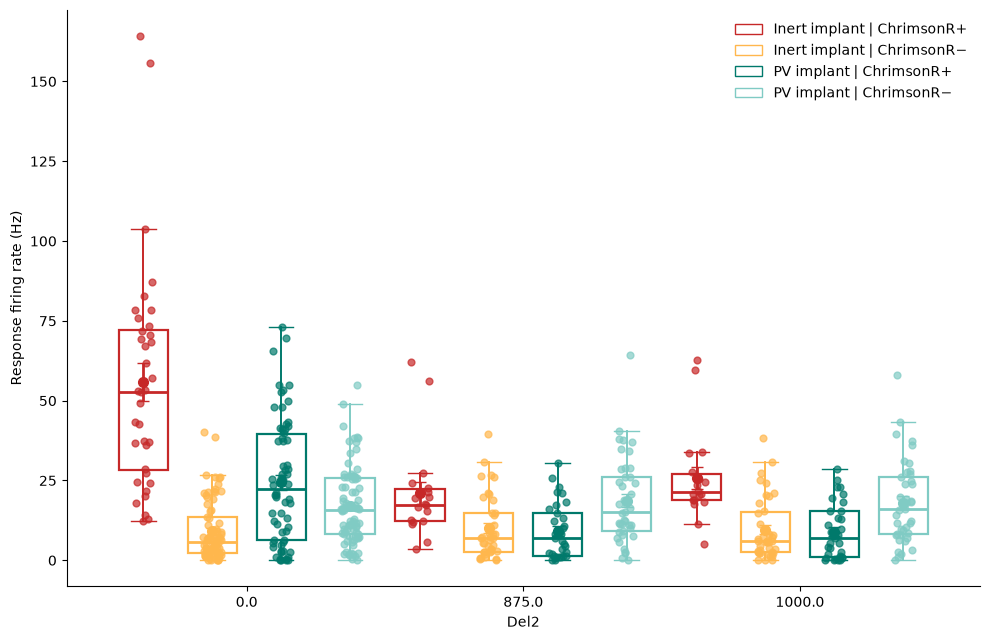


Response firing rate figure
---------------------------
Alignment : onset
Units     : 92
Groups    : 4
Stimuli   : 3


In [138]:
#53
# ==========================================
# Plot response firing rate
# ==========================================

"""
Publication-quality plot of unit response
firing rates.

Each point represents one unit.

Response firing rate is computed from the
response window defined in #49.

All configuration is taken from the
statistics_* namespace.
"""

# ==========================================
# Diagnostics
# ==========================================

print()

print("Comparison labels")

print(
    sorted(
        population_statistics[
            "comparison_label"
        ].unique()
    )
)

# ==========================================
# Plot
# ==========================================

plot_population_statistic(

    data=population_statistics,

    metric="response_rate",

    ylabel="Response firing rate (Hz)",

)

# ==========================================
# Summary
# ==========================================

print()

print("Response firing rate figure")

print("---------------------------")

print(
    f"Alignment : "
    f"{statistics_plot_alignment}"
)

alignment_data = population_statistics.loc[

    population_statistics[
        "alignment"
    ]
    == statistics_plot_alignment

]

print(

    f"Units     : "
    f"{alignment_data['unit_id'].nunique()}"

)

print(

    f"Groups    : "
    f"{alignment_data['comparison_label'].nunique()}"

)

print(

    f"Stimuli   : "
    f"{alignment_data['group_value'].nunique()}"

)

In [139]:
print(sorted(population_statistics["comparison_label"].unique()))

['Inert implant | ChrimsonR+', 'Inert implant | ChrimsonR−', 'PV implant | ChrimsonR+', 'PV implant | ChrimsonR−']


#### 54 Baseline versus response firing rate


Rows before filtering: 1048
After alignment filter: 524
After stimulus filter: 524
After comparison filter: 524

Remaining rows:


,alignment,comparison_key,comparison_label,group_value,unit_id
0,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,0.0,uid_20260603_000
2,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,875.0,uid_20260603_000
4,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,1000.0,uid_20260603_000
6,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,0.0,uid_20260603_000
8,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,0.0,uid_20260603_001
10,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,875.0,uid_20260603_001
12,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,1000.0,uid_20260603_001
14,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,0.0,uid_20260603_001
16,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,0.0,uid_20260603_002
18,onset,"(nonfunctional, True)",Inert implant | ChrimsonR+,875.0,uid_20260603_002



DEBUG: #54 filtering
---------------------
population_statistics shape: (1048, 29)

Configured alignment: onset
Available alignments:
alignment
onset     524
offset    524
Name: count, dtype: int64

Configured group values: None
Available group values:
[0.0, 875.0, 1000.0]

Available comparison labels:
        comparison_key           comparison_label
 (nonfunctional, True) Inert implant | ChrimsonR+
   (functional, False)    PV implant | ChrimsonR−
(nonfunctional, False) Inert implant | ChrimsonR−
    (functional, True)    PV implant | ChrimsonR+

Configured comparison keys:
[('functional', True), ('functional', False), ('nonfunctional', True), ('nonfunctional', False)]

Baseline vs peak comparison
---------------------------
Alignment : onset
Units     : 92
Groups    : 4
Stimuli   : [np.float64(0.0), np.float64(875.0), np.float64(1000.0)]

Values used for plotting
------------------------


,unit_id,comparison_label,group_value,baseline_rate,peak_rate,response_amplitude,peak_latency,detected_response_polarity,has_excitation,has_inhibition
0,uid_20260603_000,Inert implant | ChrimsonR+,0.0,17.333333,343.333333,326.000000,30.0,absolute,True,True
6,uid_20260603_000,Inert implant | ChrimsonR+,0.0,14.333333,355.000000,340.666667,30.0,absolute,True,True
8,uid_20260603_001,Inert implant | ChrimsonR+,0.0,61.000000,111.666667,50.666667,110.0,absolute,True,True
14,uid_20260603_001,Inert implant | ChrimsonR+,0.0,58.333333,103.333333,45.000000,70.0,absolute,True,True
16,uid_20260603_002,Inert implant | ChrimsonR+,0.0,22.666667,160.000000,137.333333,50.0,absolute,True,True
...,...,...,...,...,...,...,...,...,...,...
438,uid_20260604_036,PV implant | ChrimsonR−,1000.0,45.333333,56.666667,11.333333,110.0,absolute,False,False
446,uid_20260604_037,PV implant | ChrimsonR−,1000.0,35.666667,43.333333,7.666667,90.0,absolute,False,False
454,uid_20260604_038,PV implant | ChrimsonR−,1000.0,3.333333,0.000000,-3.333333,10.0,inhibition,False,True
462,uid_20260604_039,PV implant | ChrimsonR−,1000.0,3.666667,6.666667,3.000000,170.0,absolute,False,False



         unit_id           comparison_label  group_value  baseline_rate  peak_rate  response_amplitude  peak_latency detected_response_polarity  has_excitation  has_inhibition
uid_20260603_000 Inert implant | ChrimsonR+         0.00          17.33     343.33              326.00         30.00                   absolute            True            True
uid_20260603_000 Inert implant | ChrimsonR+         0.00          14.33     355.00              340.67         30.00                   absolute            True            True
uid_20260603_001 Inert implant | ChrimsonR+         0.00          61.00     111.67               50.67        110.00                   absolute            True            True
uid_20260603_001 Inert implant | ChrimsonR+         0.00          58.33     103.33               45.00         70.00                   absolute            True            True
uid_20260603_002 Inert implant | ChrimsonR+         0.00          22.67     160.00              137.33         50.00   

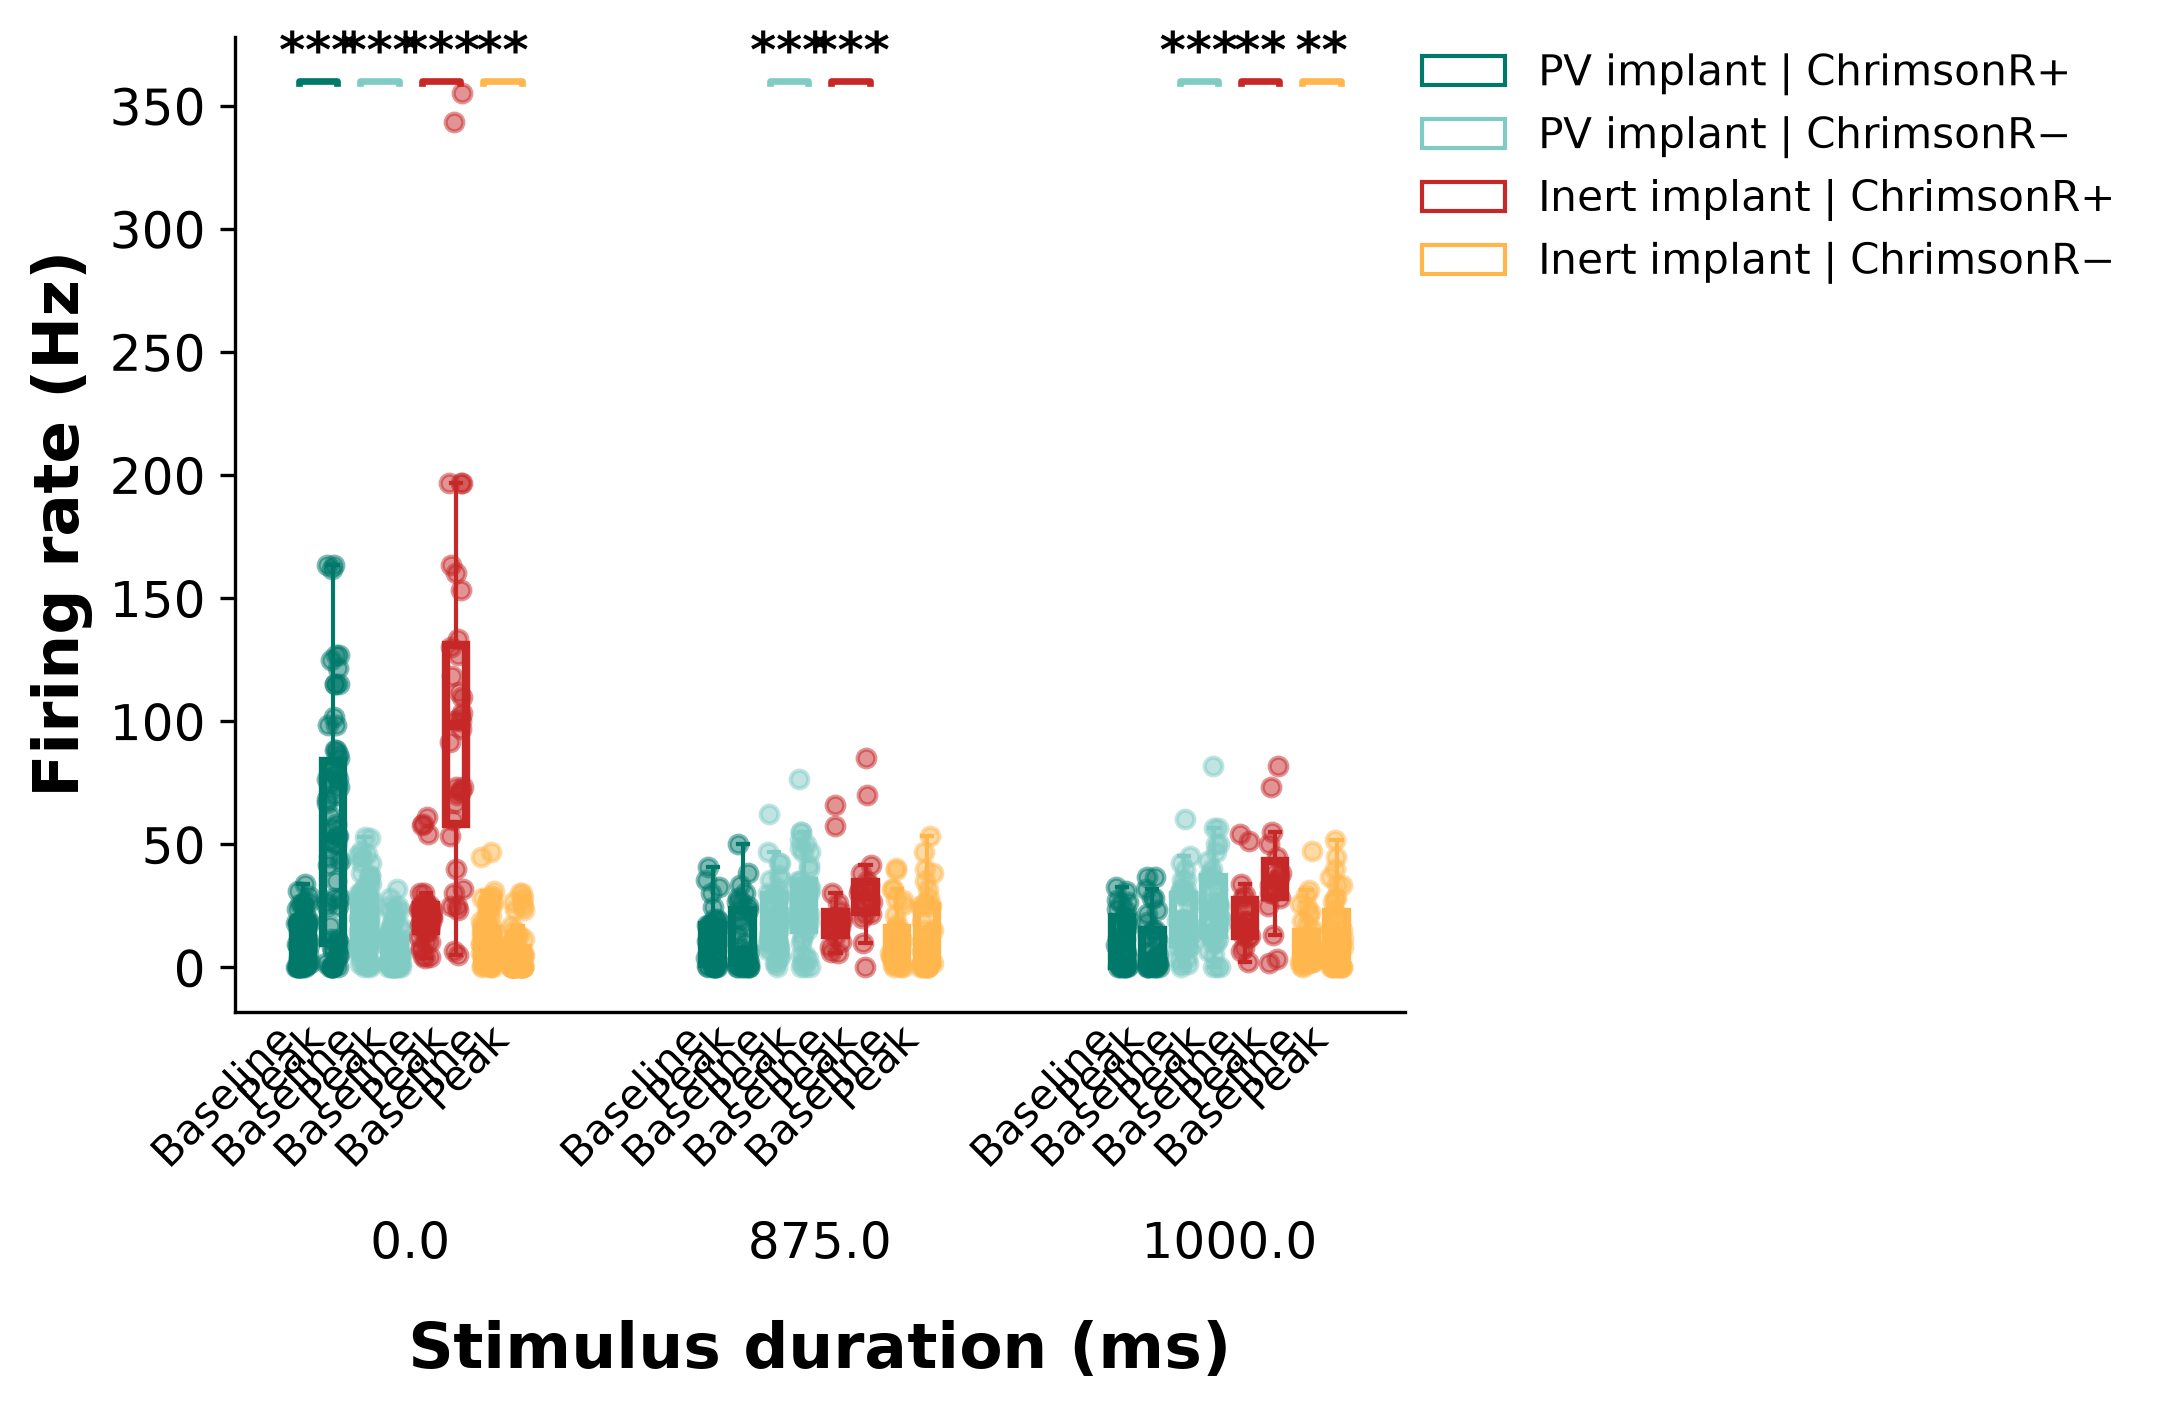

In [140]:
#54
# ==========================================
# Baseline vs peak firing rate
# ==========================================

"""
Compare baseline and peak firing rates.

This cell is driven entirely by the
statistics_* configuration defined in #49.

Each point represents one unit.

The current comparison is:

    baseline_rate
        versus
    peak_rate

If the intended comparison is baseline versus
mean response firing rate, replace peak_rate
with response_rate throughout this cell.
"""

import matplotlib.patches as mpatches
from scipy.stats import wilcoxon

# ==========================================
# Figure settings
# ==========================================

statistics_plot_size = (5, 5)

# Figure size in inches:
#
# (5, 4)   → approximately 12.7 × 10.2 cm
# (7, 4)   → approximately 17.8 × 10.2 cm
# (10, 6)  → approximately 25.4 × 15.2 cm

# ==========================================
# Select data
# ==========================================

plot_df = population_statistics.copy()

plot_df = plot_df.loc[

    plot_df["alignment"]
    == statistics_plot_alignment

].copy()

# ------------------------------------------
# Optional stimulus selection
# ------------------------------------------

if (
    statistics_selected_group_values
    is not None
):

    plot_df = plot_df.loc[

        plot_df["group_value"].isin(

            statistics_selected_group_values

        )

    ]

# ------------------------------------------
# Optional comparison selection
# ------------------------------------------

if (
    statistics_selected_comparison_keys
    is not None
):

    plot_df = plot_df.loc[

        plot_df[
            "comparison_key"
        ].isin(

            statistics_selected_comparison_keys

        )

    ]

# ==========================================
# Apply filters one at a time
# ==========================================

debug_df = population_statistics.copy()

print()

print(
    "Rows before filtering:",
    len(debug_df)
)

# ------------------------------------------
# Alignment
# ------------------------------------------

debug_df = debug_df.loc[

    debug_df[
        "alignment"
    ]
    == statistics_plot_alignment

]

print(
    "After alignment filter:",
    len(debug_df)
)

# ------------------------------------------
# Stimulus
# ------------------------------------------

if (
    statistics_selected_group_values
    is not None
):

    debug_df = debug_df.loc[

        debug_df[
            "group_value"
        ].isin(

            statistics_selected_group_values

        )

    ]

print(
    "After stimulus filter:",
    len(debug_df)
)

# ------------------------------------------
# Comparison
# ------------------------------------------

if (
    statistics_selected_comparison_keys
    is not None
):

    debug_df = debug_df.loc[

        debug_df[
            "comparison_key"
        ].isin(

            statistics_selected_comparison_keys

        )

    ]

print(
    "After comparison filter:",
    len(debug_df)
)

print()

if not debug_df.empty:

    print(
        "Remaining rows:"
    )

    display(

        debug_df[
            [
                "alignment",
                "comparison_key",
                "comparison_label",
                "group_value",
                "unit_id",
            ]
        ]
        .head(20)

    )

else:

    print(
        "No rows remain after the filters."
    )

# ==========================================
# Diagnostic
# ==========================================

print()
print("DEBUG: #54 filtering")
print("---------------------")

print(
    "population_statistics shape:",
    population_statistics.shape
)

print()
print(
    "Configured alignment:",
    statistics_plot_alignment
)

print(
    "Available alignments:"
)

print(
    population_statistics[
        "alignment"
    ].value_counts()
)

print()
print(
    "Configured group values:",
    statistics_selected_group_values
)

print(
    "Available group values:"
)

print(
    sorted(
        population_statistics[
            "group_value"
        ]
        .dropna()
        .unique()
        .tolist()
    )
)

print()
print(
    "Available comparison labels:"
)

print(
    population_statistics[
        [
            "comparison_key",
            "comparison_label",
        ]
    ]
    .drop_duplicates()
    .to_string(index=False)
)

print()
print(
    "Configured comparison keys:"
)

print(
    statistics_selected_comparison_keys
)

# ==========================================
# Validate data
# ==========================================

if plot_df.empty:

    raise RuntimeError(

        "No population statistics remain "
        "after applying the #49 selection."

    )

# ==========================================
# Summary
# ==========================================

print()

print(
    "Baseline vs peak comparison"
)

print(
    "---------------------------"
)

print(

    f"Alignment : "
    f"{statistics_plot_alignment}"

)

print(

    f"Units     : "
    f"{plot_df['unit_id'].nunique()}"

)

print(

    f"Groups    : "
    f"{plot_df['comparison_label'].nunique()}"

)

print(

    f"Stimuli   : "
    f"{sorted(plot_df['group_value'].unique())}"

)

# ==========================================
# Diagnostic
# ==========================================

print()

print(
    "Values used for plotting"
)

print(
    "------------------------"
)

diagnostic_columns = [

    "unit_id",

    "comparison_label",

    "group_value",

    "baseline_rate",

    "peak_rate",

    "response_amplitude",

    "peak_latency",

    "detected_response_polarity",

    "has_excitation",

    "has_inhibition",

]

# ------------------------------------------
# Only display columns that are actually
# available in population_statistics
# ------------------------------------------

available_diagnostic_columns = [

    column

    for column in diagnostic_columns

    if column in plot_df.columns

]

diagnostic_df = (

    plot_df[
        available_diagnostic_columns
    ]

    .sort_values(

        [

            column

            for column in [

                "comparison_label",

                "group_value",

                "unit_id",

            ]

            if column in plot_df.columns

        ]

    )

)

display(
    diagnostic_df
)

print()

print(

    diagnostic_df.to_string(

        index=False,

        float_format=lambda x:
        f"{x:8.2f}",

    )

)

# ==========================================
# Comparison order
# ==========================================

if (
    statistics_selected_comparison_keys
    is None
):

    comparison_order = sorted(

        plot_df[
            "comparison_key"
        ].unique(),

        key=lambda x:

        get_comparison_label(

            x,

            statistics_comparison_groups,

            statistics_comparison_styles,

        ),

    )

else:

    comparison_order = (

        statistics_selected_comparison_keys

    )

# ==========================================
# Stimulus order
# ==========================================

if (
    statistics_selected_group_values
    is None
):

    stimulus_order = sorted(

        plot_df[
            "group_value"
        ].unique()

    )

else:

    stimulus_order = (

        statistics_selected_group_values

    )

# ==========================================
# Paired statistical tests
# ==========================================

paired_statistics = {}

for duration in stimulus_order:

    for comparison_key in comparison_order:

        subset = plot_df.loc[

            (
                plot_df[
                    "group_value"
                ]
                == duration
            )

            &

            (
                plot_df[
                    "comparison_key"
                ]
                == comparison_key
            ),

            [

                "unit_id",

                "baseline_rate",

                "peak_rate",

            ],

        ].dropna()

        if len(subset) < 2:

            continue

        result = wilcoxon(

            subset[
                "baseline_rate"
            ],

            subset[
                "peak_rate"
            ],

            alternative="two-sided",

        )

        paired_statistics[

            (
                duration,

                comparison_key,

            )

        ] = result

        result = wilcoxon(

            subset[
                "baseline_rate"
            ],

            subset[
                "peak_rate"
            ],

            alternative="two-sided",

        )

        paired_statistics[

            (
                duration,

                comparison_key,

            )

        ] = result

# ==========================================
# Print statistical results
# ==========================================

print()

print(
    "Paired Wilcoxon tests"
)

print(
    "---------------------"
)

for (

    key,

    result,

) in paired_statistics.items():

    duration, comparison_key = key

    label = get_comparison_label(

        comparison_key,

        statistics_comparison_groups,

        statistics_comparison_styles,

    )

    print(

        f"{duration:>6} ms | "

        f"{label:<30} "

        f"p = {result.pvalue:.4g}"

    )

# ==========================================
# Convert to long format
# ==========================================

plot_df = plot_df.melt(

    id_vars=[

        "comparison_key",

        "comparison_label",

        "group_value",

        "unit_id",

    ],

    value_vars=[

        "baseline_rate",

        "peak_rate",

    ],

    var_name="epoch",

    value_name="rate",

)

# ==========================================
# Figure limits
# ==========================================

global_ymax = plot_df[
    "rate"
].max()

significance_y = (
    global_ymax + 5
)

# ==========================================
# Figure
# ==========================================

fig, ax = plt.subplots(

    figsize=statistics_plot_size,

    dpi=300,

)

statistics_duration_spacing = 3.0

statistics_group_spacing = 0.45

statistics_epoch_spacing = 0.22

statistics_box_width = 0.15

legend_handles = []

xticks = []

xticklabels = []

minor_xticks = []

minor_xticklabels = []

# ==========================================
# Unit counts for each plotted distribution
# ==========================================

print()

print(
    "Number of units plotted"
)

print(
    "-----------------------"
)

# ==========================================
# Plot baseline and peak firing rates
# ==========================================

for (

    duration_index,

    duration,

) in enumerate(

    stimulus_order

):

    duration_origin = (

        duration_index
        * statistics_duration_spacing

    )

    duration_width = (

        statistics_group_spacing
        * (len(comparison_order) - 1)

    )

    duration_centre = (

        duration_origin
        + duration_width / 2

    )

    xticks.append(
        duration_centre
    )

    xticklabels.append(
        str(duration)
    )

    for (

        group_index,

        comparison_key,

    ) in enumerate(

        comparison_order

    ):

        colour = get_comparison_colour(

            comparison_key,

            statistics_comparison_groups,

            statistics_comparison_styles,

        )

        for (

            epoch_index,

            epoch,

        ) in enumerate(

            [

                "baseline_rate",

                "peak_rate",

            ]

        ):

            epoch_offset = (

                epoch_index - 0.5

            ) * statistics_epoch_spacing

            x = (

                duration_origin

                + group_index
                * statistics_group_spacing

                + epoch_offset

            )

            if (
                epoch
                == "baseline_rate"
            ):

                baseline_x = x

            else:

                peak_x = x

            minor_xticks.append(x)

            minor_xticklabels.append(

                "Baseline"

                if epoch
                == "baseline_rate"

                else "Peak"

            )

            subset = plot_df.loc[

                (
                    plot_df[
                        "group_value"
                    ]
                    == duration
                )

                &

                (
                    plot_df[
                        "comparison_key"
                    ]
                    == comparison_key
                )

                &

                (
                    plot_df[
                        "epoch"
                    ]
                    == epoch
                ),

                "rate",

            ].dropna()

            # ------------------------------------------
            # Print number of plotted units
            # ------------------------------------------

            comparison_label = get_comparison_label(

                comparison_key,

                statistics_comparison_groups,

                statistics_comparison_styles,

            )

            print(

                f"{comparison_label:<30} | "

                f"{duration:>6} | "

                f"{epoch:<14} | "

                f"n = {len(subset):>3}"

            )

            if subset.empty:

                continue

            # ------------------------------
            # Boxplot
            # ------------------------------

            ax.boxplot(

                subset,

                positions=[x],

                widths=(
                    statistics_box_width
                ),

                showfliers=False,

                patch_artist=True,

                boxprops=dict(

                    facecolor="none",

                    edgecolor=colour,

                    linewidth=2,

                ),

                whiskerprops=dict(

                    color=colour,

                ),

                capprops=dict(

                    color=colour,

                ),

                medianprops=dict(

                    color=colour,

                    linewidth=2.5,

                ),

            )

            # ------------------------------
            # Individual units
            # ------------------------------

            jitter = np.random.uniform(

                -0.05,

                0.05,

                len(subset),

            )

            ax.scatter(

                np.full(

                    len(subset),

                    x,

                )

                + jitter,

                subset,

                s=18,

                color=colour,

                alpha=0.5,

            )

        # ----------------------------------
        # Statistical annotation
        # ----------------------------------

        if (

            statistics_show_pairwise_statistics

            and

            len(
                comparison_order
            ) > 0

        ):

            result = paired_statistics.get(

                (
                    duration,

                    comparison_key,

                ),

                None,

            )

            if result is not None:

                p = result.pvalue

                if p < 0.001:

                    stars = "***"

                elif p < 0.01:

                    stars = "**"

                elif p < 0.05:

                    stars = "*"

                else:

                    stars = None

                if stars is not None:

                    y = significance_y

                    bar_padding = 0.03

                    ax.plot(

                        [

                            baseline_x
                            - bar_padding,

                            baseline_x
                            - bar_padding,

                            peak_x
                            + bar_padding,

                            peak_x
                            + bar_padding,

                        ],

                        [

                            y - 0.8,

                            y,

                            y,

                            y - 0.8,

                        ],

                        color=colour,

                        linewidth=1.6,

                    )

                    ax.text(

                        (
                            baseline_x
                            + peak_x
                        ) / 2,

                        y + 0.6,

                        stars,

                        ha="center",

                        va="bottom",

                        fontsize=12,

                        fontweight="bold",

                    )

        # ----------------------------------
        # Legend
        # ----------------------------------

        if duration_index == 0:

            legend_handles.append(

                mpatches.Patch(

                    facecolor="none",

                    edgecolor=colour,

                    label=get_comparison_label(

                        comparison_key,

                        statistics_comparison_groups,

                        statistics_comparison_styles,

                    ),

                )

            )

# ==========================================
# Format figure
# ==========================================

ax.set_xticks(
    xticks
)

ax.set_xticklabels(

    xticklabels,

    fontsize=13,

)

ax.set_xticks(

    minor_xticks,

    minor=True,

)

ax.set_xticklabels(

    minor_xticklabels,

    minor=True,

    rotation=45,

    ha="right",

    fontsize=10,

)

ax.tick_params(

    axis="x",

    which="major",

    pad=50,

    length=0,

)

ax.tick_params(

    axis="x",

    which="minor",

    pad=2,

    length=0,

)

ax.set_xlabel(

    "Stimulus duration (ms)",

    fontsize=15,

    fontweight="bold",

    labelpad=12,

)

ax.set_ylabel(

    "Firing rate (Hz)",

    fontsize=15,

    fontweight="bold",

)

ax.tick_params(

    axis="both",

    labelsize=12,

)

ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)

ax.legend(

    handles=legend_handles,

    loc="upper left",

    bbox_to_anchor=(
        1.00,
        1.00
    ),

    borderaxespad=0,

    frameon=False,

    fontsize=10,

)

plt.subplots_adjust(

    bottom=0.30,

    left=0.10,

    right=0.88,

    top=0.95,

)

plt.show()

### Hybrid Stimulation Analysis

<details>
<summary><strong>Hybrid analysis configuration reference — click to expand</strong></summary>

# ==========================================
# Hybrid analysis configuration reference
# ==========================================

## Purpose

This cell documents the configuration options in **#55**.

The analysis is divided into four conceptual levels:

1. **Recording selection**
   - Defines which recordings constitute each hybrid condition.

2. **Response-unit selection**
   - Defines which biological units are included in the analysis.

3. **Population/statistical analysis**
   - Defines alignment, baseline, response windows and the statistic to calculate.

4. **Plotting**
   - Defines which experimental comparisons are displayed and how the resulting data are visualised.

The main configuration principle is:

> **#55 defines what is analysed; #56–#58 calculate and organise the results; #59 determines how they are visualised; #60 displays the selected result.**

---

## 1. Recording conditions

### `hybrid_recording_filters`

A table in which **each row defines one stimulation condition** to be compared.

Each condition is identified by:

| Variable | Description |
|---|---|
| `hybrid_condition` | Human-readable name used throughout the hybrid analysis and plots. |
| `protocol` | Experimental protocol used to select recordings, e.g. `"dur"`. |
| `stim_mode` | Stimulation mode. `"P"` = Polychrome, `"L"` = Laser, `"B"` = both. |
| `laser_mode` | Laser mode. `"N"` = no laser, `"LC"` = continuous laser. |
| `view` | Signal/view used for spike extraction, e.g. `"Polychrome"` or `"Laser"`. |
| `group_value` | Stimulus intensity/duration/value used to select the relevant trials. |
| `event` | **Not defined per recording condition.** Event alignment is controlled globally by `event` below. |

### Example

```python
{
    "hybrid_condition": "P",
    "protocol": "dur",
    "stim_mode": "P",
    "laser_mode": "N",
    "view": "Polychrome",
    "group_value": 50,
}

# Hybrid population statistics

The hybrid analysis provides several statistics describing different aspects of the neuronal response. The statistics are calculated from the trial-averaged unit PSTH generated in #56. The PSTH expresses firing rate in Hz for each time bin.

## Baseline rate

`baseline_rate` is the mean firing rate during the configured baseline window. With the current settings, the baseline window is −200 to −100 ms relative to the selected alignment event.

[
R_\mathrm{baseline} = \mathrm{mean}(R(t))
]

This represents the neuron's baseline firing activity before the response.

## Response rate

`response_rate` is the mean firing rate during the configured response window. With the current settings, this is 10–200 ms after the alignment event.

[
R_\mathrm{response} = \mathrm{mean}(R(t))
]

It describes the average firing activity throughout the response period and is less dependent on a brief maximum than `peak_rate`.

## Peak rate

`peak_rate` is the maximum firing rate of the trial-averaged PSTH within the configured peak-search window. With the current settings, the search window is 10–200 ms.

[
R_\mathrm{peak} =
\max_{t \in [10,200]} R(t)
]

Importantly, `peak_rate` is not an instantaneous firing rate at a single timepoint. It is the firing rate calculated within the PSTH bin containing the maximum value. Therefore, if the PSTH bin width is 20 ms, the reported peak rate represents the highest firing rate observed across a 20-ms bin. The peak-search window determines where the bins are searched, whereas the PSTH bin width determines the temporal duration represented by the peak.

With the current `hybrid_response_polarity = "automatic"` implementation, the peak is selected using `np.argmax()`. Thus, `automatic` currently selects the highest firing-rate bin and does not independently determine whether the response is excitatory or inhibitory.

## Peak latency

`peak_latency` is the centre time of the PSTH bin in which `peak_rate` occurs.

It therefore indicates when the maximum firing-rate response occurs relative to the selected onset or offset alignment.

## Response amplitude

`response_amplitude` is the difference between the peak rate and the baseline rate:

[
A_\mathrm{response}
===================

R_\mathrm{peak} - R_\mathrm{baseline}
]

It therefore describes the change in firing rate above or below baseline associated with the peak response.

## AUC

`auc` is the area under the firing-rate curve during the response window:

[
AUC =
\int R(t),dt
]

In the current implementation, the integral is calculated numerically using the trapezoidal rule. It reflects the total firing activity across the response period and therefore incorporates both response magnitude and duration.

## Baseline-corrected AUC

`baseline_corrected_auc` calculates the area under the baseline-subtracted response:

[
AUC_\mathrm{corrected}
======================

\int
\left[
R(t)-R_\mathrm{baseline}
\right]dt
]

This provides an integrated measure of evoked activity relative to the neuron's baseline firing rate.

## Modulation index

`modulation_index` is calculated as:

[
MI =
\frac{
R_\mathrm{peak}-R_\mathrm{baseline}
}{
R_\mathrm{peak}+R_\mathrm{baseline}
}
]

It is a dimensionless measure that normalises the difference between peak and baseline firing relative to their sum.

## Peak z-score

`peak_zscore` expresses the difference between peak and baseline firing in units of the baseline standard deviation:

[
Z_\mathrm{peak}
===============

\frac{
R_\mathrm{peak}-R_\mathrm{baseline}
}{
SD_\mathrm{baseline}
}
]

It therefore indicates how large the peak response is relative to the variability of the baseline firing rate.

## Peak rate versus response amplitude

The distinction between `peak_rate` and `response_amplitude` is important. `peak_rate` describes the absolute maximum firing rate reached by the neuron, whereas `response_amplitude` describes the change from baseline to that peak.

For example, if baseline firing is 5 Hz and the peak firing rate is 25 Hz:

[
R_\mathrm{peak}=25\ \mathrm{Hz}
]

whereas:

[
A_\mathrm{response}=25-5=20\ \mathrm{Hz}
]

Thus, `peak_rate` is an absolute firing-rate measure, while `response_amplitude` is a baseline-referenced response measure.

## Temporal interpretation of peak rate

The temporal duration represented by `peak_rate` is determined by the PSTH `bin_width`, not by the `peak_search_window`. For example, with a 20-ms bin width and a 10–200-ms peak-search window, the analysis searches the available 20-ms PSTH bins within that window and reports the highest bin value. The `peak_search_window` therefore defines the temporal region in which the peak may occur, whereas `bin_width` defines the duration of the firing-rate estimate itself.


</details>

#### Diagnostic for group_values (55A)

In [141]:
# ==========================================
# Diagnostic: available POW group values
# ==========================================

pow_group_values = (

    population_summary.loc[

        population_summary["protocol"] == "pow",

        "group_value"

    ]

    .dropna()

    .value_counts()

    .sort_index()

)


print()
print("=" * 70)
print("AVAILABLE GROUP VALUES — PROTOCOL: POW")
print("=" * 70)
print()

if pow_group_values.empty:

    print(
        'No group_value entries found for '
        'protocol = "pow".'
    )

else:

    display(

        pow_group_values

        .rename("n_rows")

        .rename_axis("group_value")

        .reset_index()

    )


AVAILABLE GROUP VALUES — PROTOCOL: POW



,group_value,n_rows
0,10.0,524
1,12.0,524
2,20.0,524
3,25.0,524
4,30.0,524
5,50.0,524
6,88.0,524
7,100.0,524


#### Configuration (55)

In [171]:
#55
# ==========================================
# Hybrid population statistics configuration
# ==========================================

"""
Configure hybrid comparisons between recording
conditions.

Analysis settings are defined here and are used
by #56-#60.

The same session_id + unit_id combination is
treated as the same biological unit across
recordings and can therefore be paired.
"""

import pandas as pd


# ==========================================
# Recording filters
# ==========================================

hybrid_recording_filters = pd.DataFrame(

    [

        {
            "hybrid_condition":
                "595 nm",

            "protocol":
                "dur",

            "stim_mode":
                "P",

            "laser_mode":
                "N",

            "view":
                "Polychrome",

            "group_value":
                50,
        },

        {
            "hybrid_condition":
                "595 + cont. 880 nm",

            "protocol":
                "dur",

            "stim_mode":
                "B",

            "laser_mode":
                "LC",

            "view":
                "Polychrome",

            "group_value":
                50,
        },

    ]

)


# ==========================================
# Common analysis settings
# ==========================================

hybrid_baseline_mode = "onset_baseline"

# "onset_baseline"
# "pre_offset"

hybrid_event = "onset"

# "onset"
# "offset"
# "both"

hybrid_include_units = "all"

# "all"
# "responding"
# "unit_responding"
# "hybrid_responding"


# ==========================================
# Hybrid responding criteria
# ==========================================

hybrid_responding_polychrome = {

    "protocol": "dur",

    "stim_mode": "P",

    "laser_mode": "N",

    "view": "Polychrome",

    "group_value": 50,

    "baseline_mode": "onset_baseline",

    "event": "onset",

}


hybrid_responding_laser = {

    "protocol": "dur",

    "stim_mode": "L",

    "laser_mode": "N",

    "view": "Laser",

    "group_value": 5000,

    "baseline_mode": "pre_offset",

    "event": "offset",

}


# ==========================================
# Experimental grouping
# ==========================================

hybrid_comparison_groups = [

    "implant",
    "chrimsonr",

]


hybrid_comparison_styles = build_comparison_styles(

    hybrid_comparison_groups,

)


# ==========================================
# Comparison selection
# ==========================================

hybrid_selected_comparison_keys = [

    ("functional", True),
    ("functional", False),

    ("nonfunctional", True),
    ("nonfunctional", False),

]

# None = include all available comparisons.


# ==========================================
# Stimulus selection
# ==========================================

hybrid_stimulus_group = "group_value"

hybrid_selected_group_values = None

# None = include all stimulus values.
#
# This is appropriate when the individual
# hybrid conditions are already explicitly
# defined by hybrid_recording_filters.


# ==========================================
# Analysis windows
# ==========================================

hybrid_baseline_window = (
    -200,
    -100,
)

hybrid_response_window = (
    10,
    200,
)

hybrid_peak_search_window = (
    10,
    200,
)

# ==========================================
# PSTH binning (Don't change unless strictly necessary)
# ==========================================

hybrid_bin_width = 20

hybrid_bin_step = 5

hybrid_analysis_window = (
    -1000,
    7000,
)

# ==========================================
# Response detection
# ==========================================

hybrid_response_polarity = "automatic"

hybrid_latency_threshold = 3

hybrid_latency_consecutive_bins = 3


# ==========================================
# Statistic
# ==========================================

hybrid_statistic = "peak_rate"


# ==========================================
# Plot settings
# ==========================================

hybrid_plot_comparison = None

# None
#     Plot every selected comparison as a
#     separate figure.
#
# Example:
#
# "PV implant | ChrimsonR+"
#     Plot only this comparison.

hybrid_plot_combined = True

# True
#     Generate the combined multi-panel figure.
#
# False
#     Do not generate the combined figure.

hybrid_plot_size = (6, 5)

# Show the stimulus duration/power in plot titles.
# True  = include stimulus value
# False = omit stimulus value

hybrid_plot_show_stimulus = False

hybrid_show_points = True

hybrid_show_mean = True

hybrid_show_statistics = True

hybrid_show_pairwise_statistics = True


# ==========================================
# Configuration summary
# ==========================================

print()

print(
    "Hybrid population statistics configuration"
)

print(
    "------------------------------------------"
)

print()

print(
    "Recording conditions:"
)

display(
    hybrid_recording_filters
)

print()

print(
    f"Number of recording conditions : "
    f"{len(hybrid_recording_filters)}"
)

print(
    f"Baseline mode                  : "
    f"{hybrid_baseline_mode}"
)

print(
    f"Event                         : "
    f"{hybrid_event}"
)

print(
    f"Unit inclusion                : "
    f"{hybrid_include_units}"
)

print(
    f"Comparison groups             : "
    f"{hybrid_comparison_groups}"
)

print(
    f"Selected comparison keys      : "
    f"{hybrid_selected_comparison_keys}"
)

print(
    f"Selected stimulus values      : "
    f"{hybrid_selected_group_values}"
)

print(
    f"Statistic                     : "
    f"{hybrid_statistic}"
)


Hybrid population statistics configuration
------------------------------------------

Recording conditions:


,hybrid_condition,protocol,stim_mode,laser_mode,view,group_value
0,595 nm,dur,P,N,Polychrome,50
1,595 + cont. 880 nm,dur,B,LC,Polychrome,50



Number of recording conditions : 2
Baseline mode                  : onset_baseline
Event                         : onset
Unit inclusion                : all
Comparison groups             : ['implant', 'chrimsonr']
Selected comparison keys      : [('functional', True), ('functional', False), ('nonfunctional', True), ('nonfunctional', False)]
Selected stimulus values      : None
Statistic                     : peak_rate


#### Compute hybrid unit PSTHs (56)

In [172]:
# ==========================================
# #56 — Compute hybrid unit PSTHs
# ==========================================

"""
Construct unit-level PSTHs independently for the
hybrid stimulation analysis.

This cell does NOT depend on:

    #42
    #43
    #44
    #46
    psth_df
    unit_psth
    binned_spikes

Instead, it uses:

    all_data_io
    prepare_recording_analysis()
    extract_spikes()

Recording conditions are defined exclusively by:

    hybrid_recording_filters

from #55.

PSTH temporal parameters are defined in #55:

    hybrid_bin_width
    hybrid_bin_step
    hybrid_analysis_window

The output structure is identical to the previous
#56 implementation.

The main computational optimisations are:

    1. extract_spikes() is called once per recording
       rather than once per unit.

    2. burst_df is indexed by train_id once per
       recording.

    3. Spike counting uses np.histogram() rather
       than looping over every PSTH bin.

    4. Recording matching is performed once before
       processing units.
"""

import numpy as np
import pandas as pd


# ==========================================
# Validate recording filters
# ==========================================

required_filter_columns = [

    "hybrid_condition",
    "protocol",
    "stim_mode",
    "laser_mode",
    "view",
    "group_value",

]

missing_columns = [

    column

    for column in required_filter_columns

    if column not in hybrid_recording_filters.columns

]

if missing_columns:

    raise ValueError(

        "hybrid_recording_filters is missing "
        "the following required columns:\n\n"

        + "\n".join(

            f"    {column}"

            for column in missing_columns

        )

    )


# ==========================================
# Validate PSTH binning configuration
# ==========================================

if hybrid_bin_width <= 0:

    raise ValueError(
        "hybrid_bin_width must be greater than zero."
    )

if hybrid_bin_step <= 0:

    raise ValueError(
        "hybrid_bin_step must be greater than zero."
    )

if hybrid_analysis_window[1] <= hybrid_analysis_window[0]:

    raise ValueError(
        "hybrid_analysis_window must have "
        "an increasing start and stop."
    )


# ==========================================
# Construct PSTH bins
# ==========================================

hybrid_bin_starts = np.arange(

    hybrid_analysis_window[0],

    hybrid_analysis_window[1]
    - hybrid_bin_width
    + hybrid_bin_step,

    hybrid_bin_step,

)

hybrid_bin_ends = (
    hybrid_bin_starts
    + hybrid_bin_width
)

hybrid_bin_centres = (

    hybrid_bin_starts
    + hybrid_bin_width / 2

)


# ==========================================
# Helper: parse recording ID
# ==========================================

def parse_hybrid_rec_id(rec_id):

    parts = rec_id.split("_")

    if len(parts) < 4:

        raise ValueError(

            f"Cannot parse recording ID:\n"
            f"    {rec_id}\n\n"
            f"Expected at least four "
            f"underscore-separated fields."

        )

    return {

        "laser_mode":
            parts[1],

        "stim_mode":
            parts[2],

        "protocol":
            parts[3],

    }


# ==========================================
# Helper: bin one spike train
# ==========================================

def bin_hybrid_spiketrain(

    spiketrain,

):

    spiketrain = np.asarray(
        spiketrain
    )

    counts, _ = np.histogram(

        spiketrain,

        bins=np.append(

            hybrid_bin_starts,

            hybrid_bin_ends[-1],

        ),

    )

    return (

        counts.astype(float)

        * 1000

        / hybrid_bin_width

    )


# ==========================================
# Find matching recordings once
# ==========================================

matched_recordings_by_condition = {}


for _, recording_filter in (
    hybrid_recording_filters.iterrows()
):

    hybrid_condition = (
        recording_filter[
            "hybrid_condition"
        ]
    )

    requested_protocol = (
        recording_filter[
            "protocol"
        ]
    )

    requested_stim_mode = (
        recording_filter[
            "stim_mode"
        ]
    )

    requested_laser_mode = (
        recording_filter[
            "laser_mode"
        ]
    )

    matched_recordings = []


    for session_id in sorted(
        all_data_io
    ):

        session_data = (
            all_data_io[
                session_id
            ]
        )

        for rec_id in sorted(
            session_data.spiketimes.keys()
        ):

            rec_metadata = (
                parse_hybrid_rec_id(
                    rec_id
                )
            )

            if (
                rec_metadata["protocol"]
                != requested_protocol
            ):

                continue

            if (
                rec_metadata["stim_mode"]
                != requested_stim_mode
            ):

                continue

            if (
                rec_metadata["laser_mode"]
                != requested_laser_mode
            ):

                continue

            matched_recordings.append(

                (
                    session_id,
                    session_data,
                    rec_id,
                )

            )

    matched_recordings_by_condition[
        hybrid_condition
    ] = {

        "recording_filter":
            recording_filter,

        "matched_recordings":
            matched_recordings,

    }


# ==========================================
# Initialise database
# ==========================================

hybrid_unit_psth = {}


# ==========================================
# Process hybrid conditions
# ==========================================

for hybrid_condition, condition_info in (
    matched_recordings_by_condition.items()
):

    recording_filter = (
        condition_info[
            "recording_filter"
        ]
    )

    matched_recordings = (
        condition_info[
            "matched_recordings"
        ]
    )

    requested_protocol = (
        recording_filter[
            "protocol"
        ]
    )

    requested_stim_mode = (
        recording_filter[
            "stim_mode"
        ]
    )

    requested_laser_mode = (
        recording_filter[
            "laser_mode"
        ]
    )

    requested_view = (
        recording_filter[
            "view"
        ]
    )

    requested_group_value = (
        recording_filter[
            "group_value"
        ]
    )

    requested_event = hybrid_event


    # ======================================
    # Condition summary
    # ======================================

    print()
    print("=" * 70)
    print(
        f"Hybrid condition : "
        f"{hybrid_condition}"
    )
    print("=" * 70)

    print(
        f"Protocol    : {requested_protocol}"
    )

    print(
        f"Stim mode   : {requested_stim_mode}"
    )

    print(
        f"Laser mode  : {requested_laser_mode}"
    )

    print(
        f"View        : {requested_view}"
    )

    print(
        f"Group value : {requested_group_value}"
    )

    print(
        f"Event       : {requested_event}"
    )


    # ======================================
    # Matching recordings
    # ======================================

    print()
    print("Matching recordings:")

    if not matched_recordings:

        print("    None")

        continue

    for (
        session_id,
        session_data,
        rec_id,
    ) in matched_recordings:

        print(
            f"    {session_id} | {rec_id}"
        )


    # ======================================
    # Process recordings
    # ======================================

    for (
        session_id,
        session_data,
        rec_id,
    ) in matched_recordings:

        print()
        print(
            f"Processing "
            f"{session_id} | {rec_id}"
        )


        # ==================================
        # Prepare recording analysis
        # ==================================

        (
            burst_df,
            analysis_views,
            group_label,
        ) = prepare_recording_analysis(

            data_io=session_data,

            rec_id=rec_id,

            protocol=requested_protocol,

            stim_mode=requested_stim_mode,

            pchr_columns=pchr_columns,

            laser_columns=laser_columns,

        )


        # ==================================
        # Select requested analysis view
        # ==================================

        available_views = [

            analysis_view["name"]

            for analysis_view
            in analysis_views

        ]

        if requested_view not in available_views:

            raise ValueError(

                f"\nRequested hybrid view "
                f"{requested_view!r} is not available "
                f"for recording {rec_id!r}.\n\n"

                f"Available views:\n"

                + "\n".join(

                    f"    {name}"

                    for name in available_views

                )

            )


        current_view = next(

            analysis_view

            for analysis_view
            in analysis_views

            if analysis_view["name"] == requested_view

        )


        group_column = current_view[
            "group_column"
        ]


        # ==================================
        # Index train metadata once
        # ==================================

        train_metadata = {

            train_id: train_rows.iloc[0]

            for train_id, train_rows
            in burst_df.groupby(
                "train_id",
                sort=False,
            )

        }


        # ==================================
        # Extract all spikes ONCE
        # ==================================

        recording_spikes = {}

        for unit_id in sorted(
            session_data.spiketimes[
                rec_id
            ].keys()
        ):

            recording_spikes[unit_id] = (
                extract_spikes(

                    session_data,

                    rec_id,

                    unit_id,

                    verbose=False,

                )
            )


        # ==================================
        # Process units
        # ==================================

        for unit_id, all_spiketimes in (
            recording_spikes.items()
        ):

            # ----------------------------------
            # Validate requested view
            # ----------------------------------

            if requested_view not in all_spiketimes:

                raise ValueError(

                    f"\nRequested hybrid view "
                    f"{requested_view!r} is not available "
                    f"in extract_spikes() for:\n\n"

                    f"Session : {session_id}\n"
                    f"Recording : {rec_id}\n"
                    f"Unit : {unit_id}\n\n"

                    f"Available views:\n"

                    + "\n".join(

                        f"    {name}"

                        for name
                        in all_spiketimes.keys()

                    )

                )


            view_spiketimes = all_spiketimes[
                requested_view
            ]


            # ==================================
            # Process stimulation trains
            # ==================================

            for train_id, trial_spikes in (
                view_spiketimes.items()
            ):

                if train_id not in train_metadata:

                    continue

                metadata = train_metadata[
                    train_id
                ]


                # ----------------------------------
                # Group value
                # ----------------------------------

                group_value = metadata[
                    group_column
                ]


                # ----------------------------------
                # Select requested stimulus
                # ----------------------------------

                if not np.isclose(

                    float(group_value),

                    float(requested_group_value),

                ):

                    continue


                # ----------------------------------
                # Stimulus windows
                # ----------------------------------

                (
                    alignment_from_view,
                    stim_windows,
                ) = current_view[
                    "stim_windows"
                ](
                    metadata
                )


                # ==================================
                # Build alignments
                # ==================================

                if requested_event == "onset":

                    alignments = [

                        (
                            "onset",
                            trial_spikes,
                        ),

                    ]

                elif requested_event in (
                    "offset",
                    "both",
                ):

                    offset_times = [

                        stop

                        for (
                            start,
                            stop,
                            label
                        ) in stim_windows

                        if label == requested_view

                    ]

                    if not offset_times:

                        raise ValueError(

                            f"\nCannot determine offset "
                            f"for view {requested_view!r}.\n\n"

                            f"Session : {session_id}\n"
                            f"Recording : {rec_id}\n"
                            f"Unit : {unit_id}\n"
                            f"Train : {train_id}\n\n"

                            f"Stimulus windows:\n"
                            f"{stim_windows}"

                        )


                    offset_time = offset_times[-1]


                    offset_trial_spikes = [

                        np.asarray(
                            spiketrain
                        ) - offset_time

                        for spiketrain
                        in trial_spikes

                    ]


                    alignments = []


                    if requested_event == "both":

                        alignments.append(

                            (
                                "onset",
                                trial_spikes,
                            )

                        )


                    alignments.append(

                        (
                            "offset",
                            offset_trial_spikes,
                        )

                    )


                else:

                    raise ValueError(

                        f"Unknown event: "
                        f"{requested_event!r}"

                    )


                # ==================================
                # Stimulus pattern
                # ==================================

                pattern_key = tuple(

                    (

                        int(
                            round(start)
                        ),

                        int(
                            round(stop)
                        ),

                        label,

                    )

                    for (
                        start,
                        stop,
                        label
                    ) in stim_windows

                )


                # ==================================
                # Calculate PSTHs
                # ==================================

                for (
                    alignment_name,
                    aligned_trial_spikes,
                ) in alignments:

                    if not aligned_trial_spikes:

                        continue


                    trial_rates = np.asarray(

                        [

                            bin_hybrid_spiketrain(
                                spiketrain
                            )

                            for spiketrain
                            in aligned_trial_spikes

                        ],

                        dtype=float,

                    )


                    if trial_rates.size == 0:

                        continue


                    # ----------------------------------
                    # Trial-average PSTH
                    # ----------------------------------

                    hybrid_psth_values = (
                        trial_rates.mean(
                            axis=0
                        )
                    )


                    # ==================================
                    # Store
                    # ==================================

                    key = (

                        hybrid_condition,

                        session_id,

                        rec_id,

                        unit_id,

                        train_id,

                        alignment_name,

                        float(
                            group_value
                        ),

                    )


                    hybrid_unit_psth[key] = {

                        "hybrid_condition":
                            hybrid_condition,

                        "session_id":
                            session_id,

                        "rec_id":
                            rec_id,

                        "unit_id":
                            unit_id,

                        "train_id":
                            train_id,

                        "alignment":
                            alignment_name,

                        "view":
                            requested_view,

                        "protocol":
                            requested_protocol,

                        "stim_mode":
                            requested_stim_mode,

                        "laser_mode":
                            requested_laser_mode,

                        "group_value":
                            group_value,

                        "metadata":
                            metadata,

                        "stim_windows":
                            stim_windows,

                        "pattern_key":
                            pattern_key,

                        "time":
                            hybrid_bin_centres,

                        "bin_width":
                            hybrid_bin_width,

                        "bin_step":
                            hybrid_bin_step,

                        "psth":
                            hybrid_psth_values,

                    }


# ==========================================
# Build diagnostic DataFrame
# ==========================================

hybrid_psth_rows = [

    {

        "hybrid_condition":
            entry["hybrid_condition"],

        "session_id":
            entry["session_id"],

        "rec_id":
            entry["rec_id"],

        "unit_id":
            entry["unit_id"],

        "train_id":
            entry["train_id"],

        "alignment":
            entry["alignment"],

        "group_value":
            entry["group_value"],

        "view":
            entry["view"],

    }

    for entry
    in hybrid_unit_psth.values()

]


if hybrid_psth_rows:

    hybrid_unit_psth_df = pd.DataFrame(
        hybrid_psth_rows
    )

else:

    hybrid_unit_psth_df = pd.DataFrame(
        columns=[

            "hybrid_condition",
            "session_id",
            "rec_id",
            "unit_id",
            "train_id",
            "alignment",
            "group_value",
            "view",

        ]
    )


# ==========================================
# Summary
# ==========================================

print()
print("=" * 70)
print("Hybrid unit PSTHs")
print("=" * 70)

print()
print(
    f"Total PSTH entries : "
    f"{len(hybrid_unit_psth)}"
)

print(
    f"Unique sessions    : "
    f"{hybrid_unit_psth_df['session_id'].nunique()}"
)

print(
    f"Unique recordings  : "
    f"{hybrid_unit_psth_df['rec_id'].nunique()}"
)

print(
    f"Unique units       : "
    f"{hybrid_unit_psth_df['unit_id'].nunique()}"
)


# ==========================================
# Summary by hybrid condition
# ==========================================

if not hybrid_unit_psth_df.empty:

    print()
    print(
        "Entries by hybrid condition:"
    )

    display(

        hybrid_unit_psth_df
        .groupby(
            "hybrid_condition"
        )
        .agg(

            sessions=(
                "session_id",
                "nunique",
            ),

            recordings=(
                "rec_id",
                "nunique",
            ),

            units=(
                "unit_id",
                "nunique",
            ),

            entries=(
                "train_id",
                "count",
            ),

        )

    )


# ==========================================
# Diagnostic table
# ==========================================

if not hybrid_unit_psth_df.empty:

    print()
    print(
        "Hybrid PSTH diagnostic"
    )

    display(

        hybrid_unit_psth_df
        .sort_values(

            [

                "hybrid_condition",
                "session_id",
                "rec_id",
                "unit_id",
                "group_value",
                "alignment",

            ]

        )
        .head(50)

    )

else:

    print()
    print(
        "No hybrid unit PSTHs were generated."
    )


Hybrid condition : 595 nm
Protocol    : dur
Stim mode   : P
Laser mode  : N
View        : Polychrome
Group value : 50
Event       : onset

Matching recordings:
    20260603_eye2_2nd | 05_N_P_dur
    20260604_eye1_2nd | 04_N_P_dur
    20260604_eye2_2nd | 04_N_P_dur
    20260605_eye1_2nd | 04_N_P_dur

Processing 20260603_eye2_2nd | 05_N_P_dur

Processing 20260604_eye1_2nd | 04_N_P_dur

Processing 20260604_eye2_2nd | 04_N_P_dur

Processing 20260605_eye1_2nd | 04_N_P_dur

Hybrid condition : 595 + cont. 880 nm
Protocol    : dur
Stim mode   : B
Laser mode  : LC
View        : Polychrome
Group value : 50
Event       : onset

Matching recordings:
    20260603_eye2_2nd | 07_LC_B_dur
    20260604_eye1_2nd | 06_LC_B_dur
    20260604_eye2_2nd | 06_LC_B_dur
    20260605_eye1_2nd | 06_LC_B_dur

Processing 20260603_eye2_2nd | 07_LC_B_dur

Processing 20260604_eye1_2nd | 06_LC_B_dur

Processing 20260604_eye2_2nd | 06_LC_B_dur

Processing 20260605_eye1_2nd | 06_LC_B_dur

Hybrid unit PSTHs

Total PSTH en

,sessions,recordings,units,entries
hybrid_condition,,,,
595 + cont. 880 nm,4,2,92,131
595 nm,4,2,92,131



Hybrid PSTH diagnostic


,hybrid_condition,session_id,rec_id,unit_id,train_id,alignment,group_value,view
131,595 + cont. 880 nm,20260603_eye2_2nd,07_LC_B_dur,uid_20260603_000,tid_029_07,onset,50.0,Polychrome
132,595 + cont. 880 nm,20260603_eye2_2nd,07_LC_B_dur,uid_20260603_001,tid_029_07,onset,50.0,Polychrome
133,595 + cont. 880 nm,20260603_eye2_2nd,07_LC_B_dur,uid_20260603_002,tid_029_07,onset,50.0,Polychrome
134,595 + cont. 880 nm,20260603_eye2_2nd,07_LC_B_dur,uid_20260603_003,tid_029_07,onset,50.0,Polychrome
135,595 + cont. 880 nm,20260603_eye2_2nd,07_LC_B_dur,uid_20260603_004,tid_029_07,onset,50.0,Polychrome
136,595 + cont. 880 nm,20260603_eye2_2nd,07_LC_B_dur,uid_20260603_005,tid_029_07,onset,50.0,Polychrome
137,595 + cont. 880 nm,20260603_eye2_2nd,07_LC_B_dur,uid_20260603_006,tid_029_07,onset,50.0,Polychrome
138,595 + cont. 880 nm,20260603_eye2_2nd,07_LC_B_dur,uid_20260603_007,tid_029_07,onset,50.0,Polychrome
139,595 + cont. 880 nm,20260603_eye2_2nd,07_LC_B_dur,uid_20260603_008,tid_029_07,onset,50.0,Polychrome
140,595 + cont. 880 nm,20260603_eye2_2nd,07_LC_B_dur,uid_20260603_009,tid_029_07,onset,50.0,Polychrome


#### Diagnostic (57A)

In [173]:
#57A
# ==========================================
# Build hybrid response sets
# ==========================================

"""
Determine which units respond to the two
criteria specified in #55.

Hybrid responding means:

    same session_id
    +
    same unit_id

responds to BOTH the Polychrome criterion
and the Laser criterion.
"""


# ==========================================
# Helper
# ==========================================

def filter_hybrid_response_criterion(
    population_summary,
    criterion,
):

    filtered = population_summary.copy()

    for column, value in criterion.items():

        filtered = filtered.loc[
            filtered[column] == value
        ]

    return filtered


# ==========================================
# Polychrome response criterion
# ==========================================

poly_response = filter_hybrid_response_criterion(

    population_summary,

    hybrid_responding_polychrome,

)


# ==========================================
# Laser response criterion
# ==========================================

laser_response = filter_hybrid_response_criterion(

    population_summary,

    hybrid_responding_laser,

)


# ==========================================
# Polychrome responding units
# ==========================================

poly_responding_units = (

    poly_response.loc[

        poly_response["responding"],

        [
            "session_id",
            "unit_id",
        ],

    ]

    .drop_duplicates()

)


# ==========================================
# Laser responding units
# ==========================================

laser_responding_units = (

    laser_response.loc[

        laser_response["responding"],

        [
            "session_id",
            "unit_id",
        ],

    ]

    .drop_duplicates()

)


# ==========================================
# Hybrid responding units
# ==========================================

hybrid_responding_units = (

    poly_responding_units

    .merge(

        laser_responding_units,

        on=[
            "session_id",
            "unit_id",
        ],

        how="inner",

    )

)


# ==========================================
# Summary
# ==========================================

print()
print("=" * 70)
print("HYBRID RESPONSE CRITERIA")
print("=" * 70)

print()

print("Polychrome criterion:")
print(
    hybrid_responding_polychrome
)

print()

print("Laser criterion:")
print(
    hybrid_responding_laser
)

print()

print(
    "Polychrome response rows :",
    len(poly_response)
)

print(
    "Polychrome responding units :",
    len(poly_responding_units)
)

print()

print(
    "Laser response rows :",
    len(laser_response)
)

print(
    "Laser responding units :",
    len(laser_responding_units)
)

print()

print(
    "Hybrid responding units :",
    len(hybrid_responding_units)
)

print()

display(

    hybrid_responding_units

    .sort_values(
        [
            "session_id",
            "unit_id",
        ]
    )

)


HYBRID RESPONSE CRITERIA

Polychrome criterion:
{'protocol': 'dur', 'stim_mode': 'P', 'laser_mode': 'N', 'view': 'Polychrome', 'group_value': 50, 'baseline_mode': 'onset_baseline', 'event': 'onset'}

Laser criterion:
{'protocol': 'dur', 'stim_mode': 'L', 'laser_mode': 'N', 'view': 'Laser', 'group_value': 5000, 'baseline_mode': 'pre_offset', 'event': 'offset'}

Polychrome response rows : 131
Polychrome responding units : 52

Laser response rows : 131
Laser responding units : 4

Hybrid responding units : 2



,session_id,unit_id
0,20260604_eye2_2nd,uid_20260604_033
1,20260605_eye1_2nd,uid_20260605_020


#### Hybrid statistics database (57)

In [174]:
#57
# ==========================================
# Compute hybrid population statistics
# ==========================================

"""
Compute quantitative statistics from the hybrid
unit PSTH database generated in #56.

Configuration is controlled by #55.

Units are identified by:

    session_id + unit_id

so that the same biological unit can be compared
between recordings within the same session.
"""


# ==========================================
# Validate configuration
# ==========================================

required_objects = [

    "hybrid_unit_psth",
    "hybrid_recording_filters",

    "hybrid_event",
    "hybrid_statistic",

    "hybrid_baseline_mode",
    "hybrid_baseline_window",

    "hybrid_response_window",
    "hybrid_peak_search_window",

    "hybrid_response_polarity",

    "hybrid_include_units",

    "hybrid_responding_polychrome",
    "hybrid_responding_laser",

]

missing_objects = [

    name

    for name in required_objects

    if name not in globals()

]

if missing_objects:

    raise RuntimeError(

        "Missing objects from #55:\n\n"

        + "\n".join(

            f"    {name}"

            for name in missing_objects

        )

        + "\n\nPlease run #55 before #57."

    )


if not isinstance(

    hybrid_unit_psth,

    dict,

):

    raise TypeError(

        "hybrid_unit_psth must be a dictionary."

    )


# ==========================================
# Response criterion helper
# ==========================================

def _filter_hybrid_response(

    population_summary,

    criterion,

):

    filtered = population_summary

    for column, value in criterion.items():

        filtered = filtered.loc[

            filtered[column] == value

        ]

    return filtered


# ==========================================
# Determine responder populations
# ==========================================

def _get_responding_units(

    population_summary,

    criterion,

):

    effective_criterion = dict(
        criterion
    )


    # --------------------------------------
    # Apply hybrid event setting when the
    # criterion does not define its own event.
    # --------------------------------------

    if (

        "event"
        not in effective_criterion

        and

        hybrid_event != "both"

    ):

        effective_criterion[
            "event"
        ] = hybrid_event


    # --------------------------------------
    # Apply hybrid baseline setting when the
    # criterion does not define its own
    # baseline mode.
    # --------------------------------------

    if (

        "baseline_mode"
        not in effective_criterion

    ):

        effective_criterion[
            "baseline_mode"
        ] = hybrid_baseline_mode


    response_rows = (

        _filter_hybrid_response(

            population_summary,

            effective_criterion,

        )

    )


    return (

        response_rows.loc[

            response_rows[
                "responding"
            ],

            [

                "session_id",
                "unit_id",

            ],

        ]

        .drop_duplicates()

    )


# ==========================================
# Condition-specific responding units
# ==========================================

condition_response_units = {}


for _, recording_filter in (

    hybrid_recording_filters.iterrows()

):

    condition_name = (

        recording_filter[
            "hybrid_condition"
        ]

    )


    criterion = {

        "protocol":

            recording_filter[
                "protocol"
            ],

        "stim_mode":

            recording_filter[
                "stim_mode"
            ],

        "laser_mode":

            recording_filter[
                "laser_mode"
            ],

        "view":

            recording_filter[
                "view"
            ],

        "group_value":

            recording_filter[
                "group_value"
            ],

    }


    condition_response_units[
        condition_name
    ] = _get_responding_units(

        population_summary,

        criterion,

    )


# ==========================================
# Unit-responding population
# ==========================================

unit_responding_units = (

    pd.concat(

        list(

            condition_response_units.values()

        ),

        ignore_index=True,

    )

    .drop_duplicates()

)


# ==========================================
# Hybrid-responding population
# ==========================================

poly_responding_units = (

    _get_responding_units(

        population_summary,

        hybrid_responding_polychrome,

    )

)


laser_responding_units = (

    _get_responding_units(

        population_summary,

        hybrid_responding_laser,

    )

)


hybrid_responding_units = (

    poly_responding_units

    .merge(

        laser_responding_units,

        on=[

            "session_id",
            "unit_id",

        ],

        how="inner",

    )

)


# ==========================================
# Response diagnostic
# ==========================================

print()

print("=" * 70)

print(
    "HYBRID RESPONSE FILTERING"
)

print("=" * 70)

print()

print(

    f"Polychrome responding units : "
    f"{len(poly_responding_units)}"

)

print(

    f"Laser responding units      : "
    f"{len(laser_responding_units)}"

)

print(

    f"Hybrid responding units     : "
    f"{len(hybrid_responding_units)}"

)

print(

    f"Unit-responding units       : "
    f"{len(unit_responding_units)}"

)

print()

print(
    "Condition-specific responders:"
)

for condition, units in (

    condition_response_units.items()

):

    print(

        f"    {condition:<30} "
        f"{len(units)}"

    )


# ==========================================
# Statistic calculation
# ==========================================

def _calculate_hybrid_statistic(

    time,

    psth,

):

    time = np.asarray(

        time,

        dtype=float,

    )

    psth = np.asarray(

        psth,

        dtype=float,

    )


    # --------------------------------------
    # Baseline
    # --------------------------------------

    baseline_mask = (

        (time >= hybrid_baseline_window[0])

        &

        (time <= hybrid_baseline_window[1])

    )

    if not baseline_mask.any():

        raise ValueError(

            "Hybrid baseline window contains "
            f"no PSTH bins: "
            f"{hybrid_baseline_window}"

        )


    baseline_values = psth[
        baseline_mask
    ]

    baseline_rate = (

        baseline_values.mean()

    )


    # --------------------------------------
    # Response
    # --------------------------------------

    response_mask = (

        (time >= hybrid_response_window[0])

        &

        (time <= hybrid_response_window[1])

    )

    if not response_mask.any():

        raise ValueError(

            "Hybrid response window contains "
            f"no PSTH bins: "
            f"{hybrid_response_window}"

        )


    response_values = psth[
        response_mask
    ]

    response_time = time[
        response_mask
    ]


    # --------------------------------------
    # Peak
    # --------------------------------------

    peak_mask = (

        (time >= hybrid_peak_search_window[0])

        &

        (time <= hybrid_peak_search_window[1])

    )

    if not peak_mask.any():

        raise ValueError(

            "Hybrid peak-search window contains "
            f"no PSTH bins: "
            f"{hybrid_peak_search_window}"

        )


    peak_values = psth[
        peak_mask
    ]

    peak_time = time[
        peak_mask
    ]


    if hybrid_response_polarity == "excitation":

        peak_index = np.argmax(

            peak_values

        )


    elif hybrid_response_polarity == "inhibition":

        peak_index = np.argmin(

            peak_values

        )


    elif hybrid_response_polarity == "absolute":

        peak_index = np.argmax(

            np.abs(

                peak_values
                - baseline_rate

            )

        )


    elif hybrid_response_polarity == "automatic":

        peak_index = np.argmax(

            peak_values

        )


    else:

        raise ValueError(

            "Unknown hybrid_response_polarity: "

            f"{hybrid_response_polarity}"

        )


    peak_rate = (

        peak_values[
            peak_index
        ]

    )

    peak_latency = (

        peak_time[
            peak_index
        ]

    )


    # --------------------------------------
    # Derived statistics
    # --------------------------------------

    response_rate = (

        response_values.mean()

    )

    response_amplitude = (

        peak_rate
        - baseline_rate

    )

    auc = np.trapezoid(

        response_values,

        response_time,

    )

    baseline_corrected_auc = np.trapezoid(

        response_values
        - baseline_rate,

        response_time,

    )

    denominator = (

        peak_rate
        + baseline_rate

    )

    modulation_index = (

        np.nan

        if denominator == 0

        else

        (

            peak_rate
            - baseline_rate

        )
        / denominator

    )

    baseline_sd = (

        baseline_values.std(
            ddof=1
        )

    )

    peak_zscore = (

        np.nan

        if baseline_sd == 0

        else

        (

            peak_rate
            - baseline_rate

        )
        / baseline_sd

    )


    return {

        "baseline_rate":
            baseline_rate,

        "response_rate":
            response_rate,

        "peak_rate":
            peak_rate,

        "peak_latency":
            peak_latency,

        "response_amplitude":
            response_amplitude,

        "auc":
            auc,

        "baseline_corrected_auc":
            baseline_corrected_auc,

        "modulation_index":
            modulation_index,

        "peak_zscore":
            peak_zscore,

    }


# ==========================================
# Compute statistics
# ==========================================

hybrid_statistics_rows = []


for entry in hybrid_unit_psth.values():

    condition_name = entry[
        "hybrid_condition"
    ]

    session_id = entry[
        "session_id"
    ]

    unit_id = entry[
        "unit_id"
    ]

    group_value = entry[
        "group_value"
    ]


    # --------------------------------------
    # Stimulus selection
    # --------------------------------------

    if (

        hybrid_selected_group_values
        is not None

        and

        group_value
        not in hybrid_selected_group_values

    ):

        continue


    # --------------------------------------
    # Unit inclusion
    # --------------------------------------

    if hybrid_include_units == "all":

        include = True


    elif hybrid_include_units == "hybrid_responding":

        include = (

            (

                hybrid_responding_units[
                    "session_id"
                ]

                == session_id

            )

            &

            (

                hybrid_responding_units[
                    "unit_id"
                ]

                == unit_id

            )

        ).any()


    elif hybrid_include_units == "responding":

        condition_units = (

            condition_response_units[
                condition_name
            ]

        )

        include = (

            (

                condition_units[
                    "session_id"
                ]

                == session_id

            )

            &

            (

                condition_units[
                    "unit_id"
                ]

                == unit_id

            )

        ).any()


    elif hybrid_include_units == "unit_responding":

        include = (

            (

                unit_responding_units[
                    "session_id"
                ]

                == session_id

            )

            &

            (

                unit_responding_units[
                    "unit_id"
                ]

                == unit_id

            )

        ).any()


    else:

        raise ValueError(

            f"Unknown hybrid_include_units: "
            f"{hybrid_include_units}"

        )


    if not include:

        continue


    # --------------------------------------
    # Calculate statistic
    # --------------------------------------

    statistics = _calculate_hybrid_statistic(

        entry[
            "time"
        ],

        entry[
            "psth"
        ],

    )


    # --------------------------------------
    # Store
    # --------------------------------------

    row = {

        "hybrid_condition":
            condition_name,

        "session_id":
            session_id,

        "rec_id":
            entry[
                "rec_id"
            ],

        "unit_id":
            unit_id,

        "train_id":
            entry[
                "train_id"
            ],

        "group_value":
            group_value,

        "alignment":
            entry[
                "alignment"
            ],

        "view":
            entry[
                "view"
            ],

        "protocol":
            entry[
                "protocol"
            ],

        "stim_mode":
            entry[
                "stim_mode"
            ],

        "laser_mode":
            entry[
                "laser_mode"
            ],

        "statistic":
            hybrid_statistic,

    }

    row.update(
        statistics
    )

    row[
        "statistic_value"
    ] = statistics[
        hybrid_statistic
    ]

    hybrid_statistics_rows.append(
        row
    )


# ==========================================
# Build DataFrame
# ==========================================

hybrid_statistics = pd.DataFrame(

    hybrid_statistics_rows

)


# ==========================================
# Summary
# ==========================================

print()

print("=" * 70)

print(
    "HYBRID POPULATION STATISTICS"
)

print("=" * 70)

print()

print(

    f"Statistic       : "
    f"{hybrid_statistic}"

)

print(

    f"Unit inclusion  : "
    f"{hybrid_include_units}"

)

print(

    f"Statistics rows : "
    f"{len(hybrid_statistics)}"

)

if not hybrid_statistics.empty:

    print(

        f"Sessions        : "
        f"{hybrid_statistics['session_id'].nunique()}"

    )

    print(

        f"Units           : "
        f"{hybrid_statistics['unit_id'].nunique()}"

    )

    print(

        f"Conditions      : "
        f"{hybrid_statistics['hybrid_condition'].nunique()}"

    )

    display(

        hybrid_statistics[

            [

                "hybrid_condition",
                "session_id",
                "unit_id",
                "group_value",
                "statistic_value",

            ]

        ]

        .sort_values(

            [

                "hybrid_condition",
                "session_id",
                "unit_id",

            ]

        )

        .head(30)

    )

else:

    print(
        "No hybrid statistics were generated."
    )


HYBRID RESPONSE FILTERING

Polychrome responding units : 52
Laser responding units      : 4
Hybrid responding units     : 2
Unit-responding units       : 52

Condition-specific responders:
    595 nm                         52
    595 + cont. 880 nm             0

HYBRID POPULATION STATISTICS

Statistic       : peak_rate
Unit inclusion  : all
Statistics rows : 262
Sessions        : 4
Units           : 92
Conditions      : 2


,hybrid_condition,session_id,unit_id,group_value,statistic_value
131,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_000,50.0,116.666667
132,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_001,50.0,28.333333
133,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_002,50.0,48.333333
134,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_003,50.0,11.666667
135,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_004,50.0,21.666667
136,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_005,50.0,15.000000
137,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_006,50.0,10.000000
138,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_007,50.0,16.666667
139,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_008,50.0,61.666667
140,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_009,50.0,16.666667


#### Summarise hybrid statistics (58)

In [175]:
# ==========================================
# #58 — Summarise hybrid population statistics
# ==========================================

"""
Prepare the hybrid statistics database for
comparison and pairing.

Input
-----
hybrid_statistics
    Generated by #57.

Configuration
-------------
Hybrid analysis settings are defined in #55.

Comparison and stimulus selection are controlled
by:

    hybrid_selected_comparison_keys
    hybrid_selected_group_values

Pairing
-------
The same biological unit is identified by:

    session_id + unit_id

and is therefore paired across hybrid conditions
within the same session.

Output
------
hybrid_statistics_summary
    Selected hybrid statistics with experimental
    comparison labels.

hybrid_paired_statistics
    Subset containing only biological units
    present in all hybrid conditions.
"""


# ==========================================
# Validate input
# ==========================================

if hybrid_statistics.empty:

    hybrid_statistics_summary = (
        hybrid_statistics.copy()
    )

    hybrid_paired_statistics = (
        hybrid_statistics.copy()
    )

    print()
    print("=" * 70)
    print("HYBRID STATISTICS SUMMARY")
    print("=" * 70)
    print()
    print("No hybrid statistics available.")

else:

    # ======================================
    # Session-level experimental metadata
    # ======================================

    hybrid_session_metadata = (

        population_summary[
            [
                "session_id",
                "implant",
                "chrimsonr",
            ]
        ]

        .drop_duplicates()

    )

    # --------------------------------------
    # Verify that each session has one
    # experimental classification
    # --------------------------------------

    hybrid_session_metadata_counts = (

        hybrid_session_metadata

        .groupby(
            "session_id"
        )

        .size()

    )

    if (
        hybrid_session_metadata_counts > 1
    ).any():

        problematic_sessions = (

            hybrid_session_metadata_counts.loc[
                hybrid_session_metadata_counts > 1
            ]

            .index

            .tolist()

        )

        raise ValueError(

            "More than one implant/ChrimsonR "
            "classification was found within "
            "the following session(s):\n\n"

            + "\n".join(

                f"    {session}"

                for session
                in problematic_sessions

            )

        )

    # --------------------------------------
    # Add session-level metadata
    # --------------------------------------

    hybrid_statistics_summary = (

        hybrid_statistics

        .merge(

            hybrid_session_metadata,

            on="session_id",

            how="left",

        )

    )

    # ======================================
    # Build comparison labels
    # ======================================

    hybrid_statistics_summary = (

        build_comparison_labels(

            hybrid_statistics_summary,

            hybrid_comparison_groups,

            comparison_styles=
                hybrid_comparison_styles,

        )

    )

    # ======================================
    # Select comparisons
    # ======================================

    if (
        hybrid_selected_comparison_keys
        is not None
    ):

        if "comparison_key" not in (
            hybrid_statistics_summary.columns
        ):

            raise ValueError(

                "comparison_key was not generated "
                "by build_comparison_labels()."

            )

        selected_keys = {

            tuple(key)

            for key
            in hybrid_selected_comparison_keys

        }

        hybrid_statistics_summary = (

            hybrid_statistics_summary.loc[

                hybrid_statistics_summary[
                    "comparison_key"
                ].map(

                    lambda key:
                    tuple(key) in selected_keys

                )

            ]

            .copy()

        )

    # ======================================
    # Select stimulus values
    # ======================================

    if (
        hybrid_selected_group_values
        is not None
    ):

        hybrid_statistics_summary = (

            hybrid_statistics_summary.loc[

                hybrid_statistics_summary[
                    "group_value"
                ].isin(

                    hybrid_selected_group_values

                )

            ]

            .copy()

        )

    # ======================================
    # Validate selection
    # ======================================

    if hybrid_statistics_summary.empty:

        print()
        print(
            "WARNING: No hybrid statistics remain "
            "after selection."
        )

        print()

        print(
            "Requested group values:"
        )

        print(
            hybrid_selected_group_values
        )

        print()

        print(
            "Available group values before "
            "selection:"
        )

        print(

            hybrid_statistics[
                "group_value"
            ]

            .dropna()

            .drop_duplicates()

            .sort_values()

            .tolist()

        )

    # ======================================
    # Biological unit key
    # ======================================

    hybrid_statistics_summary[
        "hybrid_unit_key"
    ] = (

        hybrid_statistics_summary[
            "session_id"
        ].astype(str)

        + "|"

        + hybrid_statistics_summary[
            "unit_id"
        ].astype(str)

    )

    # ======================================
    # Identify complete pairs
    # ======================================

    n_conditions = (

        hybrid_statistics_summary[
            "hybrid_condition"
        ]

        .nunique()

    )

    condition_counts = (

        hybrid_statistics_summary

        .groupby(
            "hybrid_unit_key"
        )[

            "hybrid_condition"

        ]

        .nunique()

    )

    paired_unit_keys = (

        condition_counts.loc[
            condition_counts == n_conditions
        ]

        .index

    )

    hybrid_paired_statistics = (

        hybrid_statistics_summary.loc[

            hybrid_statistics_summary[
                "hybrid_unit_key"
            ]

            .isin(
                paired_unit_keys
            )

        ]

        .copy()

    )


# ==========================================
# Summary
# ==========================================

print()
print("=" * 70)
print("HYBRID STATISTICS SUMMARY")
print("=" * 70)

print()

if hybrid_statistics_summary.empty:

    print(
        "No hybrid statistics remain after "
        "selection."
    )

else:

    print(
        f"Statistic       : "
        f"{hybrid_statistic}"
    )

    print(
        f"Conditions      : "
        f"{hybrid_statistics_summary['hybrid_condition'].nunique()}"
    )

    print(
        f"Sessions        : "
        f"{hybrid_statistics_summary['session_id'].nunique()}"
    )

    print(
        f"Units           : "
        f"{hybrid_statistics_summary['unit_id'].nunique()}"
    )

    print(
        f"Paired units    : "
        f"{hybrid_paired_statistics['hybrid_unit_key'].nunique()}"
    )

    print(
        f"Comparison      : "
        f"{hybrid_comparison_groups}"
    )

    print()

    display(

        hybrid_statistics_summary[

            [
                "hybrid_condition",
                "session_id",
                "unit_id",
                "comparison_label",
                "group_value",
                "baseline_rate",
                "statistic",
                "statistic_value",
            ]

        ]

        .sort_values(

            [
                "hybrid_condition",
                "comparison_label",
                "session_id",
                "unit_id",
            ]

        )

        .head(30)

    )


# ==========================================
# Pairing summary
# ==========================================

print()
print("=" * 70)
print("HYBRID PAIRING")
print("=" * 70)

if hybrid_paired_statistics.empty:

    print()
    print(
        "No complete paired units available."
    )

else:

    pairing_summary = (

        hybrid_paired_statistics

        .groupby(
            "hybrid_condition"
        )[

            "hybrid_unit_key"

        ]

        .nunique()

        .rename(
            "paired_units"
        )

        .reset_index()

    )

    display(
        pairing_summary
    )


HYBRID STATISTICS SUMMARY

Statistic       : peak_rate
Conditions      : 2
Sessions        : 4
Units           : 92
Paired units    : 131
Comparison      : ['implant', 'chrimsonr']



,hybrid_condition,session_id,unit_id,comparison_label,group_value,baseline_rate,statistic,statistic_value
131,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_000,Inert implant | ChrimsonR+,50.0,3.809524,peak_rate,116.666667
132,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_001,Inert implant | ChrimsonR+,50.0,16.111111,peak_rate,28.333333
133,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_002,Inert implant | ChrimsonR+,50.0,5.079365,peak_rate,48.333333
134,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_003,Inert implant | ChrimsonR+,50.0,2.380952,peak_rate,11.666667
135,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_004,Inert implant | ChrimsonR+,50.0,5.079365,peak_rate,21.666667
136,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_005,Inert implant | ChrimsonR+,50.0,4.047619,peak_rate,15.000000
137,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_006,Inert implant | ChrimsonR+,50.0,1.031746,peak_rate,10.000000
138,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_007,Inert implant | ChrimsonR+,50.0,4.365079,peak_rate,16.666667
139,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_008,Inert implant | ChrimsonR+,50.0,4.285714,peak_rate,61.666667
140,595 + cont. 880 nm,20260603_eye2_2nd,uid_20260603_009,Inert implant | ChrimsonR+,50.0,7.301587,peak_rate,16.666667



HYBRID PAIRING


,hybrid_condition,paired_units
0,595 + cont. 880 nm,131
1,595 nm,131


#### Plotting Helper (59)

In [248]:
# ==========================================
# #59 — Shared hybrid plotting helper
# ==========================================

"""
Plot hybrid population statistics as paired
Baseline vs Stimulation distributions.

Input
-----
hybrid_paired_statistics
    Paired hybrid statistics prepared by #58.

Pairing
-------
The biological unit is:

    hybrid_unit_key

which is defined in #58 as:

    session_id + unit_id

#59 therefore does not determine the paired
population. It uses the paired population
already established by #58.

Baseline values are taken from:

    baseline_rate

Stimulation values are taken from:

    statistic_value

The stimulation statistic is controlled by:

    hybrid_statistic

Configuration is defined in #55.
"""


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon


# ==========================================
# Statistical helper
# ==========================================

def _hybrid_paired_pvalue(
    first,
    second,
):

    paired = pd.DataFrame({

        "first": first,
        "second": second,

    }).dropna()

    if len(paired) < 2:

        return np.nan

    try:

        return wilcoxon(

            paired["first"],
            paired["second"],

            alternative="two-sided",

            method="auto",

        ).pvalue

    except ValueError:

        return np.nan


def _hybrid_significance_label(
    p
):

    if np.isnan(p):

        return None

    if p < 0.001:

        return "***"

    if p < 0.01:

        return "**"

    if p < 0.05:

        return "*"

    return None


# ==========================================
# Plot helper
# ==========================================

def plot_hybrid_statistic(

    data,

    statistic=None,

    conditions=None,

    comparison=None,

    stimulus=None,

    show_points=None,

    show_mean=None,

    show_statistics=None,

    show_pairwise_statistics=None,

    paired=True,

    figsize=None,

    ax=None,

    ylim=None,

):

    """
    Plot one hybrid population statistic.

    Parameters
    ----------
    data : pandas.DataFrame
        Normally hybrid_paired_statistics
        generated by #58.

    statistic : str, optional
        Statistic to plot. Defaults to
        hybrid_statistic.

    conditions : list, optional
        Hybrid conditions to include.

    comparison : str, optional
        Experimental comparison to include.

    stimulus : float, optional
        Stimulus group_value to include.

    show_points : bool, optional
        Show individual biological units.

    show_mean : bool, optional
        Show the mean of each distribution.

    show_statistics : bool, optional
        Show Baseline vs Stimulation
        Wilcoxon statistics.

    show_pairwise_statistics : bool, optional
        Show paired statistics between the
        stimulation conditions.

    paired : bool
        Draw paired Baseline → Stimulation
        lines.

    figsize : tuple, optional
        Figure size.

    ax : matplotlib.axes.Axes, optional
        Existing axes to plot into.

    ylim : tuple, optional
        Y-axis limits.
    """

    # ======================================
    # Configuration defaults
    # ======================================

    if statistic is None:

        statistic = hybrid_statistic

    if show_points is None:

        show_points = hybrid_show_points

    if show_mean is None:

        show_mean = hybrid_show_mean

    if show_statistics is None:

        show_statistics = hybrid_show_statistics

    if show_pairwise_statistics is None:

        show_pairwise_statistics = (
            hybrid_show_pairwise_statistics
        )

    if figsize is None:

        figsize = hybrid_plot_size


    # ======================================
    # Statistical results
    # ======================================

    statistical_results = []


    # ======================================
    # Validate input
    # ======================================

    if data.empty:

        raise ValueError(

            "No hybrid statistics are available "
            "for plotting."

        )


    required_columns = [

        "hybrid_condition",
        "session_id",
        "unit_id",
        "statistic",
        "statistic_value",
        "baseline_rate",

    ]


    missing_columns = [

        column

        for column
        in required_columns

        if column not in data.columns

    ]


    if missing_columns:

        raise ValueError(

            "Hybrid statistics are missing "
            "required columns:\n\n"

            + "\n".join(

                f"    {column}"

                for column
                in missing_columns

            )

        )


    # ======================================
    # Filter
    # ======================================

    plot_data = data.copy()


    plot_data = plot_data.loc[

        plot_data["statistic"] == statistic

    ]


    if conditions is not None:

        plot_data = plot_data.loc[

            plot_data[
                "hybrid_condition"
            ].isin(conditions)

        ]


    if comparison is not None:

        if "comparison_label" not in (
            plot_data.columns
        ):

            raise ValueError(

                "comparison_label is not available."

            )


        plot_data = plot_data.loc[

            plot_data[
                "comparison_label"
            ] == comparison

        ]


    if stimulus is not None:

        plot_data = plot_data.loc[

            np.isclose(

                plot_data[
                    "group_value"
                ].astype(float),

                float(stimulus),

            )

        ]


    if plot_data.empty:

        raise ValueError(

            "No hybrid statistics match "
            "the requested plotting filters."

        )


    # ======================================
    # Condition order
    # ======================================

    if conditions is None:

        condition_order = (

            plot_data[
                "hybrid_condition"
            ]

            .drop_duplicates()

            .tolist()

        )

    else:

        condition_order = [

            condition

            for condition in conditions

            if condition
            in plot_data[
                "hybrid_condition"
            ].unique()

        ]


    # ======================================
    # Validate canonical paired-unit key
    # ======================================

    if "hybrid_unit_key" not in (
        plot_data.columns
    ):

        raise ValueError(

            "hybrid_unit_key is required for "
            "hybrid paired plotting. "

            "Pass hybrid_paired_statistics "
            "from #58 to this plotting helper."

        )


    if not plot_data[
        "hybrid_unit_key"
    ].notna().all():

        raise ValueError(

            "hybrid_unit_key contains missing values. "
            "Check #58 before plotting."

        )


    # ======================================
    # Collapse repeated trains
    # ======================================

    unit_data = (

        plot_data

        .groupby(

            [
                "hybrid_unit_key",
                "hybrid_condition",
                "comparison_label",
                "group_value",
            ],

            as_index=False,

        )

        .agg(

            baseline_rate=(
                "baseline_rate",
                "mean",
            ),

            statistic_value=(
                "statistic_value",
                "mean",
            ),

        )

    )


    # ======================================
    # Figure
    # ======================================

    if ax is None:

        fig, ax = plt.subplots(

            figsize=figsize

        )

        standalone_figure = True

    else:

        fig = ax.figure

        standalone_figure = False


    # ======================================
    # X positions
    # ======================================

    group_spacing = 1.6

    state_spacing = 0.6

    baseline_positions = []

    stimulus_positions = []

    group_centres = []


    for index in range(
        len(condition_order)
    ):

        baseline_x = (
            index * group_spacing
        )

        stimulus_x = (
            baseline_x
            + state_spacing
        )

        baseline_positions.append(
            baseline_x
        )

        stimulus_positions.append(
            stimulus_x
        )

        group_centres.append(

            (
                baseline_x
                + stimulus_x
            )
            / 2

        )


    all_values = []


    # ======================================
    # Experimental comparison colour
    # ======================================

    if "comparison_key" not in (
        plot_data.columns
    ):

        raise ValueError(

            "comparison_key is required for "
            "consistent comparison colours."

        )


    comparison_keys = (

        plot_data[
            "comparison_key"
        ]

        .dropna()

        .drop_duplicates()

        .tolist()

    )


    if len(comparison_keys) != 1:

        raise ValueError(

            "A hybrid plot must contain exactly "
            "one comparison group. Found:\n\n"

            + "\n".join(

                f"    {key}"

                for key
                in comparison_keys

            )

        )


    comparison_colour = get_comparison_colour(

        comparison_keys[0],

        hybrid_comparison_groups,

        hybrid_comparison_styles,

    )


    # ======================================
    # Plot each condition
    # ======================================

    for index, condition in enumerate(
        condition_order
    ):

        condition_data = (

            unit_data.loc[

                unit_data[
                    "hybrid_condition"
                ] == condition

            ]

            .copy()

        )


        baseline_values = (

            condition_data[
                "baseline_rate"
            ]

            .dropna()

            .to_numpy()

        )


        stimulus_values = (

            condition_data[
                "statistic_value"
            ]

            .dropna()

            .to_numpy()

        )


        if len(baseline_values):

            all_values.extend(
                baseline_values
            )


        if len(stimulus_values):

            all_values.extend(
                stimulus_values
            )


        positions = [

            baseline_positions[index],

            stimulus_positions[index],

        ]


        distributions = [

            baseline_values,

            stimulus_values,

        ]


        # ----------------------------------
        # Box plots
        # ----------------------------------

        for position, values in zip(

            positions,
            distributions,

        ):

            if len(values) == 0:

                continue


            box = ax.boxplot(

                values,

                positions=[position],

                widths=0.55,

                patch_artist=True,

                showfliers=False,

            )


            box["boxes"][0].set_facecolor(
                comparison_colour
            )

            box["boxes"][0].set_alpha(
                0.25
            )


        # ----------------------------------
        # Individual points
        # ----------------------------------

        if show_points:

            for position, values in zip(

                positions,
                distributions,

            ):

                if len(values) == 0:

                    continue


                if len(values) == 1:

                    jitter = np.array(
                        [0.0]
                    )

                else:

                    jitter = np.linspace(

                        -0.10,

                        0.10,

                        len(values),

                    )


                ax.scatter(

                    position + jitter,

                    values,

                    s=20,

                    alpha=0.65,

                    color=comparison_colour,

                    zorder=3,

                )


        # ----------------------------------
        # Mean
        # ----------------------------------

        if show_mean:

            for position, values in zip(

                positions,
                distributions,

            ):

                if len(values) == 0:

                    continue


                ax.plot(

                    position,

                    np.mean(values),

                    marker="o",

                    markersize=6,

                    markeredgewidth=1.0,

                    color=comparison_colour,

                    linewidth=0,

                    zorder=4,

                )


        # ----------------------------------
        # Paired Baseline → Stimulation lines
        # ----------------------------------

        if paired:

            paired_values = (

                condition_data[

                    [
                        "hybrid_unit_key",
                        "baseline_rate",
                        "statistic_value",
                    ]

                ]

                .dropna()

            )


            for _, row in (
                paired_values.iterrows()
            ):

                ax.plot(

                    [

                        baseline_positions[
                            index
                        ],

                        stimulus_positions[
                            index
                        ],

                    ],

                    [

                        row[
                            "baseline_rate"
                        ],

                        row[
                            "statistic_value"
                        ],

                    ],

                    linewidth=0.7,

                    alpha=0.25,

                    color=comparison_colour,

                    zorder=1,

                )


    # ======================================
    # Y-axis range for annotations
    # ======================================

    if ylim is not None:

        ax.set_ylim(

            ylim[0],
            ylim[1],

        )


    # ======================================
    # Statistical annotations
    # ======================================

    def add_bracket(
        x1,
        x2,
        y,
        label,
        height,
    ):

        ax.plot(

            [x1, x1, x2, x2],

            [
                y,
                y + height,
                y + height,
                y,
            ],

            linewidth=0.9,

            color="black",

            clip_on=False,

        )


        ax.text(

            (x1 + x2) / 2,

            y + height,

            label,

            ha="center",

            va="bottom",

            fontsize=9,

        )


    if all_values:

        data_min = min(all_values)

        data_max = max(all_values)

        data_range = (
            data_max - data_min
        )


        if data_range == 0:

            data_range = max(
                abs(data_max),
                1,
            )


        bracket_height = (
            data_range * 0.050
        )

        bracket_step = (
            data_range * 0.10
        )

        next_bracket = (
            data_max
            + data_range * 0.10
        )


        # ----------------------------------
        # Baseline vs stimulation
        # ----------------------------------

        if show_statistics:

            for index, condition in enumerate(
                condition_order
            ):

                condition_data = (

                    unit_data.loc[

                        unit_data[
                            "hybrid_condition"
                        ] == condition

                    ]

                )


                paired_values = (

                    condition_data[

                        [
                            "baseline_rate",
                            "statistic_value",
                        ]

                    ]

                    .dropna()

                )


                if len(paired_values) < 2:

                    continue


                p = _hybrid_paired_pvalue(

                    paired_values[
                        "baseline_rate"
                    ],

                    paired_values[
                        "statistic_value"
                    ],

                )


                statistical_results.append({

                    "comparison":
                        comparison,

                    "stimulus":
                        stimulus,

                    "comparison_type":
                        "Baseline vs Stimulation",

                    "group_1":
                        "Baseline",

                    "group_2":
                        condition,

                    "test":
                        "Wilcoxon signed-rank test",

                    "p_value":
                        p,

                    "n":
                        len(paired_values),

                })


                label = (
                    _hybrid_significance_label(p)
                )


                if label is None:

                    continue


                y = next_bracket


                add_bracket(

                    baseline_positions[
                        index
                    ],

                    stimulus_positions[
                        index
                    ],

                    y,

                    label,

                    bracket_height,

                )


                next_bracket += (
                    bracket_step
                )


        # ----------------------------------
        # Stimulation between conditions
        # ----------------------------------

        if (

            show_pairwise_statistics

            and len(condition_order) == 2

        ):

            first = (

                unit_data.loc[

                    unit_data[
                        "hybrid_condition"
                    ] == condition_order[0]

                ]

                .set_index(
                    "hybrid_unit_key"
                )[

                    "statistic_value"

                ]

                .rename(
                    "first"
                )

            )


            second = (

                unit_data.loc[

                    unit_data[
                        "hybrid_condition"
                    ] == condition_order[1]

                ]

                .set_index(
                    "hybrid_unit_key"
                )[

                    "statistic_value"

                ]

                .rename(
                    "second"
                )

            )


            paired_stimulation = (

                pd.concat(

                    [
                        first,
                        second,
                    ],

                    axis=1,

                    join="inner",

                )

                .dropna()

            )


            if len(paired_stimulation) >= 2:

                p = _hybrid_paired_pvalue(

                    paired_stimulation[
                        "first"
                    ],

                    paired_stimulation[
                        "second"
                    ],

                )


                statistical_results.append({

                    "comparison":
                        comparison,

                    "stimulus":
                        stimulus,

                    "comparison_type":
                        "Stimulation condition comparison",

                    "group_1":
                        condition_order[0],

                    "group_2":
                        condition_order[1],

                    "test":
                        "Wilcoxon signed-rank test",

                    "p_value":
                        p,

                    "n":
                        len(paired_stimulation),

                })


                label = (
                    _hybrid_significance_label(p)
                )


                if label is not None:

                    add_bracket(

                        stimulus_positions[0],

                        stimulus_positions[1],

                        next_bracket,

                        label,

                        bracket_height,

                    )


    # ======================================
    # Axes
    # ======================================

    tick_positions = []

    tick_labels = []


    for index in range(
        len(condition_order)
    ):

        tick_positions.extend(

            [

                baseline_positions[index],

                stimulus_positions[index],

            ]

        )

        tick_labels.extend(

            [

                "Basal",

                "Stim.",

            ]

        )


    ax.set_xticks(
        tick_positions
    )

    ax.set_xticklabels(
        tick_labels
    )


    # --------------------------------------
    # Condition labels
    # --------------------------------------

    condition_display_labels = {

        "P":
            "595 nm",

        "P + continuous laser":
            "595 + cont. 880 nm",

    }


    for index, condition in enumerate(
        condition_order
    ):

        display_label = (
            condition_display_labels.get(
                condition,
                condition,
            )
        )


        ax.text(

            group_centres[index],

            -0.11,

            display_label,

            transform=ax.get_xaxis_transform(),

            ha="center",

            va="top",

            fontsize=9,

        )


    # ======================================
    # Y axis
    # ======================================

    if statistic in (

        "peak_rate",
        "response_rate",

    ):

        ylabel = "Firing rate (Hz)"

    elif statistic == "response_amplitude":

        ylabel = "Response amplitude (Hz)"

    else:

        ylabel = statistic.replace(
            "_",
            " ",
        ).title()


    ax.set_ylabel(
        ylabel
    )


    # ======================================
    # Title
    # ======================================

    title = []


    if comparison is not None:

        title.append(
            comparison
        )


    if (

        stimulus is not None

        and hybrid_plot_show_stimulus

    ):

        stimulus_label = (
            format_hybrid_stimulus_label(

                stimulus,

                hybrid_recording_filters,

            )
        )

        title.append(
            stimulus_label
        )


    if title:

        ax.set_title(
            "\n".join(title)
        )


    # ======================================
    # Reference line
    # ======================================

    if statistic in [

        "response_amplitude",
        "baseline_corrected_auc",
        "modulation_index",

    ]:

        ax.axhline(
            0,
            linewidth=0.8,
        )


    # ======================================
    # Formatting
    # ======================================

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    ax.tick_params(

        axis="x",

        length=0,

    )


    if ylim is not None:

        ax.set_ylim(

            ylim[0],
            ylim[1],

        )

    elif all_values and min(
        all_values
    ) >= 0:

        ax.set_ylim(
            bottom=0
        )


    if standalone_figure:

        fig.subplots_adjust(
            bottom=0.25
        )


    # ======================================
    # Store statistical results
    # ======================================

    ax.hybrid_statistical_results = (
        statistical_results
    )


    return fig, ax

#### Hybrid stimulation plot (60)

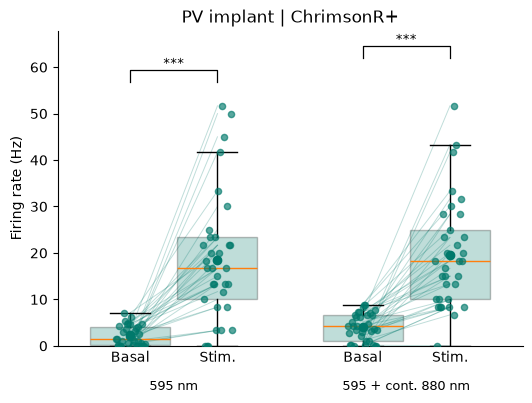

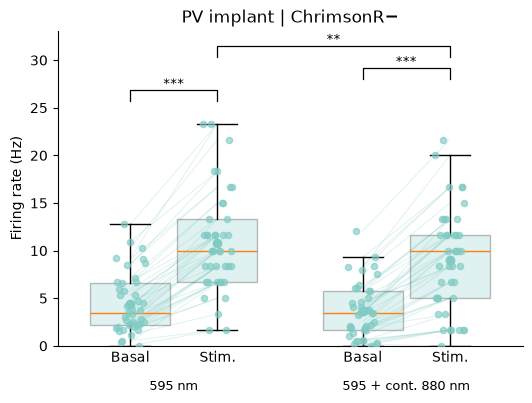

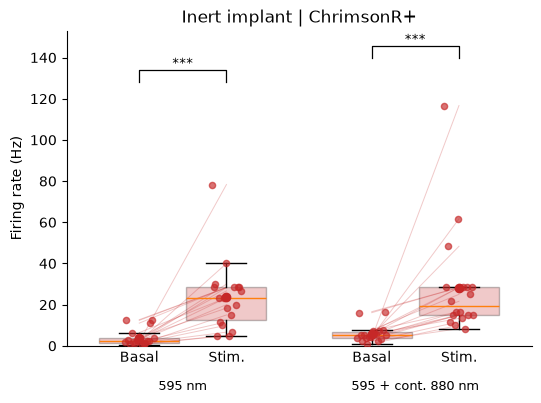

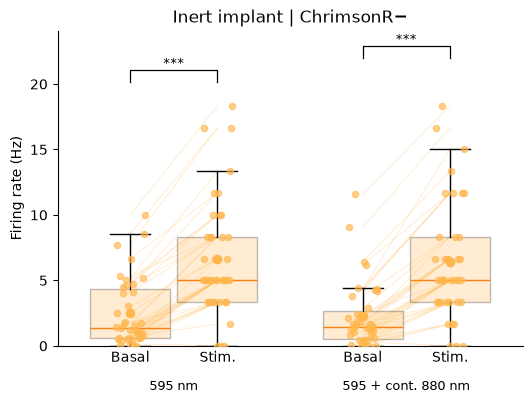

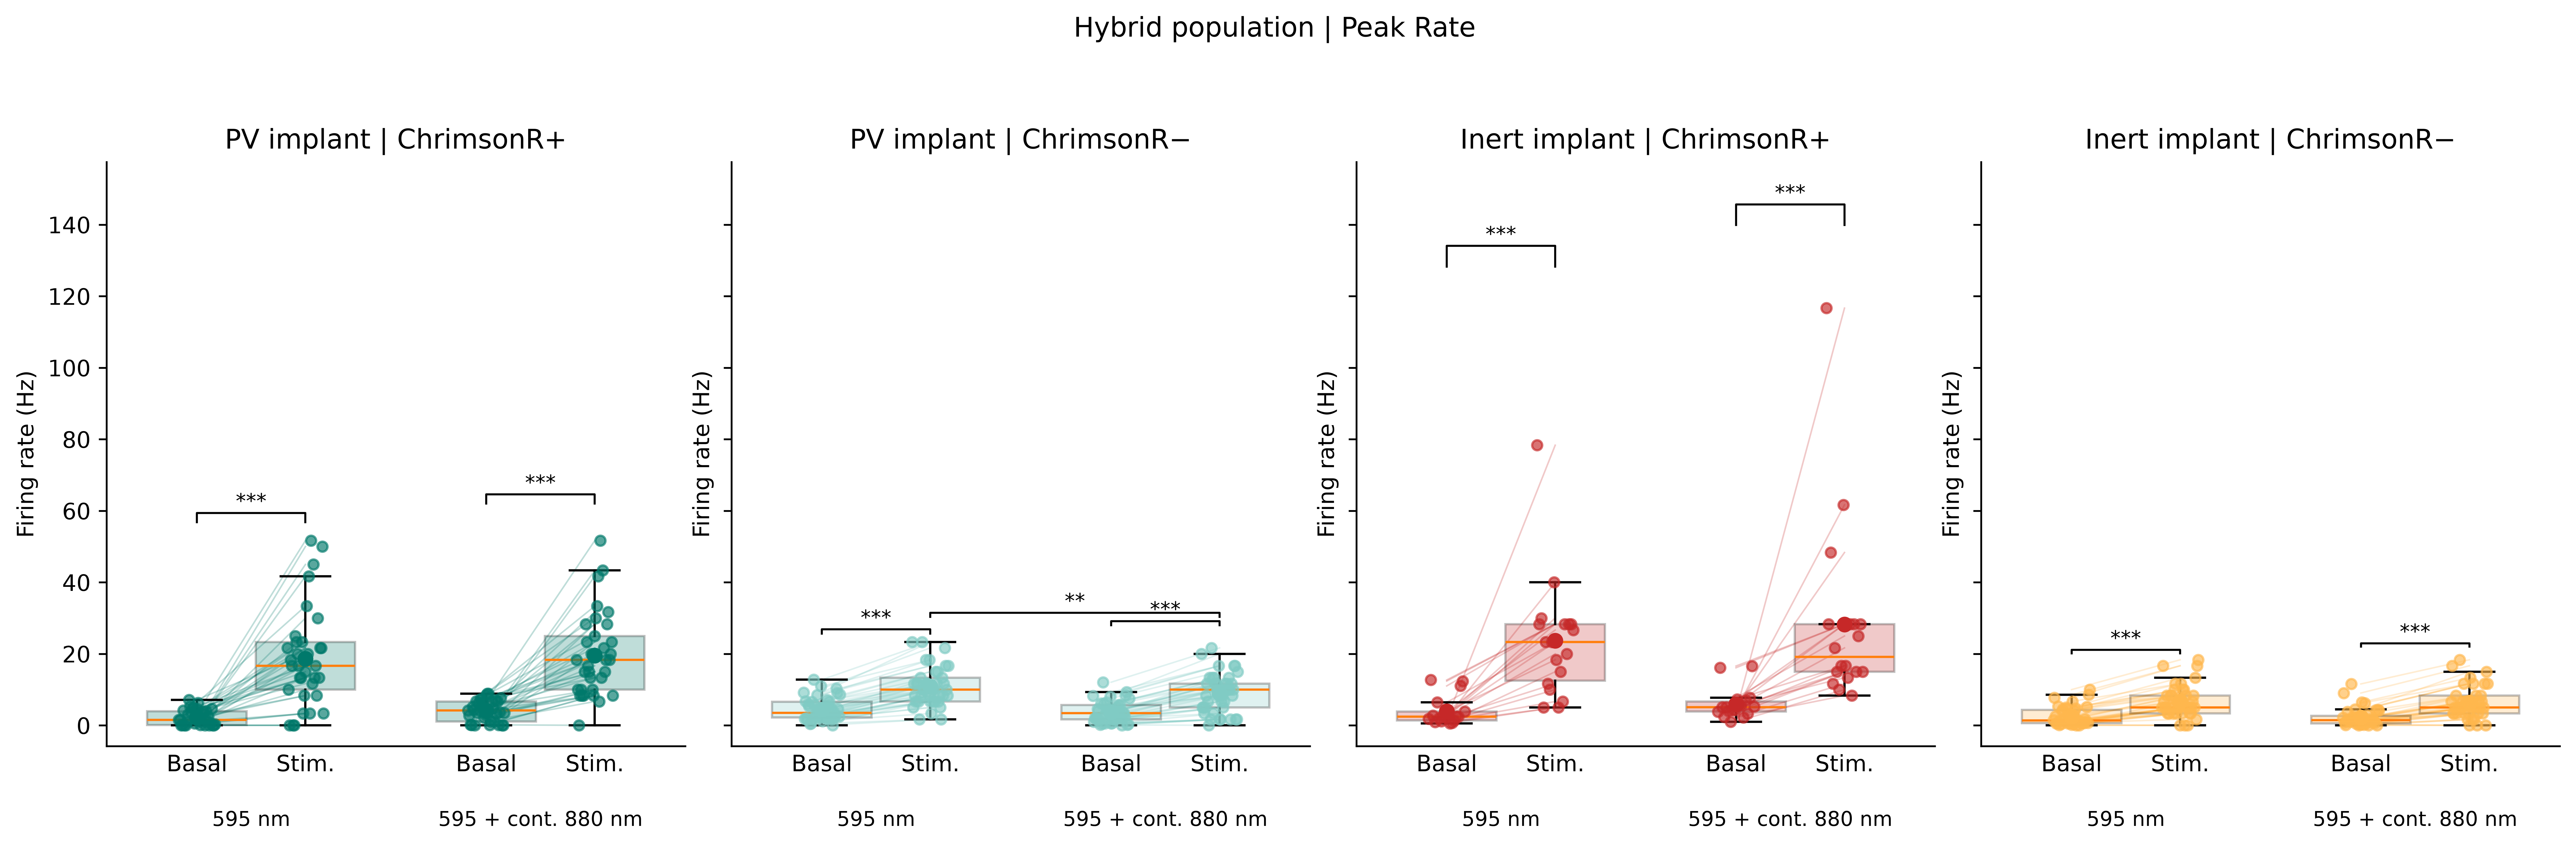


HYBRID STATISTICAL RESULTS

Comparison : PV implant | ChrimsonR+
Stimulus   : 50 ms
Groups     : Baseline vs 595 nm
Test       : Wilcoxon signed-rank test
n          : 33
p-value    : 1.7344e-06

Comparison : PV implant | ChrimsonR+
Stimulus   : 50 ms
Groups     : Baseline vs 595 + cont. 880 nm
Test       : Wilcoxon signed-rank test
n          : 33
p-value    : 5.9093e-07

Comparison : PV implant | ChrimsonR+
Stimulus   : 50 ms
Groups     : 595 nm vs 595 + cont. 880 nm
Test       : Wilcoxon signed-rank test
n          : 33
p-value    : 0.366829

Comparison : PV implant | ChrimsonR−
Stimulus   : 50 ms
Groups     : Baseline vs 595 nm
Test       : Wilcoxon signed-rank test
n          : 41
p-value    : 9.09495e-13

Comparison : PV implant | ChrimsonR−
Stimulus   : 50 ms
Groups     : Baseline vs 595 + cont. 880 nm
Test       : Wilcoxon signed-rank test
n          : 41
p-value    : 2.61054e-08

Comparison : PV implant | ChrimsonR−
Stimulus   : 50 ms
Groups     : 595 nm vs 595 + cont. 880 nm

In [256]:
# ==========================================
# #60 — Plot hybrid response statistic
# ==========================================

"""
Generate hybrid population response plots.

Individual figures
------------------
Generate one figure for each selected comparison
and stimulus value.

Combined figure
---------------
Optionally generate one multi-panel figure
containing all selected comparisons with a
shared y-axis.

All analysis selections are controlled by #55.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================================
# Collect statistical results
# ==========================================

all_hybrid_statistical_results = []


# ==========================================
# Stimulus label helper
# ==========================================

def format_hybrid_stimulus_label(

    stimulus,

    recording_filters,

    include_unit=True,

):

    protocols = (

        recording_filters.loc[

            recording_filters[
                "group_value"
            ]
            == stimulus,

            "protocol"

        ]

        .dropna()

        .astype(str)

        .str.lower()

        .drop_duplicates()

        .tolist()

    )


    if not isinstance(

        stimulus,

        (
            int,
            float,
            np.number,
        ),

    ):

        return str(
            stimulus
        )


    # --------------------------------------
    # Power protocol
    # --------------------------------------

    if "pow" in protocols:

        return f"{stimulus:g}"


    # --------------------------------------
    # Duration protocol
    # --------------------------------------

    if include_unit:

        return f"{stimulus:g} ms"


    return f"{stimulus:g}"


# ==========================================
# Validate summary
# ==========================================

if hybrid_statistics_summary.empty:

    raise ValueError(

        "hybrid_statistics_summary is empty. "
        "Check #55-#58."

    )


# ==========================================
# Determine conditions
# ==========================================

plot_conditions = (

    hybrid_recording_filters[
        "hybrid_condition"
    ]

    .drop_duplicates()

    .tolist()

)


# ==========================================
# Determine comparison order
# ==========================================

preferred_comparison_order = [

    "PV implant | ChrimsonR+",

    "PV implant | ChrimsonR−",

    "Inert implant | ChrimsonR+",

    "Inert implant | ChrimsonR−",

]


available_comparisons = (

    hybrid_statistics_summary[
        "comparison_label"
    ]

    .dropna()

    .unique()

    .tolist()

)


plot_comparisons_ordered = [

    comparison

    for comparison
    in preferred_comparison_order

    if comparison
    in available_comparisons

]


# ------------------------------------------
# Catch unexpected comparison labels
# ------------------------------------------

unexpected_comparisons = [

    comparison

    for comparison
    in available_comparisons

    if comparison
    not in preferred_comparison_order

]


if unexpected_comparisons:

    print()

    print(
        "Warning: comparison(s) not included "
        "in the preferred plotting order:"
    )

    for comparison in unexpected_comparisons:

        print(
            f"    {comparison}"
        )


available_comparisons = (
    plot_comparisons_ordered
)


# ==========================================
# Individual-figure comparison selection
# ==========================================

if hybrid_plot_comparison is None:

    plot_comparisons = (
        available_comparisons
    )

else:

    if (
        hybrid_plot_comparison
        not in available_comparisons
    ):

        raise ValueError(

            "Requested plot comparison is "
            "not available:\n\n"

            f"    {hybrid_plot_comparison}\n\n"

            "Available comparisons:\n\n"

            + "\n".join(

                f"    {comparison}"

                for comparison
                in available_comparisons

            )

        )

    plot_comparisons = [

        hybrid_plot_comparison

    ]


# ==========================================
# Determine selected stimulus values
# ==========================================

if hybrid_selected_group_values is None:

    plot_stimuli = (

        hybrid_statistics_summary[
            "group_value"
        ]

        .dropna()

        .drop_duplicates()

        .tolist()

    )

else:

    plot_stimuli = (

        hybrid_selected_group_values

    )


# ==========================================
# Individual figures
# ==========================================

for comparison in plot_comparisons:

    for stimulus in plot_stimuli:

        comparison_data = (

            hybrid_statistics_summary.loc[

                (

                    hybrid_statistics_summary[
                        "comparison_label"
                    ]

                    == comparison

                )

                &

                (

                    hybrid_statistics_summary[
                        "group_value"
                    ]

                    == stimulus

                )

            ]

        )


        if comparison_data.empty:

            print()

            print(

                f"Skipping individual plot: "
                f"{comparison} | {stimulus}. "
                f"No data."

            )

            continue


        fig, ax = plot_hybrid_statistic(

            hybrid_paired_statistics,

            statistic=hybrid_statistic,

            conditions=plot_conditions,

            comparison=comparison,

            stimulus=stimulus,

            show_points=hybrid_show_points,

            show_mean=hybrid_show_mean,

            show_statistics=
                hybrid_show_statistics,

            show_pairwise_statistics=
                hybrid_show_pairwise_statistics,

            paired=True,

            figsize=hybrid_plot_size,

        )


        all_hybrid_statistical_results.extend(

            getattr(

                ax,

                "hybrid_statistical_results",

                [],

            )

        )


        plt.show()


# ==========================================
# Combined figure
# ==========================================

if hybrid_plot_combined:

    for stimulus in plot_stimuli:

        combined_data = (

            hybrid_paired_statistics.loc[

                (

                    hybrid_paired_statistics[
                        "group_value"
                    ]
                    == stimulus

                )

                &

                hybrid_paired_statistics[
                    "comparison_label"
                ].isin(
                    available_comparisons
                )

            ]

        )


        if combined_data.empty:

            print()

            print(

                f"Skipping combined plot for "
                f"{stimulus}: no data."

            )

            continue


        # ----------------------------------
        # Determine common y-axis range
        # ----------------------------------

        finite_values = (

            combined_data[
                "statistic_value"
            ]

            .replace(
                [np.inf, -np.inf],
                np.nan,
            )

            .dropna()

        )


        if finite_values.empty:

            print()

            print(

                f"Skipping combined plot for "
                f"{stimulus}: no finite values."

            )

            continue


        data_min = (
            finite_values.min()
        )

        data_max = (
            finite_values.max()
        )


        # ----------------------------------
        # Add headroom for annotations
        # ----------------------------------

        data_range = (
            data_max - data_min
        )


        if data_range == 0:

            data_range = max(
                abs(data_max),
                1,
            )


        common_ymin = (

            data_min
            - 0.05 * data_range

        )


        common_ymax = (

            data_max
            + 0.35 * data_range

        )


        common_ylim = (

            common_ymin,
            common_ymax,

        )


        # ----------------------------------
        # Figure dimensions
        # ----------------------------------

        n_comparisons = (
            len(available_comparisons)
        )

        n_columns = n_comparisons

        n_rows = 1


        fig, axes = plt.subplots(

            n_rows,

            n_columns,

            figsize=(

                4.0 * n_comparisons,

                hybrid_plot_size[1],

            ),

            dpi=600,

            sharey=True,

            squeeze=False,

        )


        axes = axes.flatten()


        plotted_axes = []


        # ----------------------------------
        # Plot each comparison
        # ----------------------------------

        for index, comparison in enumerate(

            available_comparisons

        ):

            ax = axes[index]


            comparison_data = (

                combined_data.loc[

                    combined_data[
                        "comparison_label"
                    ]

                    == comparison

                ]

            )


            if comparison_data.empty:

                ax.set_visible(False)

                continue


            plot_hybrid_statistic(

                comparison_data,

                statistic=hybrid_statistic,

                conditions=plot_conditions,

                comparison=comparison,

                stimulus=stimulus,

                show_points=hybrid_show_points,

                show_mean=hybrid_show_mean,

                show_statistics=
                    hybrid_show_statistics,

                show_pairwise_statistics=
                    hybrid_show_pairwise_statistics,

                paired=True,

                ax=ax,

                ylim=common_ylim,

            )


            plotted_axes.append(ax)


        # ----------------------------------
        # Combined title
        # ----------------------------------

        if hybrid_plot_show_stimulus:

            stimulus_label = (
                format_hybrid_stimulus_label(

                    stimulus,

                    hybrid_recording_filters,

                )
            )

        else:

            stimulus_label = None


        combined_title = (

            f"Hybrid population | "
            f"{hybrid_statistic.replace('_', ' ').title()}"

        )


        if stimulus_label is not None:

            combined_title += (
                f" | {stimulus_label}"
            )


        fig.suptitle(

            combined_title,

            y=1.04,

        )


        fig.subplots_adjust(

            left=0.05,

            right=0.995,

            bottom=0.14,

            top=0.86,

            wspace=0.08,

        )


        plt.show()


# ==========================================
# Statistical results
# ==========================================

print()

print("=" * 70)

print(
    "HYBRID STATISTICAL RESULTS"
)

print("=" * 70)

print()


if not all_hybrid_statistical_results:

    print(
        "No statistical tests were performed."
    )

else:

    # --------------------------------------
    # Convert to DataFrame
    # --------------------------------------

    hybrid_results_df = pd.DataFrame(

        all_hybrid_statistical_results

    )


    # --------------------------------------
    # Remove duplicate results
    # --------------------------------------

    hybrid_results_df = (

        hybrid_results_df

        .drop_duplicates(

            subset=[

                "comparison",
                "stimulus",
                "comparison_type",
                "group_1",
                "group_2",

            ]

        )

    )


    # --------------------------------------
    # Sort by plotting order
    # --------------------------------------

    comparison_order = {

        comparison: index

        for index, comparison
        in enumerate(
            available_comparisons
        )

    }


    hybrid_results_df[
        "_comparison_order"
    ] = (

        hybrid_results_df[
            "comparison"
        ]

        .map(comparison_order)

    )


    hybrid_results_df = (

        hybrid_results_df

        .sort_values(

            [

                "_comparison_order",
                "stimulus",
                "comparison_type",

            ]

        )

    )


    # --------------------------------------
    # Print results
    # --------------------------------------

    for _, row in (
        hybrid_results_df.iterrows()
    ):

        print(

            f"Comparison : "
            f"{row['comparison']}"

        )


        # ----------------------------------
        # Stimulus label
        # ----------------------------------

        row_stimulus_label = (

            format_hybrid_stimulus_label(

                row["stimulus"],

                hybrid_recording_filters,

            )

        )


        print(

            f"Stimulus   : "
            f"{row_stimulus_label}"

        )


        print(

            f"Groups     : "
            f"{row['group_1']} vs "
            f"{row['group_2']}"

        )


        print(

            f"Test       : "
            f"{row['test']}"

        )


        print(

            f"n          : "
            f"{int(row['n'])}"

        )


        if pd.isna(
            row["p_value"]
        ):

            print(
                "p-value    : NaN"
            )

        else:

            print(

                f"p-value    : "
                f"{row['p_value']:.6g}"

            )


        print()

#### 61A Fix later

In [257]:
# #61A
# # ==========================================
# # Diagnostic: paired stimulation comparison
# # ==========================================

# comparison_to_test = "PV implant | ChrimsonR−"

# condition_1 = "P"
# condition_2 = "P + continuous laser"


# # ==========================================
# # Select requested comparison and conditions
# # ==========================================

# diagnostic_data = (

#     hybrid_statistics_summary.loc[

#         hybrid_statistics_summary[
#             "comparison_label"
#         ] == comparison_to_test

#     ]

#     .loc[

#         hybrid_statistics_summary[
#             "hybrid_condition"
#         ].isin(
#             [
#                 condition_1,
#                 condition_2,
#             ]
#         )

#     ]

#     .copy()

# )


# # ==========================================
# # Validate available conditions
# # ==========================================

# available_conditions = sorted(

#     diagnostic_data[
#         "hybrid_condition"
#     ]

#     .dropna()
#     .unique()
#     .tolist()

# )

# print()
# print("=" * 70)
# print("PAIRED STIMULATION DIAGNOSTIC")
# print("=" * 70)
# print()

# print(
#     f"Comparison : {comparison_to_test}"
# )

# print(
#     f"Condition 1: {condition_1}"
# )

# print(
#     f"Condition 2: {condition_2}"
# )

# print()

# print(
#     "Available conditions:"
# )

# for condition in available_conditions:

#     print(
#         f"    {condition}"
#     )


# # ==========================================
# # Check both conditions exist
# # ==========================================

# missing_conditions = [

#     condition

#     for condition in [
#         condition_1,
#         condition_2,
#     ]

#     if condition not in available_conditions

# ]

# if missing_conditions:

#     raise ValueError(

#         "Cannot perform paired comparison.\n\n"

#         f"Missing condition(s):\n"

#         + "\n".join(
#             f"    {condition}"
#             for condition in missing_conditions
#         )

#         + "\n\n"

#         "Check hybrid_recording_filters in #55 "
#         "and the resulting hybrid_statistics_summary."

#     )


# # ==========================================
# # Create one row per biological unit
# # ==========================================

# diagnostic_unit_data = (

#     diagnostic_data

#     .groupby(

#         [
#             "hybrid_unit_key",
#             "hybrid_condition",
#         ],

#         as_index=False,

#     )

#     .agg(

#         statistic_value=(
#             "statistic_value",
#             "mean",
#         ),

#     )

# )


# # ==========================================
# # Convert conditions into paired columns
# # ==========================================

# diagnostic_pairs = (

#     diagnostic_unit_data

#     .pivot(

#         index="hybrid_unit_key",

#         columns="hybrid_condition",

#         values="statistic_value",

#     )

#     .copy()

# )


# # ==========================================
# # Verify pivoted columns
# # ==========================================

# missing_pivot_columns = [

#     condition

#     for condition in [
#         condition_1,
#         condition_2,
#     ]

#     if condition not in diagnostic_pairs.columns

# ]

# if missing_pivot_columns:

#     raise ValueError(

#         "The requested conditions were not "
#         "available after pivoting.\n\n"

#         f"Missing:\n"

#         + "\n".join(
#             f"    {condition}"
#             for condition in missing_pivot_columns
#         )

#         + "\n\n"

#         f"Pivot columns:\n"
#         f"{diagnostic_pairs.columns.tolist()}"

#     )


# # ==========================================
# # Keep complete biological pairs
# # ==========================================

# diagnostic_pairs = (

#     diagnostic_pairs

#     .dropna(

#         subset=[
#             condition_1,
#             condition_2,
#         ]

#     )

#     .copy()

# )


# # ==========================================
# # Check paired sample size
# # ==========================================

# if diagnostic_pairs.empty:

#     raise ValueError(

#         "No complete biological pairs remain "
#         "for the requested conditions."

#     )


# # ==========================================
# # Calculate paired differences
# # ==========================================

# diagnostic_pairs["difference"] = (

#     diagnostic_pairs[
#         condition_2
#     ]

#     -

#     diagnostic_pairs[
#         condition_1
#     ]

# )


# # ==========================================
# # Wilcoxon test
# # ==========================================

# from scipy.stats import wilcoxon

# wilcoxon_result = wilcoxon(

#     diagnostic_pairs[
#         condition_1
#     ],

#     diagnostic_pairs[
#         condition_2
#     ],

#     alternative="two-sided",

#     method="auto",

# )


# # ==========================================
# # Summary
# # ==========================================

# print()

# print(
#     f"Paired units : "
#     f"{len(diagnostic_pairs)}"
# )

# print(
#     f"Mean {condition_1} : "
#     f"{diagnostic_pairs[condition_1].mean():.3f} Hz"
# )

# print(
#     f"Mean {condition_2} : "
#     f"{diagnostic_pairs[condition_2].mean():.3f} Hz"
# )

# print()

# print(
#     f"Median {condition_1} : "
#     f"{diagnostic_pairs[condition_1].median():.3f} Hz"
# )

# print(
#     f"Median {condition_2} : "
#     f"{diagnostic_pairs[condition_2].median():.3f} Hz"
# )

# print()

# print(
#     f"Mean paired difference "
#     f"({condition_2} − {condition_1}) : "
#     f"{diagnostic_pairs['difference'].mean():.3f} Hz"
# )

# print(
#     f"Median paired difference "
#     f"({condition_2} − {condition_1}) : "
#     f"{diagnostic_pairs['difference'].median():.3f} Hz"
# )

# print()

# print(
#     f"Positive differences : "
#     f"{(diagnostic_pairs['difference'] > 0).sum()}"
# )

# print(
#     f"Negative differences : "
#     f"{(diagnostic_pairs['difference'] < 0).sum()}"
# )

# print(
#     f"Zero differences     : "
#     f"{(diagnostic_pairs['difference'] == 0).sum()}"
# )

# print()

# print(
#     "Wilcoxon signed-rank test"
# )

# print(
#     f"Statistic : "
#     f"{wilcoxon_result.statistic}"
# )

# print(
#     f"p-value   : "
#     f"{wilcoxon_result.pvalue:.6g}"
# )

# print()

# display(

#     diagnostic_pairs

#     .sort_values(
#         "difference"
#     )

# )

#### 62 Hybrid baseline versus peak rate


Hybrid baseline versus peak statistics
--------------------------------------
Rows       : 262
Conditions : 2
Groups     : 4
Units      : 131

Condition order:
    595 nm
    595 + cont. 880 nm

Comparison order:
    1. PV implant | ChrimsonR+
    2. PV implant | ChrimsonR−
    3. Inert implant | ChrimsonR+
    4. Inert implant | ChrimsonR−
595 nm | PV implant | ChrimsonR+ | n = 33
595 nm | PV implant | ChrimsonR+ | n = 33 | p = 1.734e-06
595 nm | PV implant | ChrimsonR− | n = 41
595 nm | PV implant | ChrimsonR− | n = 41 | p = 9.095e-13
595 nm | Inert implant | ChrimsonR+ | n = 18
595 nm | Inert implant | ChrimsonR+ | n = 18 | p = 7.629e-06
595 nm | Inert implant | ChrimsonR− | n = 39
595 nm | Inert implant | ChrimsonR− | n = 39 | p = 1.235e-07
595 + cont. 880 nm | PV implant | ChrimsonR+ | n = 33
595 + cont. 880 nm | PV implant | ChrimsonR+ | n = 33 | p = 5.909e-07
595 + cont. 880 nm | PV implant | ChrimsonR− | n = 41
595 + cont. 880 nm | PV implant | ChrimsonR− | n = 41 | p = 2.611e

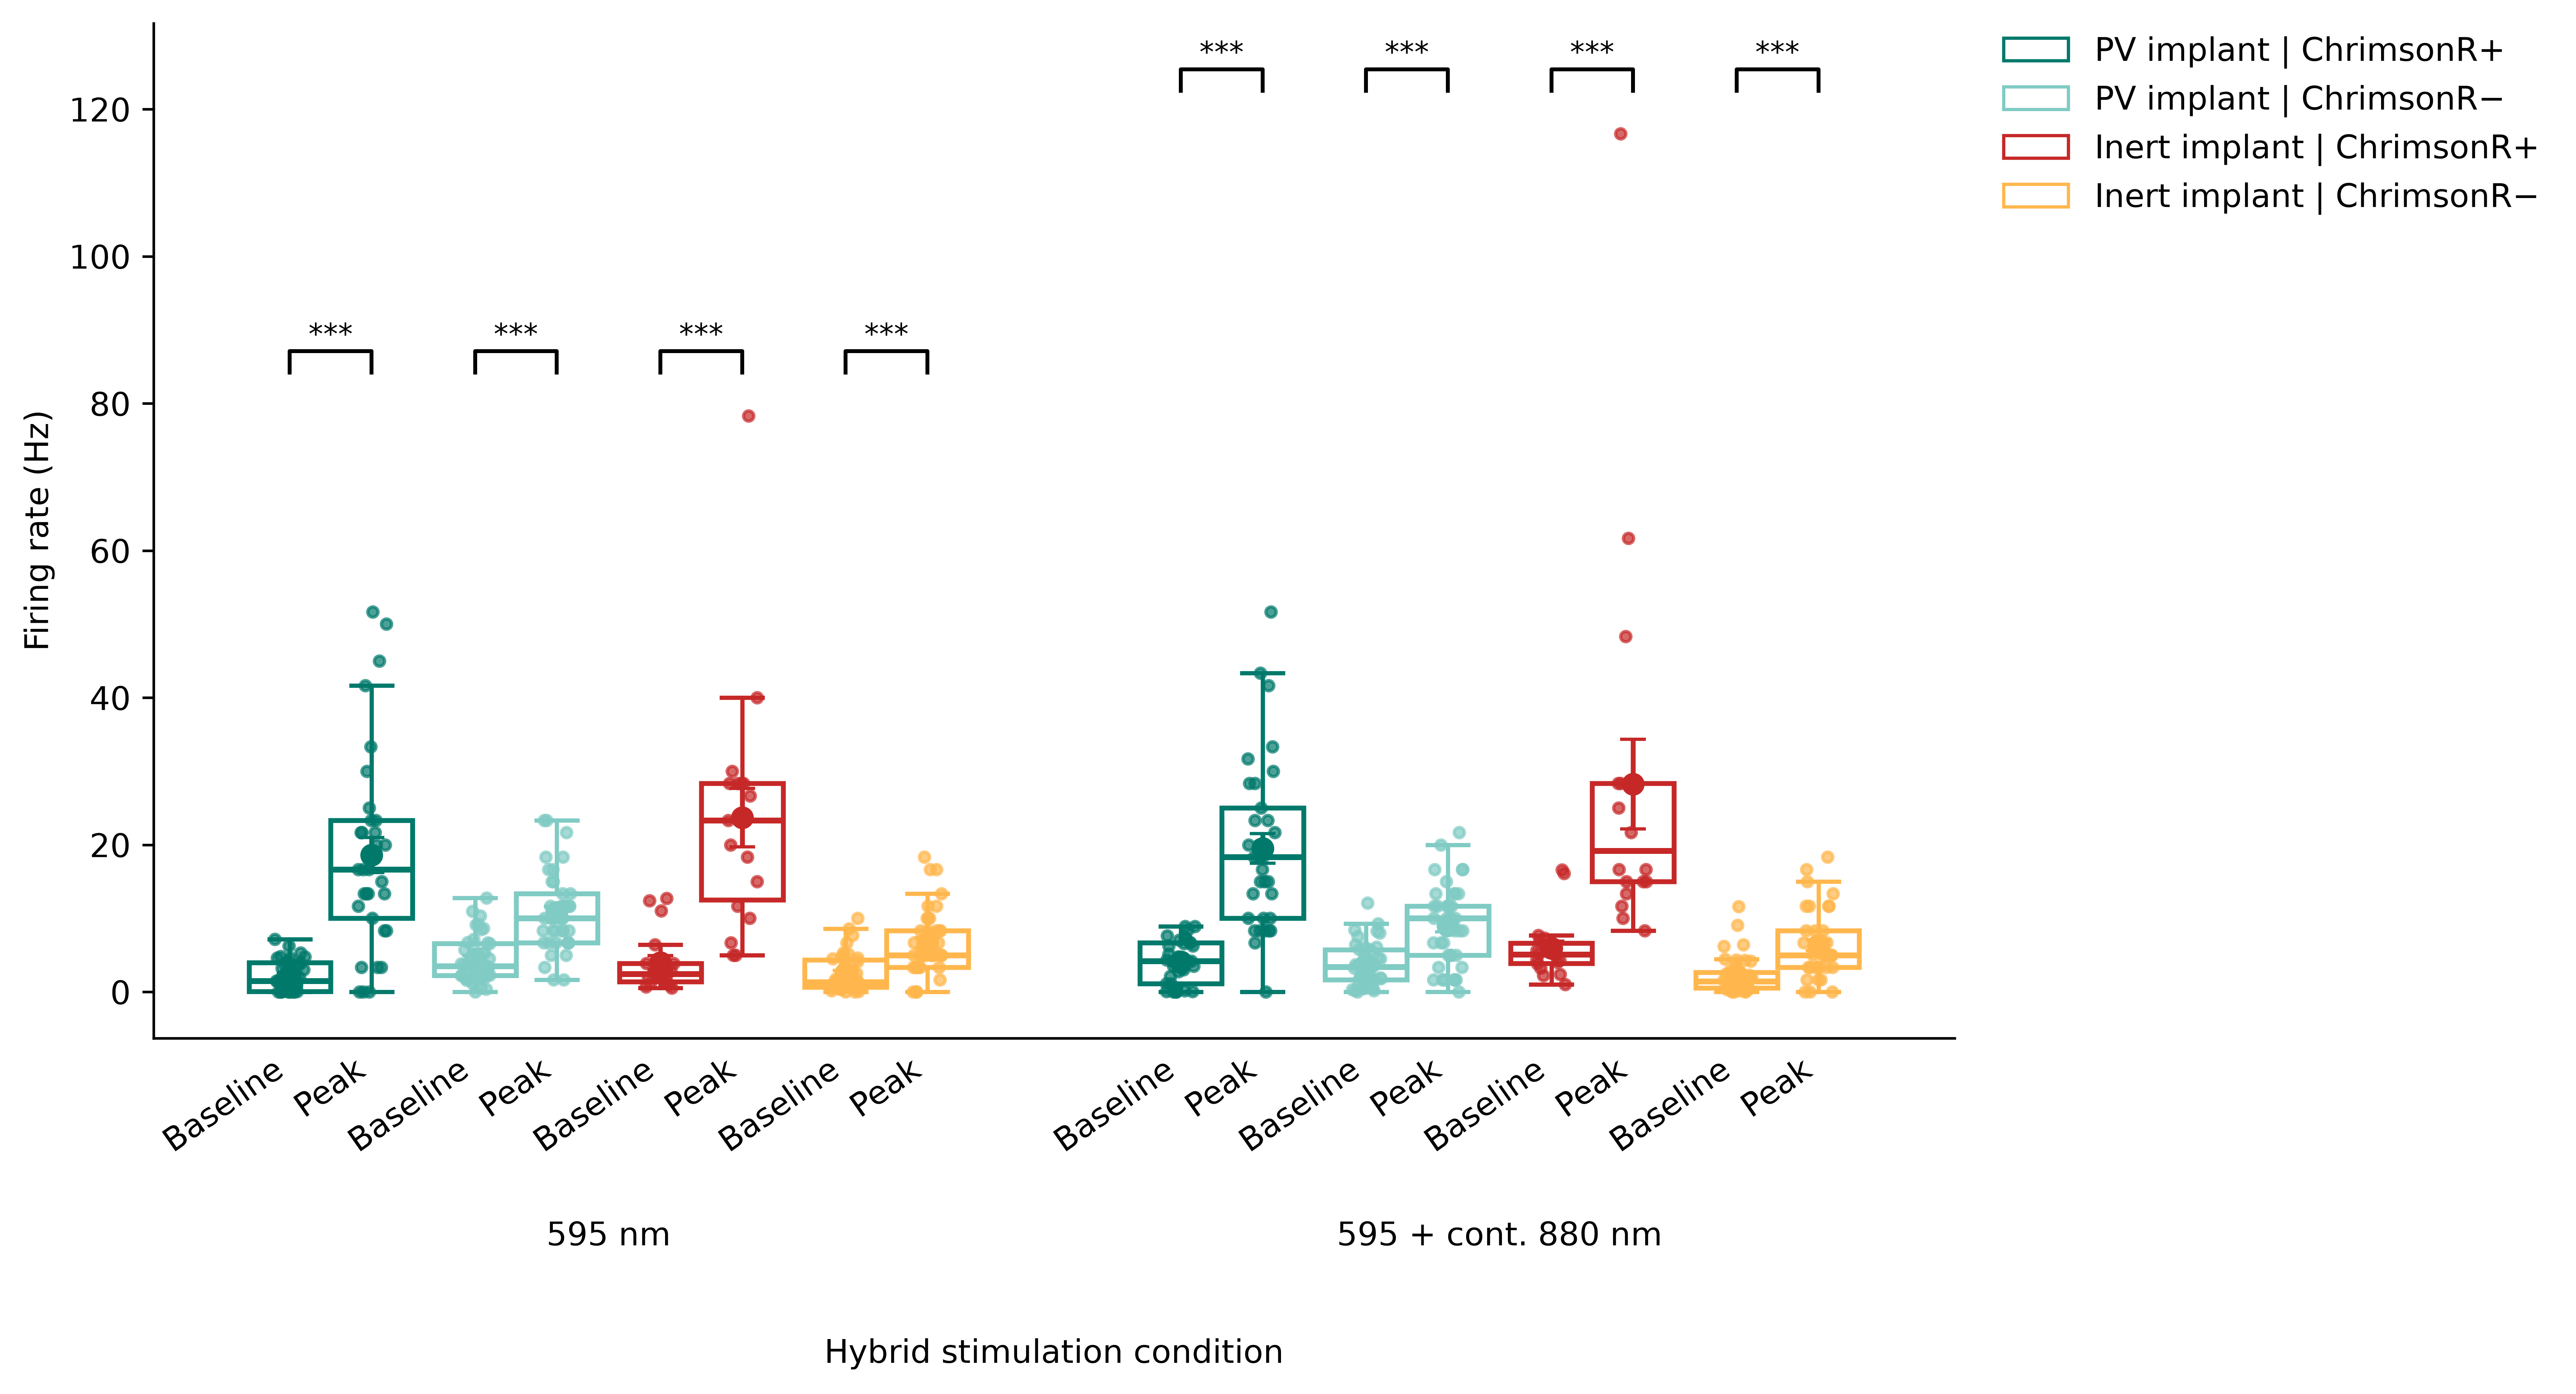


Baseline versus peak Wilcoxon tests
-----------------------------------


,hybrid_condition,comparison_label,n,wilcoxon_statistic,p_value
0,595 + cont. 880 nm,PV implant | ChrimsonR+,33,1.0,5.909304e-07
1,595 + cont. 880 nm,PV implant | ChrimsonR−,41,1.0,2.610543e-08
2,595 + cont. 880 nm,Inert implant | ChrimsonR+,18,0.0,7.629395e-06
3,595 + cont. 880 nm,Inert implant | ChrimsonR−,39,1.0,1.236312e-07
4,595 nm,PV implant | ChrimsonR+,33,0.0,1.734398e-06
5,595 nm,PV implant | ChrimsonR−,41,0.0,9.094947e-13
6,595 nm,Inert implant | ChrimsonR+,18,0.0,7.629395e-06
7,595 nm,Inert implant | ChrimsonR−,39,1.0,1.235296e-07


In [258]:
# ==========================================
# #62 — Hybrid baseline versus peak rate
# ==========================================

"""
Plot baseline and peak firing rates for the
hybrid population.

For each hybrid stimulation condition:

    Baseline | Peak

are shown side-by-side for each experimental
comparison group.

The four comparison groups are ordered as:

    1. PV implant | ChrimsonR+
    2. PV implant | ChrimsonR−
    3. Inert implant | ChrimsonR+
    4. Inert implant | ChrimsonR−

Missing groups are omitted without changing
the ordering of the remaining groups.

Baseline and peak rates are paired within
biological unit:

    session_id + unit_id

Statistical comparison:

    paired Wilcoxon signed-rank test

The analysis uses hybrid_statistics_summary
and does not recompute PSTHs or bootstrap
statistics.
"""

from scipy.stats import wilcoxon

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import numpy as np
import pandas as pd


# ==========================================
# Validate input
# ==========================================

if hybrid_statistics_summary.empty:

    raise RuntimeError(
        "No hybrid statistics are available "
        "for the baseline-versus-peak plot."
    )


required_columns = [

    "hybrid_condition",
    "comparison_key",
    "comparison_label",
    "session_id",
    "unit_id",
    "baseline_rate",
    "statistic_value",

]


missing_columns = [

    column

    for column in required_columns

    if column not in hybrid_statistics_summary.columns

]


if missing_columns:

    raise KeyError(

        "hybrid_statistics_summary is missing "
        "the following required columns:\n\n"

        + "\n".join(
            f"    {column}"
            for column in missing_columns
        )

    )


# ==========================================
# Select plotting data
# ==========================================

hybrid_plot_df = (

    hybrid_statistics_summary

    .copy()

)


# ------------------------------------------
# Apply comparison selection from #55
# ------------------------------------------

if hybrid_selected_comparison_keys is not None:

    selected_keys = {

        tuple(key)

        for key
        in hybrid_selected_comparison_keys

    }

    hybrid_plot_df = (

        hybrid_plot_df

        .loc[

            hybrid_plot_df[
                "comparison_key"
            ]

            .map(

                lambda key:
                tuple(key) in selected_keys

            )

        ]

        .copy()

    )


# ------------------------------------------
# Apply stimulus selection from #55
# ------------------------------------------

if hybrid_selected_group_values is not None:

    hybrid_plot_df = (

        hybrid_plot_df

        .loc[

            hybrid_plot_df[
                hybrid_stimulus_group
            ]

            .isin(
                hybrid_selected_group_values
            )

        ]

        .copy()

    )


if hybrid_plot_df.empty:

    raise RuntimeError(

        "No hybrid statistics remain after "
        "applying the #55 configuration."

    )


# ==========================================
# Biological-unit identifier
# ==========================================

hybrid_plot_df[
    "hybrid_unit_key"
] = (

    hybrid_plot_df[
        "session_id"
    ]

    .astype(str)

    + "|"

    + hybrid_plot_df[
        "unit_id"
    ]

    .astype(str)

)


# ==========================================
# Comparison-group ordering
# ==========================================

preferred_group_order = [

    "PV implant | ChrimsonR+",

    "PV implant | ChrimsonR−",

    "Inert implant | ChrimsonR+",

    "Inert implant | ChrimsonR−",

]


available_groups = (

    hybrid_plot_df[
        "comparison_label"
    ]

    .dropna()

    .unique()

    .tolist()

)


comparison_values = [

    group

    for group
    in preferred_group_order

    if group in available_groups

]


# ------------------------------------------
# Include unexpected groups afterwards
# ------------------------------------------

comparison_values += [

    group

    for group
    in available_groups

    if group not in comparison_values

]


# ==========================================
# Hybrid-condition ordering
# ==========================================

condition_values = (

    hybrid_plot_df[
        "hybrid_condition"
    ]

    .dropna()

    .drop_duplicates()

    .tolist()

)


# ==========================================
# Summary
# ==========================================

print()

print(
    "Hybrid baseline versus peak statistics"
)

print(
    "--------------------------------------"
)

print(
    f"Rows       : {len(hybrid_plot_df)}"
)

print(
    f"Conditions : {len(condition_values)}"
)

print(
    f"Groups     : {len(comparison_values)}"
)

print(
    f"Units      : "
    f"{hybrid_plot_df['hybrid_unit_key'].nunique()}"
)

print()

print(
    "Condition order:"
)

for condition in condition_values:

    print(
        f"    {condition}"
    )

print()

print(
    "Comparison order:"
)

for index, group in enumerate(
    comparison_values,
    start=1,
):

    print(
        f"    {index}. {group}"
    )


# ==========================================
# Plot parameters
# ==========================================

hybrid_box_width = 0.30

hybrid_group_spacing = 0.68

hybrid_condition_gap = 0.55

hybrid_condition_spacing = (

    len(comparison_values)
    * hybrid_group_spacing

    + hybrid_condition_gap

)

hybrid_jitter_width = 0.055

hybrid_point_size = 10

hybrid_point_alpha = 0.70


# ==========================================
# X positions
# ==========================================

condition_centres = [

    index
    * hybrid_condition_spacing

    for index
    in range(
        len(condition_values)
    )

]


n_groups = len(
    comparison_values
)


group_offsets = (

    np.arange(
        n_groups
    )

    - (
        n_groups - 1
    ) / 2

) * hybrid_group_spacing


# ==========================================
# Figure
# ==========================================

fig, ax = plt.subplots(

    figsize=(

        max(
            11,
            len(condition_values)
            * 3.0,
        ),

        7,

    ),

    dpi=600,

)


# ==========================================
# Statistical results
# ==========================================

significance_results = []


# ==========================================
# Plot conditions
# ==========================================

for condition_index, condition in enumerate(
    condition_values
):

    condition_centre = (

        condition_centres[
            condition_index
        ]

    )

    for group_index, group in enumerate(
        comparison_values
    ):

        subset = hybrid_plot_df.loc[

            (

                hybrid_plot_df[
                    "hybrid_condition"
                ]

                == condition

            )

            &

            (

                hybrid_plot_df[
                    "comparison_label"
                ]

                == group

            )

        ].copy()


        if subset.empty:

            continue


        # ----------------------------------
        # Group centre
        # ----------------------------------

        x_centre = (

            condition_centre

            + group_offsets[
                group_index
            ]

        )


        baseline_x = (

            x_centre
            - hybrid_box_width / 2

        )

        peak_x = (

            x_centre
            + hybrid_box_width / 2

        )


        # ----------------------------------
        # Comparison colour
        # ----------------------------------

        comparison_key = (

            subset[
                "comparison_key"
            ]

            .iloc[0]

        )


        colour = get_comparison_colour(

            comparison_key,

            hybrid_comparison_groups,

            hybrid_comparison_styles,

        )


        # ==================================
        # Baseline values
        # ==================================

        baseline_values = (

            subset[
                "baseline_rate"
            ]

            .dropna()

        )


        if not baseline_values.empty:

            ax.boxplot(

                baseline_values,

                positions=[
                    baseline_x
                ],

                widths=(
                    hybrid_box_width
                ),

                patch_artist=True,

                showfliers=False,

                boxprops=dict(

                    facecolor="none",

                    edgecolor=colour,

                    linewidth=1.5,

                ),

                whiskerprops=dict(

                    color=colour,

                    linewidth=1.3,

                ),

                capprops=dict(

                    color=colour,

                    linewidth=1.3,

                ),

                medianprops=dict(

                    color=colour,

                    linewidth=1.8,

                ),

            )


            if hybrid_show_points:

                jitter = np.random.uniform(

                    -hybrid_jitter_width,

                    hybrid_jitter_width,

                    len(
                        baseline_values
                    ),

                )

                ax.scatter(

                    np.full(

                        len(
                            baseline_values
                        ),

                        baseline_x,

                    )

                    + jitter,

                    baseline_values,

                    s=hybrid_point_size,

                    color=colour,

                    alpha=hybrid_point_alpha,

                    zorder=4,

                )


            if hybrid_show_mean:

                baseline_mean = (
                    baseline_values.mean()
                )

                baseline_sem = (
                    baseline_values.sem()
                )

                ax.errorbar(

                    baseline_x,

                    baseline_mean,

                    yerr=baseline_sem,

                    fmt="o",

                    color=colour,

                    markersize=6,

                    linewidth=1.5,

                    capsize=4,

                    zorder=5,

                )


        # ==================================
        # Peak values
        # ==================================

        peak_values = (

            subset[
                "statistic_value"
            ]

            .dropna()

        )


        if not peak_values.empty:

            ax.boxplot(

                peak_values,

                positions=[
                    peak_x
                ],

                widths=(
                    hybrid_box_width
                ),

                patch_artist=True,

                showfliers=False,

                boxprops=dict(

                    facecolor="none",

                    edgecolor=colour,

                    linewidth=1.5,

                ),

                whiskerprops=dict(

                    color=colour,

                    linewidth=1.3,

                ),

                capprops=dict(

                    color=colour,

                    linewidth=1.3,

                ),

                medianprops=dict(

                    color=colour,

                    linewidth=1.8,

                ),

            )


            if hybrid_show_points:

                jitter = np.random.uniform(

                    -hybrid_jitter_width,

                    hybrid_jitter_width,

                    len(
                        peak_values
                    ),

                )

                ax.scatter(

                    np.full(

                        len(
                            peak_values
                        ),

                        peak_x,

                    )

                    + jitter,

                    peak_values,

                    s=hybrid_point_size,

                    color=colour,

                    alpha=hybrid_point_alpha,

                    zorder=4,

                )


            if hybrid_show_mean:

                peak_mean = (
                    peak_values.mean()
                )

                peak_sem = (
                    peak_values.sem()
                )

                ax.errorbar(

                    peak_x,

                    peak_mean,

                    yerr=peak_sem,

                    fmt="o",

                    color=colour,

                    markersize=6,

                    linewidth=1.5,

                    capsize=4,

                    zorder=5,

                )


        # ==================================
        # Paired Wilcoxon test
        # ==================================

        paired = (

            subset[

                [

                    "hybrid_unit_key",
                    "baseline_rate",
                    "statistic_value",

                ]

            ]

            .dropna()

            .drop_duplicates(

                subset=[
                    "hybrid_unit_key"
                ]

            )

        )


        if len(paired) >= 2:

            baseline_array = (

                paired[
                    "baseline_rate"
                ]

                .to_numpy()

            )

            peak_array = (

                paired[
                    "statistic_value"
                ]

                .to_numpy()

            )

            print(

                f"{condition} | "

                f"{group} | "

                f"n = {len(paired)}"

            )

            if np.allclose(

                baseline_array,
                peak_array,

            ):

                test_statistic = 0.0

                p_value = 1.0

            else:

                result = wilcoxon(

                    baseline_array,

                    peak_array,

                    alternative="two-sided",

                    method="auto",

                )

                test_statistic = (
                    result.statistic
                )

                p_value = result.pvalue


            max_value = max(

                baseline_array.max(),

                peak_array.max(),

            )

            print(
                f"{condition} | "
                f"{group} | "
                f"n = {len(paired)} | "
                f"p = {p_value:.4g}"
            )

            significance_results.append(

                {

                    "hybrid_condition":
                        condition,

                    "comparison_label":
                        group,

                    "group_index":
                        group_index,

                    "n":
                        len(paired),

                    "wilcoxon_statistic":
                        test_statistic,

                    "p_value":
                        p_value,

                    "max_value":
                        max_value,

                    "x_centre":
                        x_centre,

                }

            )


# ==========================================
# X-axis labels
# ==========================================

plot_ticks = []

plot_labels = []


for condition_index, condition in enumerate(
    condition_values
):

    condition_centre = (

        condition_centres[
            condition_index
        ]

    )

    for group_index, group in enumerate(
        comparison_values
    ):

        subset = hybrid_plot_df.loc[

            (

                hybrid_plot_df[
                    "hybrid_condition"
                ]

                == condition

            )

            &

            (

                hybrid_plot_df[
                    "comparison_label"
                ]

                == group

            )

        ]


        if subset.empty:

            continue


        x_centre = (

            condition_centre

            + group_offsets[
                group_index
            ]

        )


        plot_ticks.extend(

            [

                x_centre
                - hybrid_box_width / 2,

                x_centre
                + hybrid_box_width / 2,

            ]

        )


        plot_labels.extend(

            [

                "Baseline",

                "Peak",

            ]

        )


ax.set_xticks(
    plot_ticks
)

ax.set_xticklabels(

    plot_labels,

    rotation=35,

    ha="right",

)

ax.tick_params(
    axis="x",
    length=0,
    pad=5,
)


# ==========================================
# Hybrid-condition labels
# ==========================================

condition_label_y = -0.18


for condition_index, condition in enumerate(
    condition_values
):

    ax.text(

        condition_centres[
            condition_index
        ],

        condition_label_y,

        condition,

        transform=ax.get_xaxis_transform(),

        ha="center",

        va="top",

        fontsize=10,

    )


ax.set_xlabel(
    "Hybrid stimulation condition",
    labelpad=55,
)

ax.set_ylabel(
    "Firing rate (Hz)"
)


# ==========================================
# Significance labels
# ==========================================

def significance_label(p_value):

    if p_value < 0.001:

        return "***"

    elif p_value < 0.01:

        return "**"

    elif p_value < 0.05:

        return "*"

    else:

        return "ns"


# ==========================================
# Significance annotations
# ==========================================

if hybrid_show_statistics:

    all_values = (

        hybrid_plot_df[
            [
                "baseline_rate",
                "statistic_value",
            ]
        ]

        .to_numpy()

    )


    finite_values = (

        all_values[
            np.isfinite(
                all_values
            )
        ]

    )


    if len(finite_values) > 0:

        data_max = (
            finite_values.max()
        )

    else:

        data_max = 1.0


    # --------------------------------------
    # Calculate annotation spacing
    # --------------------------------------

    annotation_height = (
        0.025 * data_max
    )

    annotation_step = (
        0.075 * data_max
    )

    annotation_gap = (
        0.05 * data_max
    )


    # --------------------------------------
    # One annotation block per condition
    # --------------------------------------

    for condition_index, condition in enumerate(
        condition_values
    ):

        condition_results = [

            result

            for result
            in significance_results

            if result[
                "hybrid_condition"
            ] == condition

        ]


        if not condition_results:

            continue


        condition_max = max(

            result[
                "max_value"
            ]

            for result
            in condition_results

        )


        base_y = (

            condition_max

            + annotation_gap

        )


        # ----------------------------------
        # Fixed vertical lanes
        # ----------------------------------

        for result in condition_results:

            group_index = result[
                "group_index"
            ]

            x_centre = result[
                "x_centre"
            ]

            y = base_y

            x1 = (

                x_centre
                - hybrid_box_width / 2
            )

            x2 = (
                x_centre
                + hybrid_box_width / 2
            )

            ax.plot(
                [
                    x1,
                    x1,
                    x2,
                    x2,
                ],
                
                [

                    y,
                    y + annotation_height,
                    y + annotation_height,
                    y,

                ],

                color="black",

                linewidth=1.2,

                clip_on=False,

            )


            ax.text(

                (x1 + x2) / 2,

                y + annotation_height,

                significance_label(
                    result[
                        "p_value"
                    ]
                ),

                ha="center",

                va="bottom",

                fontsize=9,

                clip_on=False,

            )


# ==========================================
# Comparison-group legend
# ==========================================

legend_handles = []


for group in comparison_values:

    group_rows = hybrid_plot_df.loc[

        hybrid_plot_df[
            "comparison_label"
        ] == group

    ]


    if group_rows.empty:

        continue


    comparison_key = (

        group_rows[
            "comparison_key"
        ]

        .iloc[0]

    )


    colour = get_comparison_colour(

        comparison_key,

        hybrid_comparison_groups,

        hybrid_comparison_styles,

    )


    legend_handles.append(

        mpatches.Patch(

            facecolor="none",

            edgecolor=colour,

            label=group,

        )

    )


if legend_handles:

    ax.legend(

        handles=legend_handles,

        frameon=False,

        loc="upper left",

        bbox_to_anchor=(

            1.02,
            1.0,

        ),

        borderaxespad=0,

    )


# ==========================================
# Appearance
# ==========================================

ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


# ------------------------------------------
# Leave room for rotated labels and legend
# ------------------------------------------

plt.subplots_adjust(

    left=0.08,

    right=0.78,

    bottom=0.30,

    top=0.92,

)


plt.show()


# ==========================================
# Statistical summary
# ==========================================

if significance_results:

    hybrid_baseline_peak_statistics = (

        pd.DataFrame(
            significance_results
        )

    )


    # Sort while group_index is still present.
    hybrid_baseline_peak_statistics = (

        hybrid_baseline_peak_statistics

        .sort_values(

            [

                "hybrid_condition",
                "group_index",

            ]

        )

        .reset_index(
            drop=True
        )

    )


    print()

    print(
        "Baseline versus peak Wilcoxon tests"
    )

    print(
        "-----------------------------------"
    )


    display(

        hybrid_baseline_peak_statistics[

            [

                "hybrid_condition",
                "comparison_label",
                "n",
                "wilcoxon_statistic",
                "p_value",

            ]

        ]

    )

### Appendix: Debugging

In [259]:
from pathlib import Path
from pv_chip_aarhus.preprocessing.params import dataset_dir

sid = "20260601_eye1_1st"

trigger_dir = Path(dataset_dir) / sid / "trigger_files"
stim_dir = Path(dataset_dir) / sid / "stim_files"

print("Trigger files:")
for f in sorted(trigger_dir.glob("*_triggers.pkl")):
    print(f.name)

print("\nStim files:")
for f in sorted(stim_dir.glob("*.dat")):
    print(f.name)

Trigger files:

Stim files:


In [260]:
# from pv_chip_aarhus.preprocessing.lib.filepaths import FilePaths

# sid = "20260601_eye1_1st"

# filepaths = FilePaths(sid)

In [261]:
# display(filepaths.recording_table)

In [262]:
# from pathlib import Path
# from pv_chip_aarhus.preprocessing.params import dataset_dir

# sid = "20260601_eye1_1st"

# trigger_dir = (
#     Path(dataset_dir)
#     / sid
#     / "trigger_files"
# )

# print("Trigger directory:")
# print(trigger_dir)

# for file in trigger_dir.iterdir():
#     if "_triggers.pkl" in file.name:
#         parts = file.name.split("_")

#         print("\nFilename:")
#         print(file.name)

#         print(f"Number of parts: {len(parts)}")

#         for i, part in enumerate(parts):
#             print(i, part)